<a href="https://colab.research.google.com/github/ChaithraKNagaraju/ecg-classification/blob/master/Arrhythmia_Classification_Full_and_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Single-Lead ECG Arrhythmia Classification**


---

By- Md Rabiul Islam



## **a. Summary, At a Glance**


*   **Task:** Arrhythmia Classification, 5 classes
*   **Dataset:** MIT-BIH ECG dataset, Dataset website: [Here](https://physionet.org/content/mitdb/1.0.0/)
*   **Model:** CNN_LSTM with Attention
*   **Made By:** Md Rabiul Islam, PhD Student, Texas A&M University. [Personal Website](https://sites.google.com/view/rabiuleeekuet/home). [Google Scholar](https://scholar.google.com/citations?user=GfveUqIAAAAJ&hl=en). Email: rabiul.kuet.bd@gmail.com.
*   **Supervised By:** Prof. Dr. Erchin Serpedin. (Collaboration: Prof. Dr. Khalid Qaraqe, Assoc. Prof. Dr. Marwa Qaraqe)
*   **Date:** November 2022 - January 2023

## **b. Information about Dataset:**


The dataset can be downloaded from the original [website](https://physionet.org/content/mitdb/1.0.0/) or by clicking the [link](https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip) directly. The overall information about the dataset is given [here](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm).
1. The MIT-BIH dataset contains **48 readings**.
2. Number of **patients = 47** (25 Men, 22 Women). Only 1 patient has 2 readings. Rest 1 readings/patients.
3. Each reading contains a. ECG signals b. Annotations
4. ECG signals length = **30 Minutes** (or slightly over). Sampling Frequency = **360 Hz**.
5. Each reading contains **2 Lead ECG** signals that are Modified Limb Lead II and Modified Lead V1 (Occationally V2, V5, V4 just only once). Simply, Two Leads: **MLII, V1**.
6. Annotation is given for each beat. Although 20 types of beats are annotated in dataset. We consider only **15 types** of beats grouped in **5 classes** followed by the recommendation of **AAMI**.
* N - Normal
* S - Supraventricular premature beat
* V - Premature ventricular contraction
* F - Fusion of ventricular and normal beat
* Q - Unclassifiable / Unknown beat

### **Additional Dataset Information:**
The source of the ECGs included in the MIT-BIH Arrhythmia Database is a set of over **4000 long-term Holter recordings** that were obtained by the **Beth Israel Hospital** Arrhythmia Laboratory between **1975 and 1979**. Approximately **60%** of these recordings were obtained from **inpatients**. The subjects were 25 men aged 32 to 89 years, and 22 women aged 23 to 89 years

# **Main Parts of the Study:**

1.   **Part A: Installing Packages and Basic Visualization of ECG**
2.   **Part B: Denoising, R-Peak Detection, Segmentation**
3.   **Part C: Dataset Loading**
4.   **Part D: Train-Test Splitting and Class Balancing**
5.   **Part E: Model Building and Training**
6.   **Part F: Results**

# **Part A: Installing Packages and Basic Visualization of ECG**

## **A1: Installing Packages**

In [141]:
# wfdb is not normally installed in Colab
!pip install wfdb

In [142]:
# Importing packages
import os
import datetime
import wfdb
import pywt
import seaborn
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from os.path import join as osj
import pandas as pd

## **A2: Basic Visualization of ECG**
Basic code for loading (reading), plotting and playing with ECG signals

### **a. Getting Recordings' IDs**
The ECG recordings are named after Patients' IDs (from 100 to 234), sorted but not consecutive. Total 48 recordings.

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [295]:
!ls "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"

 100.atr     111.xws   123.hea	 212.atr   228.hea
 100.dat     112.atr   123.xws	 212.dat   228.xws
 100.hea     112.dat   124.atr	 212.hea   230.atr
 100.xws     112.hea   124.dat	 212.xws   230.dat
 101.atr     112.xws   124.hea	 213.atr   230.hea
 101.dat     113.atr   124.xws	 213.dat   230.xws
 101.hea     113.dat   200.atr	 213.hea   231.atr
 101.xws     113.hea   200.dat	 213.xws   231.dat
 102-0.atr   113.xws   200.hea	 214.at_   231.hea
 102.atr     114.atr   200.xws	 214.atr   231.xws
 102.dat     114.dat   201.atr	 214.dat   232.atr
 102.hea     114.hea   201.dat	 214.hea   232.dat
 102.xws     114.xws   201.hea	 214.xws   232.hea
 103.atr     115.atr   201.xws	 215.at_   232.xws
 103.dat     115.dat   202.atr	 215.atr   233.atr
 103.hea     115.hea   202.dat	 215.dat   233.dat
 103.xws     115.xws   202.hea	 215.hea   233.hea
 104.atr     116.atr   202.xws	 215.xws   233.xws
 104.dat     116.dat   203.at-	 217.atr   234.atr
 104.hea     116.hea   203.at_	 217.dat   234.dat


In [298]:
!find /content -type f -name "code_17_t5_weights.hdf5"

In [144]:
import pandas as pd
import numpy as np
# Path to dataset folder
DATA_ROOT = "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0"
# Path to RECORDS file
record_file = f"{DATA_ROOT}/RECORDS"
# Load record IDs
patient_ids = pd.read_csv(record_file, header=None)[0].astype(int).to_numpy()
print(patient_ids)

[100 101 102 103 104 105 106 107 108 109 111 112 113 114 115 116 117 118
 119 121 122 123 124 200 201 202 203 205 207 208 209 210 212 213 214 215
 217 219 220 221 222 223 228 230 231 232 233 234]


### **b. 1 Patient ECG loading and plotting**
Extracting 2 leads ECG signals of a patient (for example: 100), and saving in two lists.

In [ ]:
#Extracting just 1 patient ECG signal and info
lead0 = {}  # without this it shows lead0[100] is not defined
lead1 = {}
patient_id = 100
signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(100)))
lead0[100] = signals[:, 0]
lead1[100] = signals[:, 1]

<class 'numpy.ndarray'>
(650000,)
{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


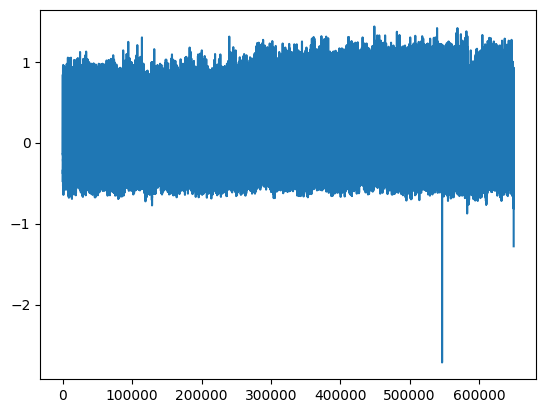

In [ ]:
# Visualization of 1 patients signal and info
print(type(lead0[100]))
print(lead0[100].shape)
plt.plot(lead0[100])
print(info)

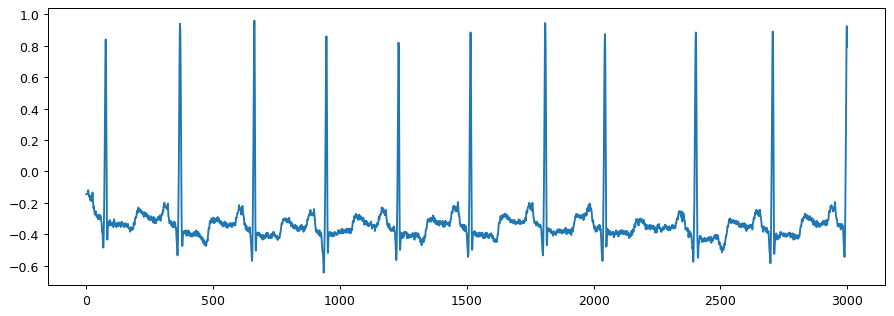

In [ ]:
# ECG signal per second
a = lead0[100][0: 3000]
plt.figure(figsize=(12, 4), dpi=90)
plt.plot(a)

### **c. All patients' ECG loading**

In [ ]:
# Loading all patients ECG SIGNALs using for loop
def get_ecg_signals(patient_ids):
    lead0 = {}
    lead1 = {}
    for id_ in patient_ids:
        signals, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(id_)))
        lead0[id_] = signals[:, 0]
        lead1[id_] = signals[:, 1]
        print(f'Signal of patient {id_} extracted')
    return lead0, lead1

In [ ]:
# Loading all patient ECG INFORMATION
def get_ecg_info(patient_ids):
    _, info = wfdb.io.rdsamp(osj(DATA_ROOT, str(patient_ids)))
    resolution = 2**11  # Number of possible signal values we can have.
    info["resolution"] = 2**11
    return info

In [ ]:
lead0, lead1 = get_ecg_signals(patient_ids)

Signal of patient 100 extracted
Signal of patient 101 extracted
Signal of patient 102 extracted
Signal of patient 103 extracted
Signal of patient 104 extracted
Signal of patient 105 extracted
Signal of patient 106 extracted
Signal of patient 107 extracted
Signal of patient 108 extracted
Signal of patient 109 extracted
Signal of patient 111 extracted
Signal of patient 112 extracted
Signal of patient 113 extracted
Signal of patient 114 extracted
Signal of patient 115 extracted
Signal of patient 116 extracted
Signal of patient 117 extracted
Signal of patient 118 extracted
Signal of patient 119 extracted
Signal of patient 121 extracted
Signal of patient 122 extracted
Signal of patient 123 extracted
Signal of patient 124 extracted
Signal of patient 200 extracted
Signal of patient 201 extracted
Signal of patient 202 extracted
Signal of patient 203 extracted
Signal of patient 205 extracted
Signal of patient 207 extracted
Signal of patient 208 extracted
Signal of patient 209 extracted
Signal o

Text(0, 0.5, 'Amplitude (mV)')

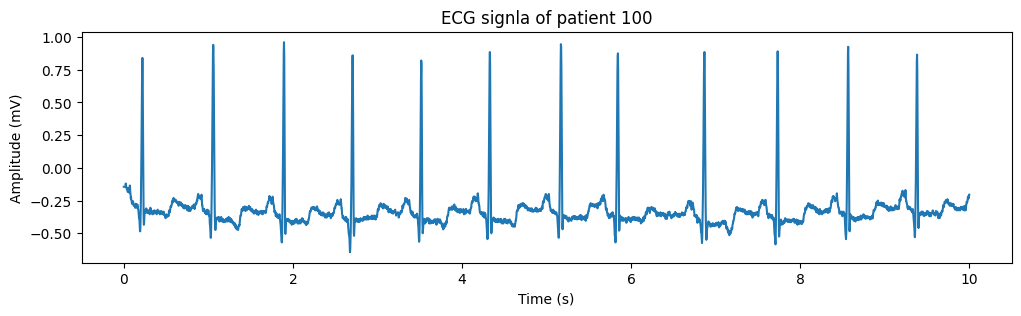

In [ ]:
# Plot any patient signal from any time frame
patient_id = 100 # can change
starting_time = 0 # can change
ending_time = 10 # can change

# Scaling
starting_signal_point = starting_time*350
ending_signal_point = ending_time*350 # As sampling frequency is 350 Hz
x = np.arange(starting_time, ending_time, 1/350)
signal = lead0[patient_id][starting_signal_point: ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f'ECG signla of patient {patient_id}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')

In [ ]:
# ECG info of any patient
ecg_info = get_ecg_info(patient_ids[0])
ecg_info

{'fs': 360,
 'sig_len': 650000,
 'n_sig': 2,
 'base_date': None,
 'base_time': None,
 'units': ['mV', 'mV'],
 'sig_name': ['MLII', 'V5'],
 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'],
 'resolution': 2048}

# **Part B: Denoising, R-Peak Detection, Segmentation**

### **B1: Denoising**
Noise removing by using Discrete Wavelet Transform (DCT)

In [ ]:
# User defined fucntion for DWT and reconstruction
def denoise(data):
    # wavelet transform
    coeffs = pywt.wavedec(data=data, wavelet='db5', level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    # Threshold denoising
    threshold = (np.median(np.abs(cD1)) / 0.6745) * (np.sqrt(2 * np.log(len(cD1))))
    cD1.fill(0)
    cD2.fill(0)
    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    # Inverse wavelet transform to obtain the denoised signal
    rdata = pywt.waverec(coeffs=coeffs, wavelet='db5')
    return rdata

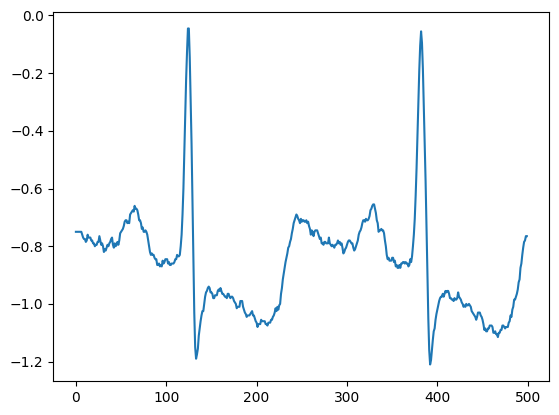

In [ ]:
# Ploting a signal before denoising
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
record = wfdb.rdrecord(project_path + '112', channel_names=['MLII'])
data = record.p_signal.flatten()
plt.plot(data[0:500])

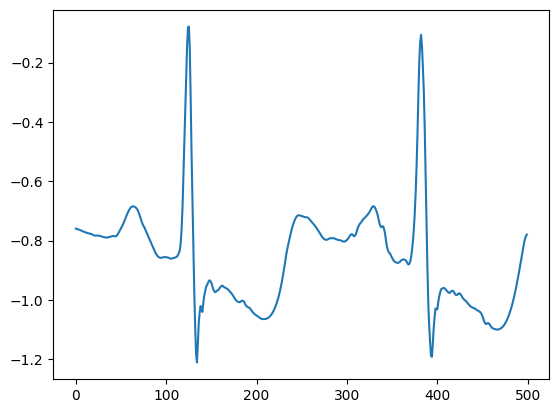

In [ ]:
# Same signal after denoising
rdata = denoise(data=data)
plt.plot(rdata[0:500])

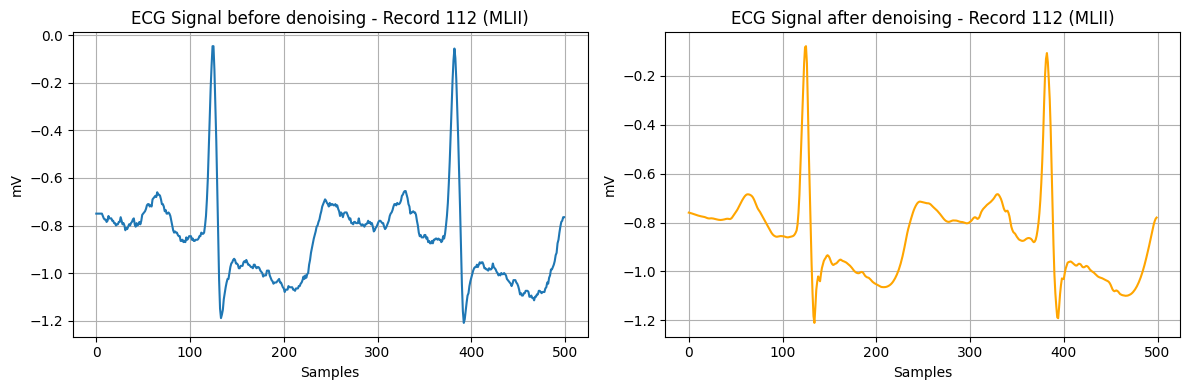

In [ ]:
record_id = 112
plt.figure(figsize=(12, 4))
# Before
plt.subplot(1, 2, 1)
plt.plot(data[0:500])
plt.title(f"ECG Signal before denoising - Record {record_id} (MLII)")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
# After
plt.subplot(1, 2, 2)
plt.plot(rdata[0:500], color="orange")
plt.title(f"ECG Signal after denoising - Record {record_id} (MLII)")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.grid(True)
plt.tight_layout()
plt.show()

### **B2: R-Peak Detection**
R-peak is annotated in MIT-BIH dataset. Just need to read the file.

In [ ]:
import wfdb
# Use a raw string or escape spaces
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# Make sure the file exists
!ls "/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# Load annotation for record '100'
annotation = wfdb.rdann(project_path + '100', 'atr')
# Extract R-peak locations and classes
Rlocation = annotation.sample
Rclass = annotation.symbol
print(Rlocation)
print(Rclass)
import wfdb
import textwrap
# Path to your MIT-BIH dataset folder
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# List of MIT-BIH record numbers
records = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
    111, 112, 113, 114, 115, 116, 117, 118, 119,
    121, 122, 123, 124, 200, 201, 202, 203, 205,
    207, 208, 209, 210, 212, 213, 214, 215, 217,
    219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234
]
# Function to print symbols in a grid layout
def print_in_grid(symbols, cols=20):
    for i in range(0, len(symbols), cols):
        print(", ".join(symbols[i:i+cols]))
# Loop through each record and display details
for record in records:
    try:
        annotation = wfdb.rdann(f"{project_path}{record}", 'atr')
        Rlocation = annotation.sample
        Rclass = annotation.symbol
        print("="*80)
        print(f"Record: {record}")
        print("-"*80)
        print(f"Total number of annotations: {len(Rclass)}\n")
        print("R-peak classes (symbols):")
        print_in_grid(Rclass, cols=25)  # Adjust number of columns here if needed
        print("\nR-peak locations (first 20 sample indices):")
        print(", ".join(map(str, Rlocation[:20])) + (" ..." if len(Rlocation) > 20 else ""))
        print("="*80 + "\n")
    except Exception as e:
        print("="*80)
        print(f"Record: {record} - Error reading annotation: {e}")
        print("="*80 + "\n")

Streaming output truncated to the last 5000 lines.
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, A, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N

Record: 100
--------------------------------------------------------------------------------
Total number of annotations: 2274

R-peak classes (symbols):
+, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

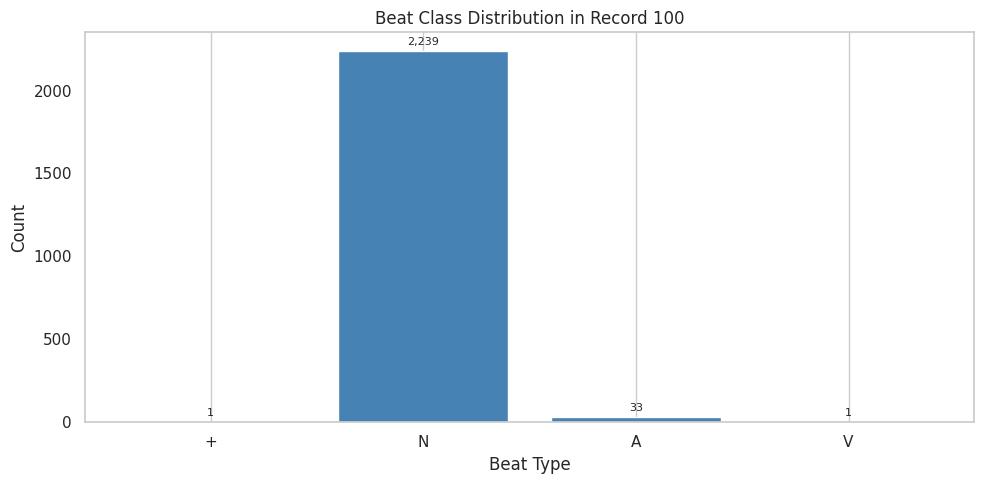

Record: 101
--------------------------------------------------------------------------------
Total number of annotations: 1874

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, ~, N, |, N, N, N, N, ~, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, |, N, |, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

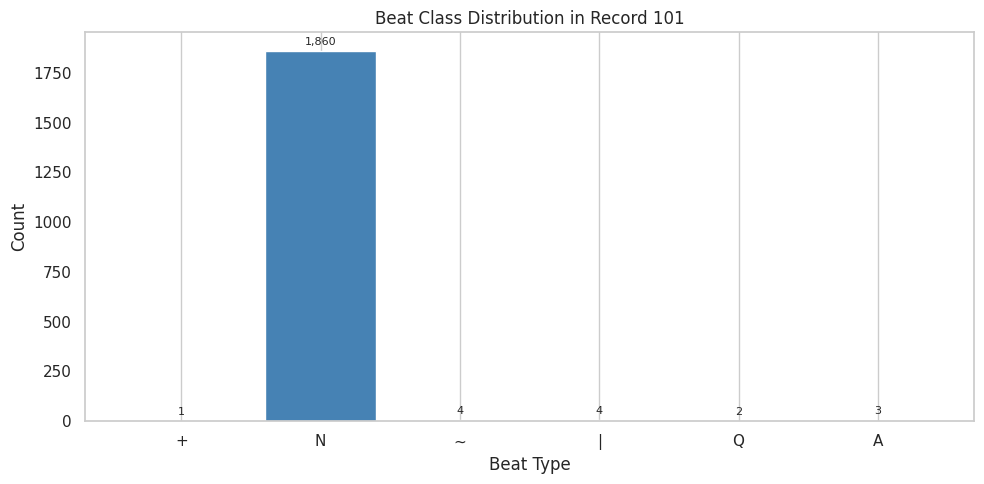

Record: 102
--------------------------------------------------------------------------------
Total number of annotations: 2192

R-peak classes (symbols):
+, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, f, f, f, f, f, f, +
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, +, /, /, /, /, /, /
f, f, f, f, f, f, f, f, f, +, N, N, N, N, N, N, N, N, N, f, N, N, f, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, f, +, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /,

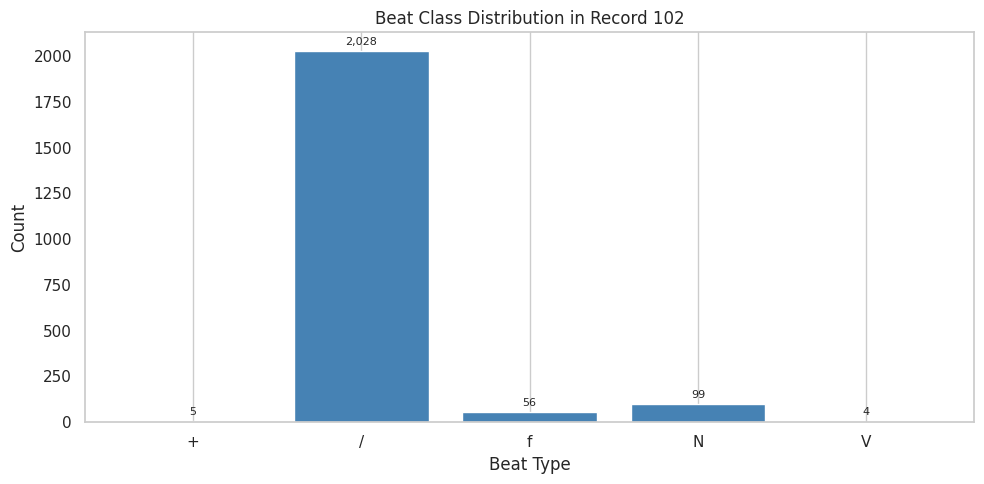

Record: 103
--------------------------------------------------------------------------------
Total number of annotations: 2091

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

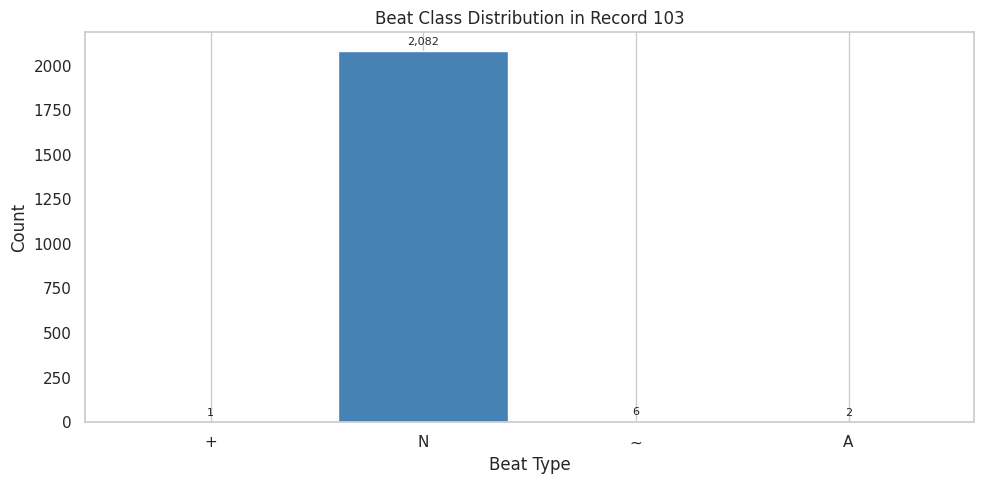

Record: 104
--------------------------------------------------------------------------------
Total number of annotations: 2311

R-peak classes (symbols):
+, /, /, /, /, /, f, f, /, /, /, /, /, f, f, /, /, /, /, /, f, f, /, /, /
/, /, ~, f, f, /, /, ~, /, /, /, f, f, /, /, /, /, f, f, f, /, /, /, /, /
f, f, /, /, /, /, /, f, f, /, /, /, /, /, /, f, f, /, /, /, /, /, f, f, f
/, /, /, /, ~, /, +, Q, Q, Q, +, /, /, ~, /, /, /, f, f, /, /, /, /, /, /
N, f, f, /, /, /, /, /, f, f, f, f, /, /, /, /, /, /, +, N, N, f, f, +, /
/, /, /, /, /, N, f, f, /, /, /, ~, /, /, /, N, f, /, /, /, /, /, /, N, f
f, ~, /, /, /, /, /, /, f, N, f, f, /, /, /, /, /, /, /, f, N, f, f, /, /
/, /, /, /, /, /, f, N, f, f, f, ~, f, /, /, /, /, ~, /, /, /, /, /, /, +
N, N, N, f, f, f, f, +, /, /, ~, /, /, /, /, /, /, +, N, N, f, f, ~, +, /
/, /, ~, /, ~, /, /, /, ~, f, N, f, f, /, /, /, /, /, /, /, +, N, ~, N, f
f, f, +, /, /, ~, /, /, /, /, /, /, /, /, ~, /, +, N, N, f, f, f, f, f, f
f, f, f, f, f, f, f, f, f, f, ~,

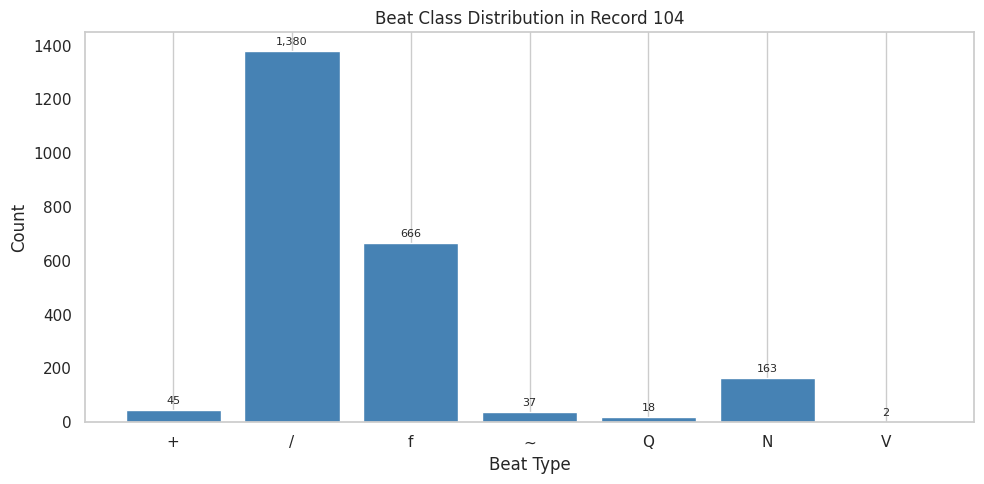

Record: 105
--------------------------------------------------------------------------------
Total number of annotations: 2691

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N
N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N, ~, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, V, N, N,

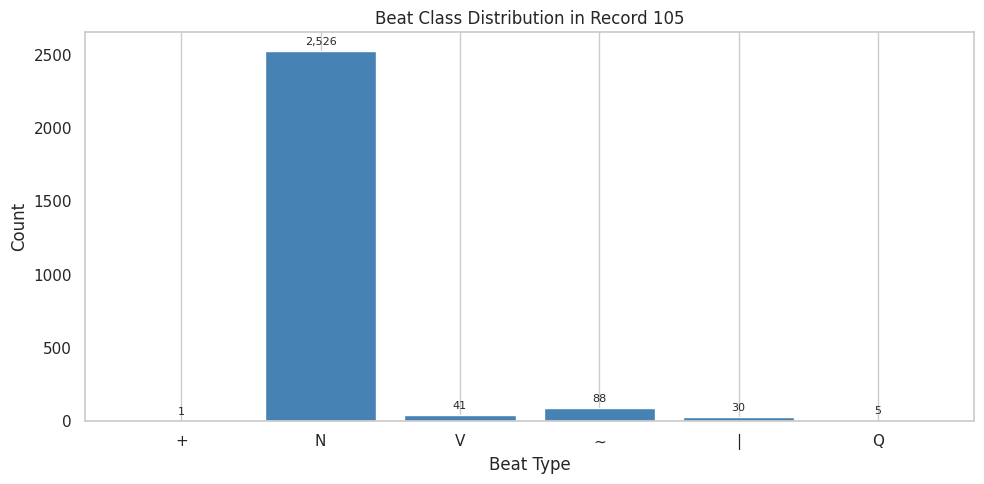

Record: 106
--------------------------------------------------------------------------------
Total number of annotations: 2098

R-peak classes (symbols):
~, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, ~, N, V, V, N, V, V, N, N, V, N, V, V, N, V, N, V, V, N, N
V, V, N, V, V, N, N, V, V, N, N, V, V, N, V, N, V, V, N, V, N, V, N, V, V
N, V, N, V, V, N, V, N, V, V, N, V, V, N, V, V, N, V, N, V, V, N, V, N, V
V, N, V, N, N, N, V, V, N, V, V, N, V, N, ~, N, N, N, N, V, V, N, V, N, V
V, ~, N, +, V, N, V, N, V, +, N, N, N, N, N, ~, N, +, V, V, V, +, N, V, N
N, N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

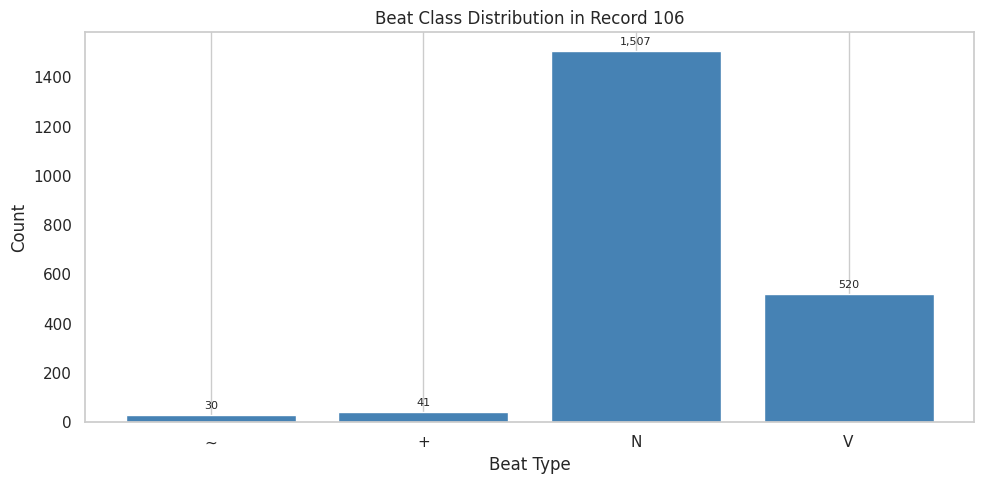

Record: 107
--------------------------------------------------------------------------------
Total number of annotations: 2140

R-peak classes (symbols):
+, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, V, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /,

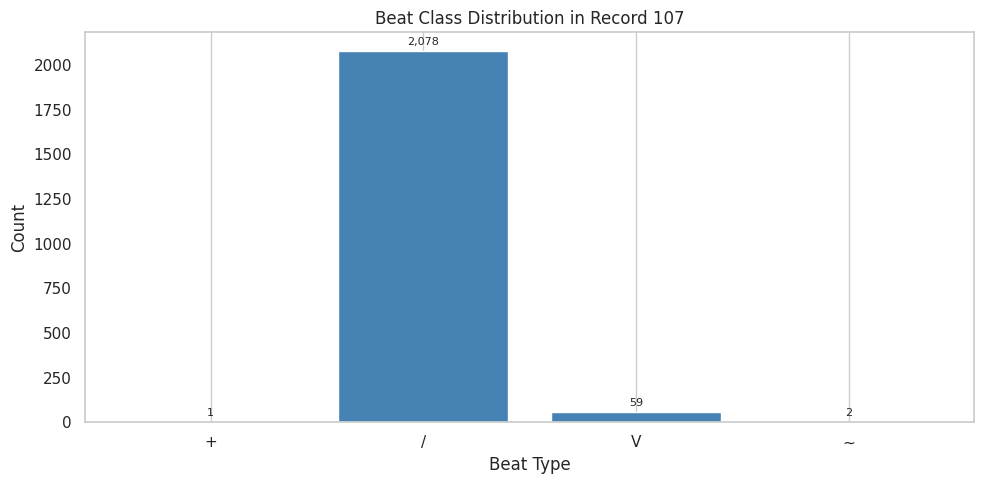

Record: 108
--------------------------------------------------------------------------------
Total number of annotations: 1824

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, V, x, N, N, N, N, N, N, N, N, N, N
N, N, N, N, ~, N, N, ~, N, V, x, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, ~, N, N, N, N, N, N, N, ~, N, ~, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N, N, N, N, N, N, N, N
N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, |, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

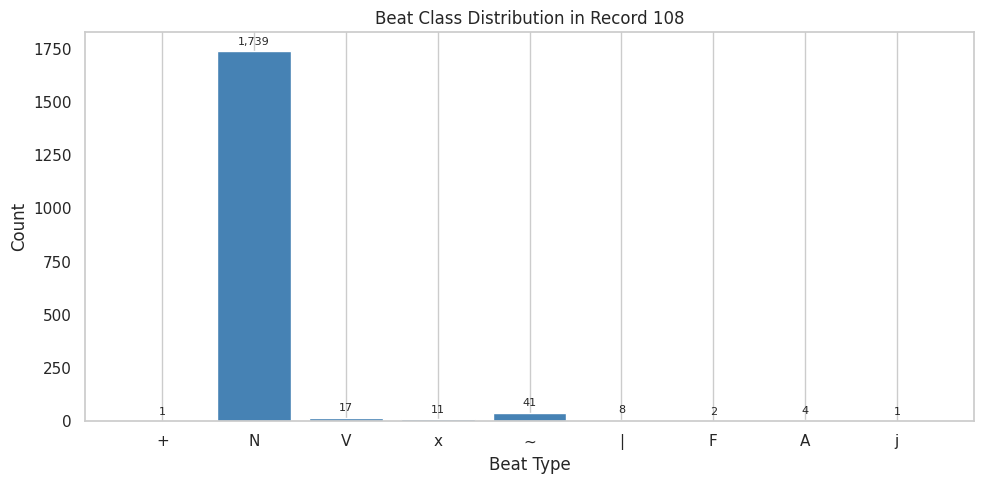

Record: 109
--------------------------------------------------------------------------------
Total number of annotations: 2535

R-peak classes (symbols):
+, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, F, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
F, L, L, L, L, L, L, L, L, L, L, V, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, V, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, V, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, V, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L,

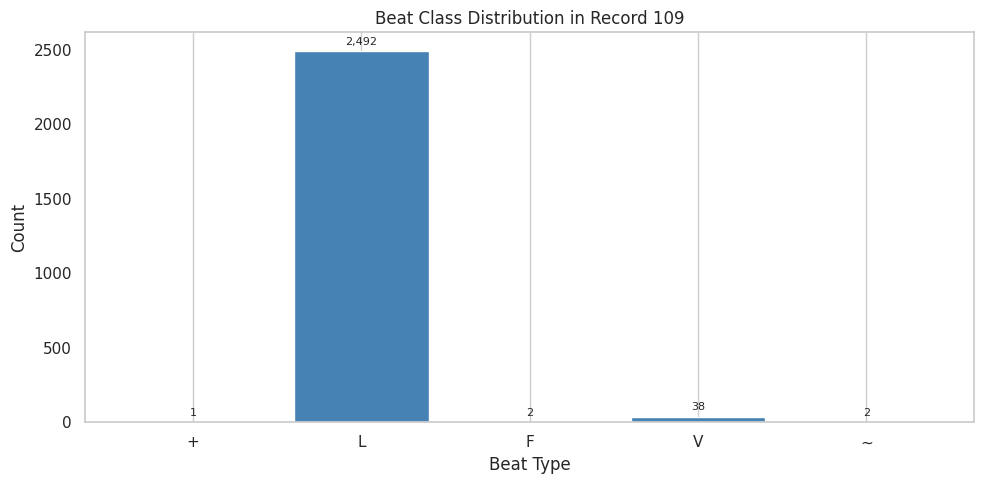

Record: 111
--------------------------------------------------------------------------------
Total number of annotations: 2133

R-peak classes (symbols):
+, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, ~, L, L, L, L, ~, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, ~, L, L, L, L, L, ~, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L,

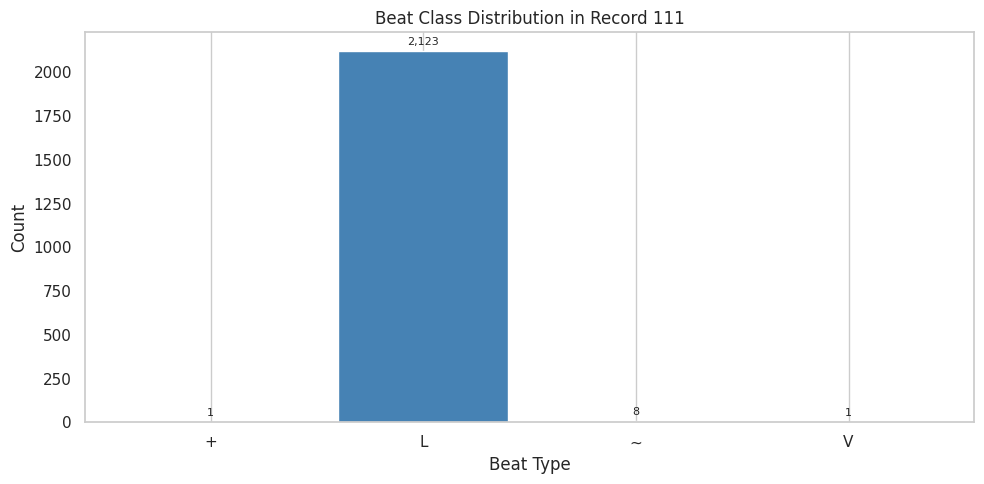

Record: 112
--------------------------------------------------------------------------------
Total number of annotations: 2550

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

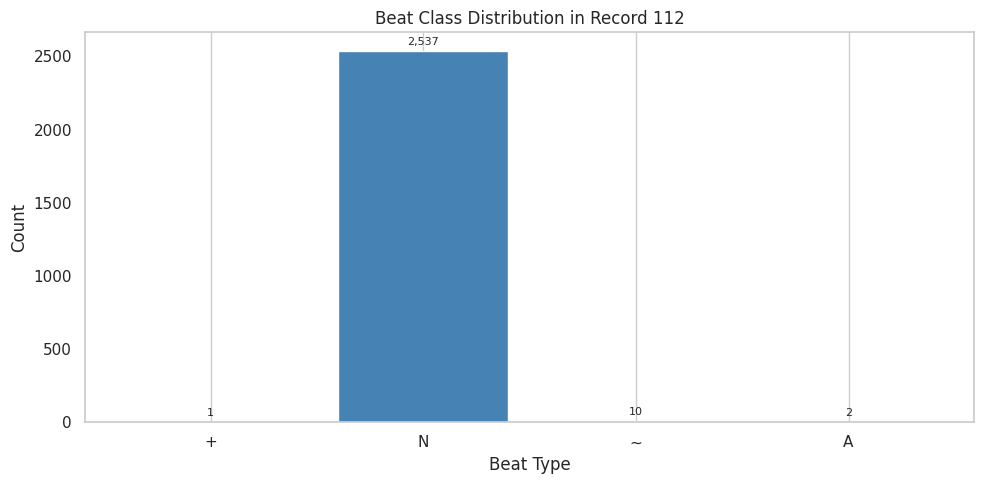

Record: 113
--------------------------------------------------------------------------------
Total number of annotations: 1796

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, a
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

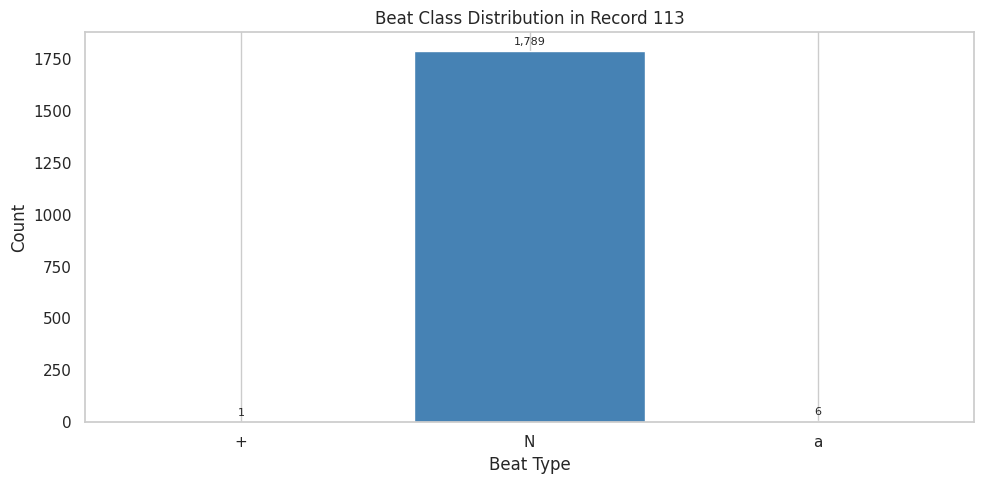

Record: 114
--------------------------------------------------------------------------------
Total number of annotations: 1890

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N
N, N, N, V, J, N, N, N, V, N, N, N, N, V, N, N, N, N, V, N, N, N, N, N, N
N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, V, N, N, N, N, V, N, N, N, N
V, N, N, N, N, V, N, N, N, N, N,

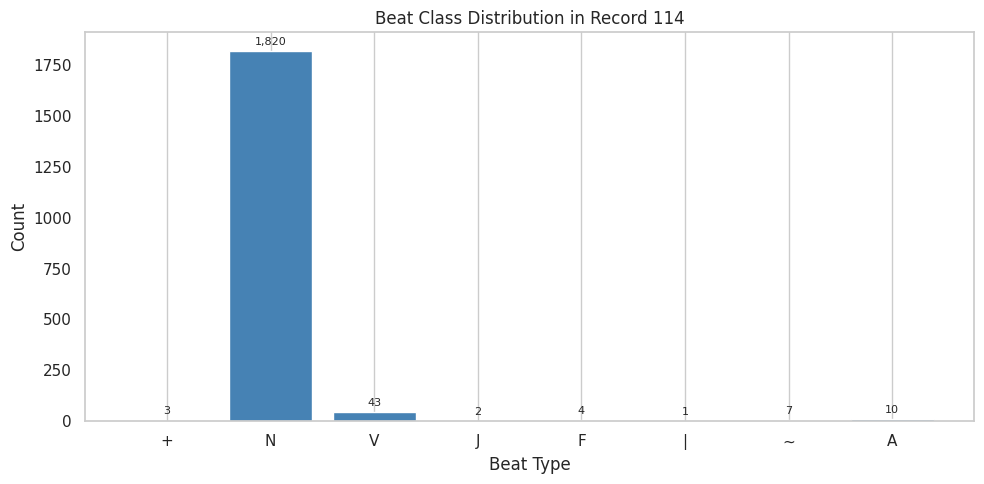

Record: 115
--------------------------------------------------------------------------------
Total number of annotations: 1962

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

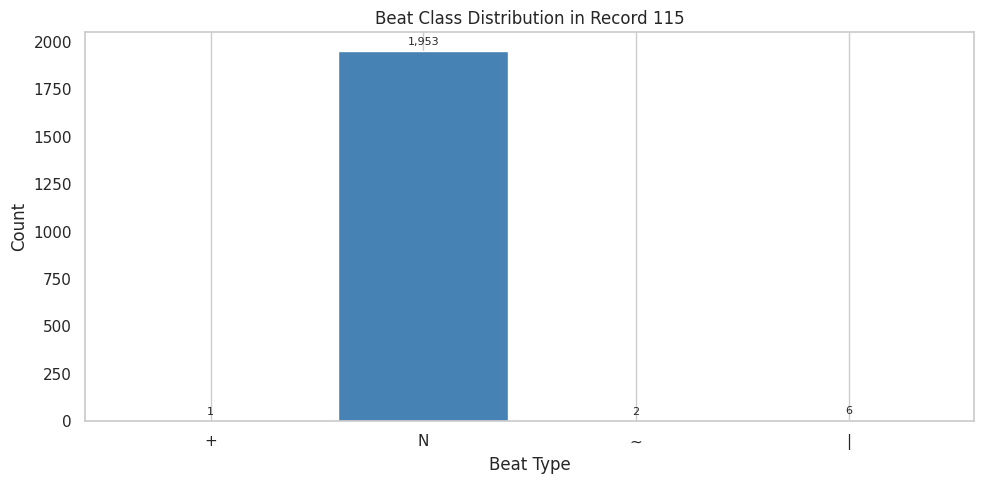

Record: 116
--------------------------------------------------------------------------------
Total number of annotations: 2421

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, V, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N
N, N, N, N, V, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N
N, N, N, N, N, N, N, N, N, N, N,

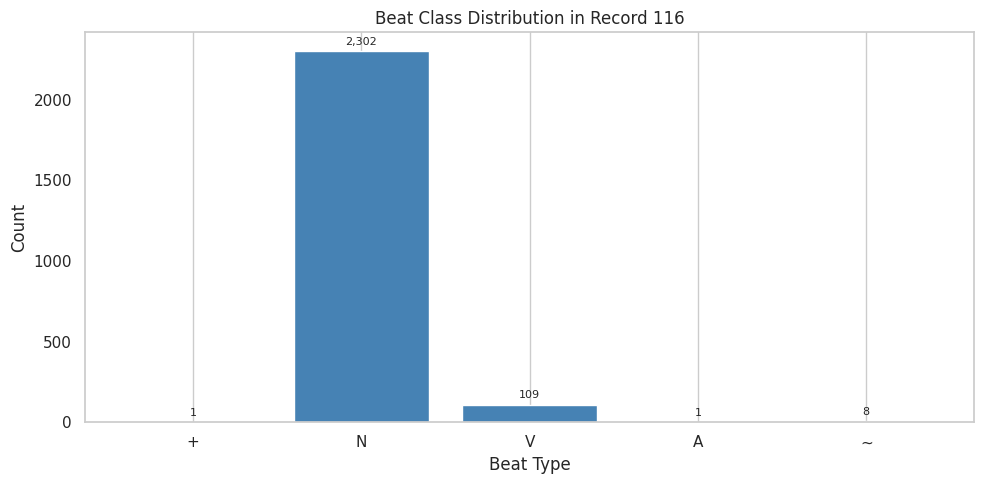

Record: 117
--------------------------------------------------------------------------------
Total number of annotations: 1539

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

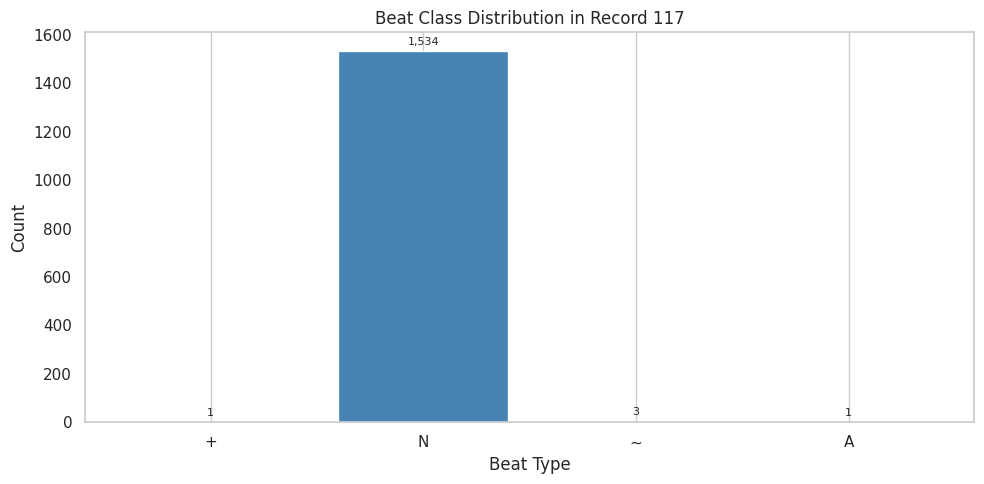

Record: 118
--------------------------------------------------------------------------------
Total number of annotations: 2301

R-peak classes (symbols):
+, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, V, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, A, R, R, R, R, R, A, R, R, R, R
R, R, R, R, A, R, V, R, R, R, R, R, R, A, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, A, R, R, R, R, R, R, R, R, R, R, R, R, x, R, R, R, R
R, R, R, R, R, R, R, R, R, R, x, R, R, R, R, R, R, R, R, A, R, A, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, V
R, R, R, R, R, R, R, R, R, R, R,

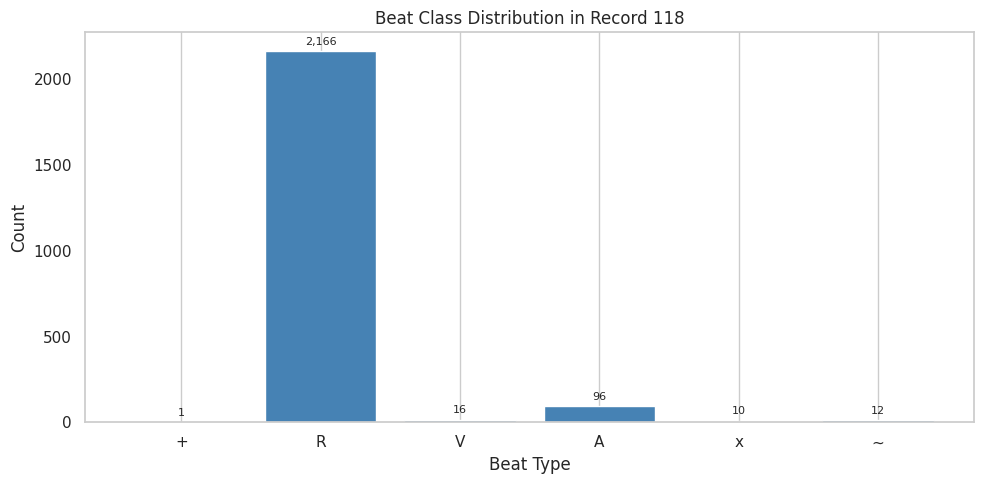

Record: 119
--------------------------------------------------------------------------------
Total number of annotations: 2094

R-peak classes (symbols):
+, N, V, N, N, N, N, N, V, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, +
V, N, V, N, V, N, V, N, V, N, V, +, N, N, N, N, N, +, V, N, V, N, V, N, V
+, N, N, N, N, N, V, N, N, V, N, N, V, N, V, N, N, +, V, N, V, N, V, +, N
N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, V, N, N, N, N, N, +, V, N
V, N, V, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, V, N, N, N, N
N, N, +, V, N, V, N, V, +, N, N, N, V, N, N, V, N, N, N, N, N, V, N, N, N
N, N, N, N, N, N, N, N, N, V, N, N, V, N, N, V, N, V, N, N, V, N, N, N, N
N, +, V, N, N, V, N, N, V, N, N, V, N, N, V, +, N, V, N, N, +, V, N, V, N
V, N, V, N, V, N, V, +, N, N, N, N, N, N, V, N, V, N, N, N, +, V, N, V, N
V, +, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, V, N, V, N, N, N, V
N, +, V, N, N, V, N, N, V, N, N,

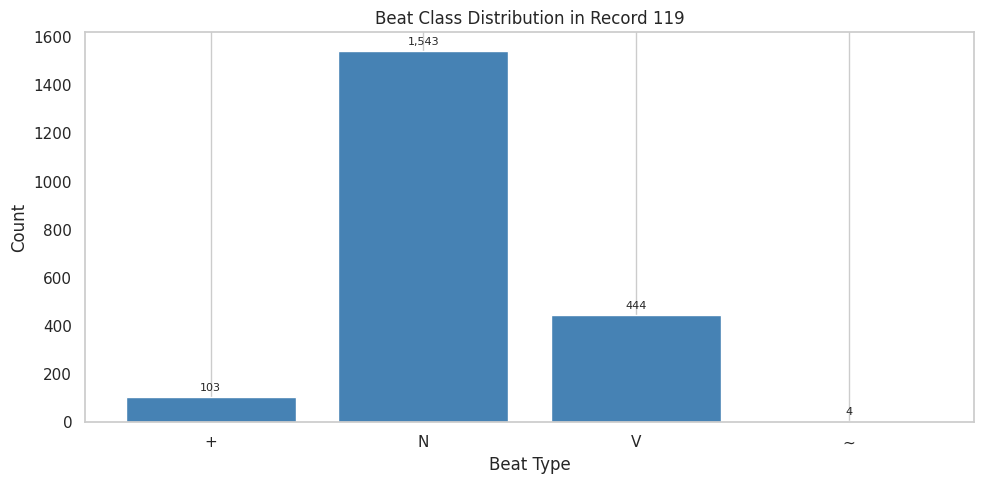

Record: 121
--------------------------------------------------------------------------------
Total number of annotations: 1876

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, ~, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

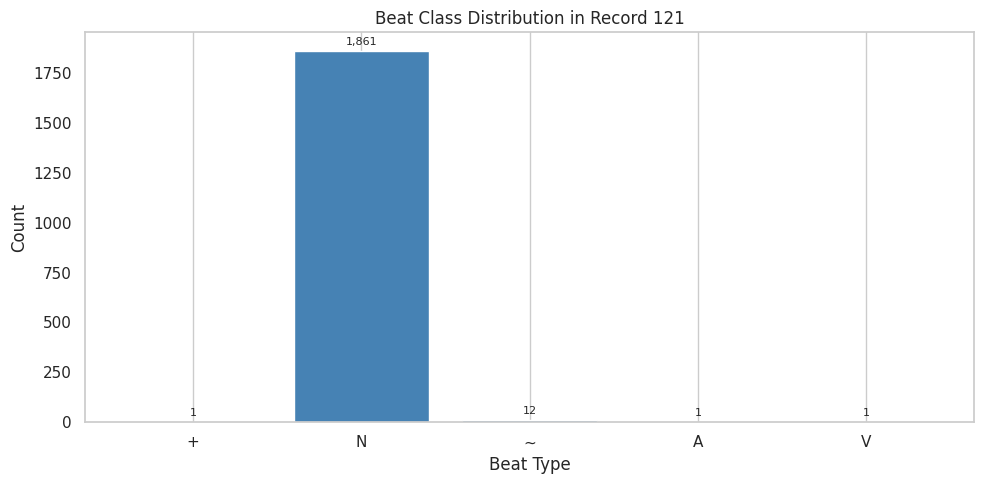

Record: 122
--------------------------------------------------------------------------------
Total number of annotations: 2479

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

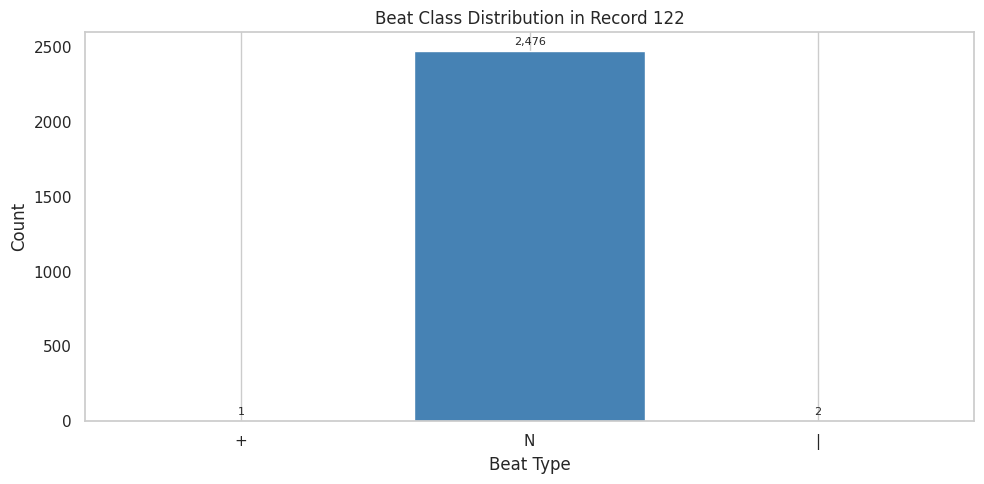

Record: 123
--------------------------------------------------------------------------------
Total number of annotations: 1519

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

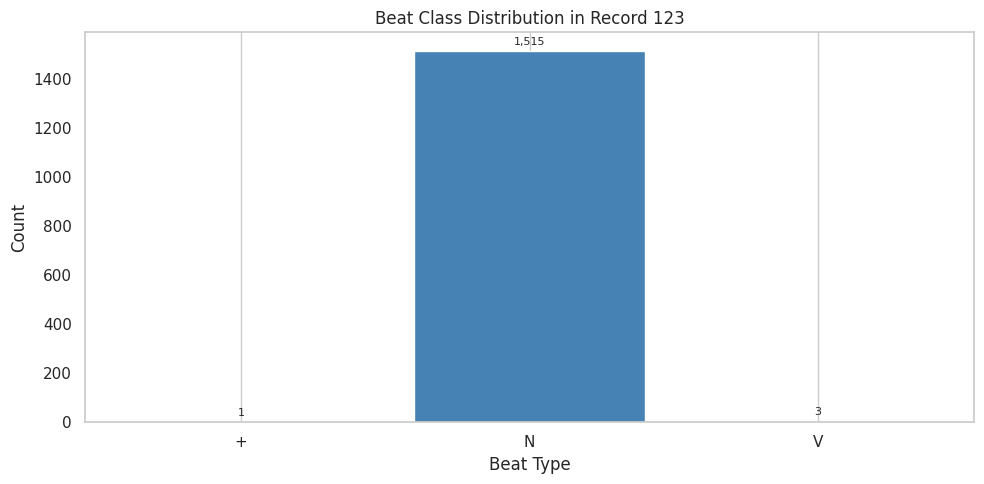

Record: 124
--------------------------------------------------------------------------------
Total number of annotations: 1634

R-peak classes (symbols):
+, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, +, J, J, J, J, J, J, J, J, J, J
J, J, J, J, V, J, J, J, V, J, J, J, J, J, J, +, F, V, V, V, V, V, V, V, V
V, V, V, V, V, V, V, V, V, V, F,

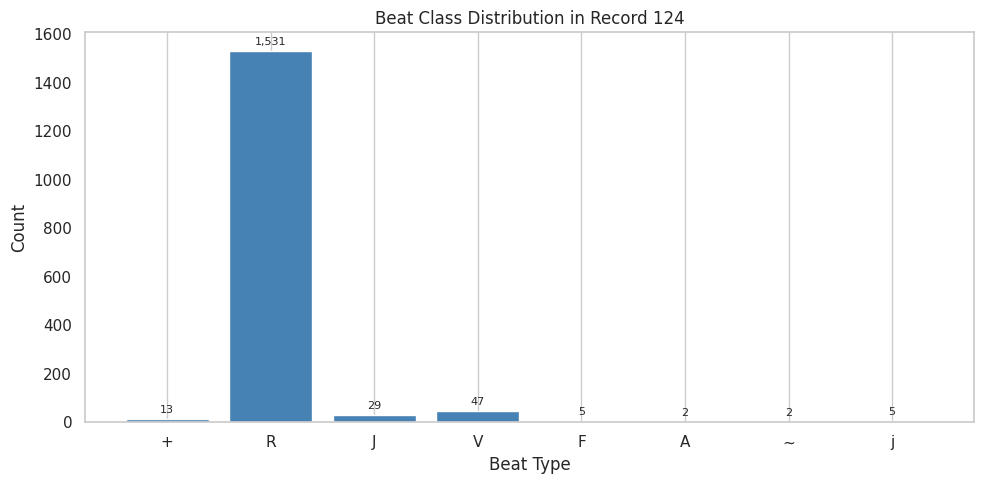

Record: 200
--------------------------------------------------------------------------------
Total number of annotations: 2792

R-peak classes (symbols):
+, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, +, N, N, N, N, N, N, N, N
N, N, N, V, N, V, N, V, V, N, V, N, V, V, N, V, N, N, N, N, N, N, N, N, N
N, N, V, N, V, V, N, V, N, N, +, V, N, V, N, V, +, N, N, +, V, N, V, N, V
N, V, N, V, +, N, N, +, V, N, V, N, V, N, V, N, V, N, V, N, V, +, N, N, N
N, N, N, N, N, N, N, N, N, V, N, V, V, N, +, V, N, V, N, V, N, V, N, V, N
V, +, N, N, N, +, V, N, V, N, V, N, V, N, V, N, V, +, N, N, N, N, N, N, N
N, N, N, N, +, V, N, V, N, V, N, V, N, V, N, V, N, +, V, V, V, +, N, V, N
V, N, V, N, V, +, N, N, +, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, +
N, N, +, V, N, V, N, V, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, V, N, V, V, N, +
V, N, V, N, V, N, V, N, V, N, V,

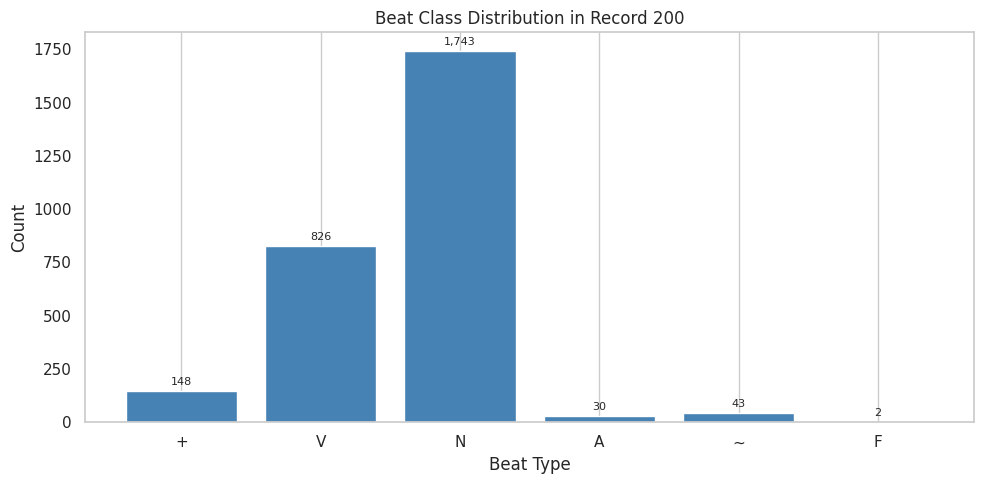

Record: 201
--------------------------------------------------------------------------------
Total number of annotations: 2039

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, a, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

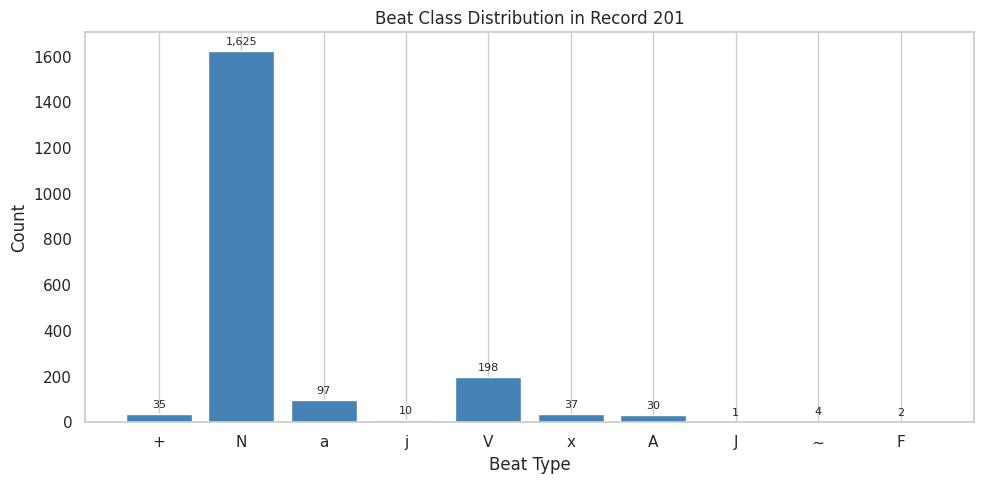

Record: 202
--------------------------------------------------------------------------------
Total number of annotations: 2146

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

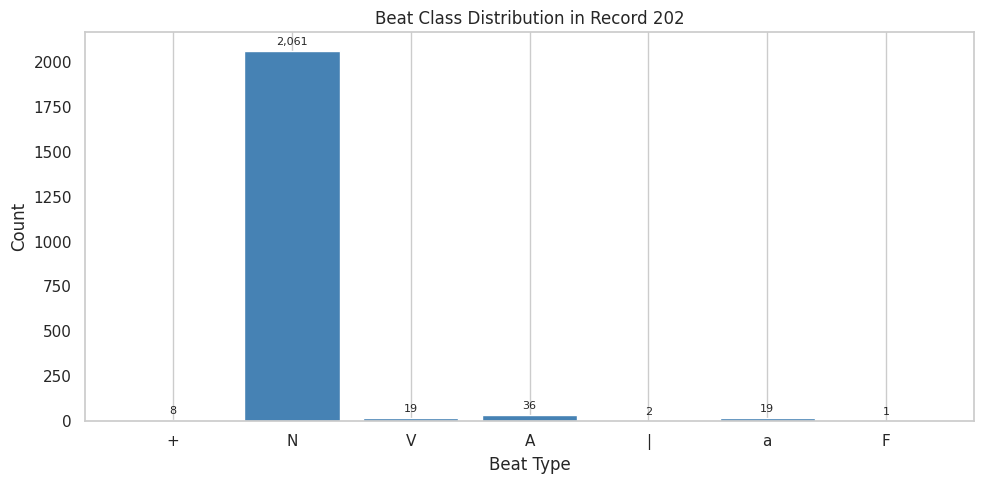

Record: 203
--------------------------------------------------------------------------------
Total number of annotations: 3108

R-peak classes (symbols):
+, ~, N, N, N, N, N, N, N, N, N, N, V, V, N, N, N, N, N, N, N, ~, N, V, N
N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
~, N, V, N, N, +, V, V, V, +, N, V, N, ~, N, N, N, N, N, N, N, N, N, V, N
N, N, N, N, N, N, N, N, N, N, V, V, N, V, N, N, N, N, N, N, V, N, V, N, N
N, N, N, N, N, N, V, N, N, N, V, V, N, N, N, N, N, V, N, N, N, N, N, N, N
N, N, N, N, V, N, N, N, N, N, N, N, N, N, +, V, V, V, +, N, V, ~, N, a, N
N, N, V, V, N, a, N, N, N, N, |, N, V, |, N, N, N, ~, N, N, +, V, V, V, +
N, N, N, V, V, N, N, N, N, N, N, N, N, N, V, N, V, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, V, N, N, N, V, N, N, N, N, N
V, N, N, N, V, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, V,

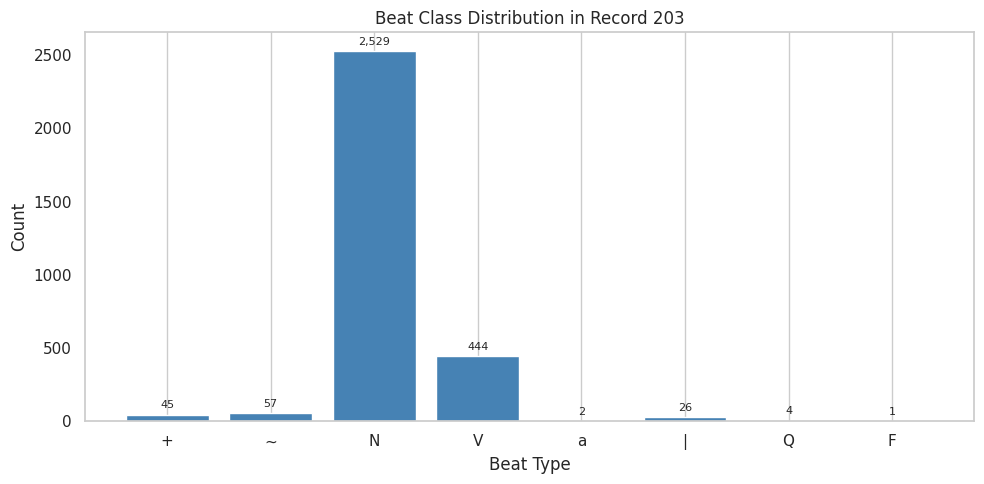

Record: 205
--------------------------------------------------------------------------------
Total number of annotations: 2672

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

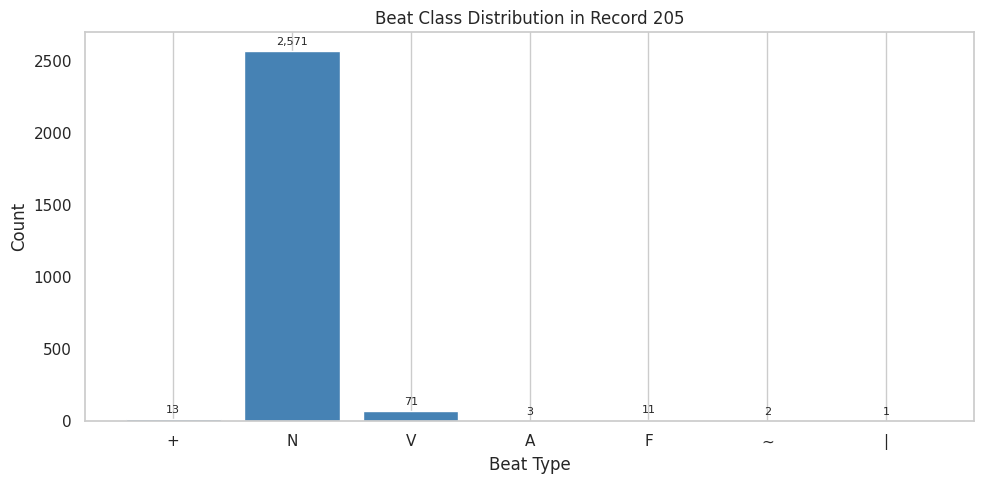

Record: 207
--------------------------------------------------------------------------------
Total number of annotations: 2385

R-peak classes (symbols):
+, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V
R, V, R, V, R, V, R, V, R, V, R, V, V, L, +, V, V, V, +, L, [, +, !, !, !
!, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !
], +, R, V, R, [, +, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, !, ], +
R, +, V, V, V, +, L, L, L, V, R, L, L, L, L, +, V, L, V, R, V, +, R, L, V
V, R, V, V, R, L, V, R, V, R, L, L, L, L, L, L, V, R, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, V, L, V, R, V, V, L, +, V, R, V, R, V, R, V, R, V, R, V, R, V, R
V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V
R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R
V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V, R, V
R, V, R, V, R, V, R, V, R, V, R,

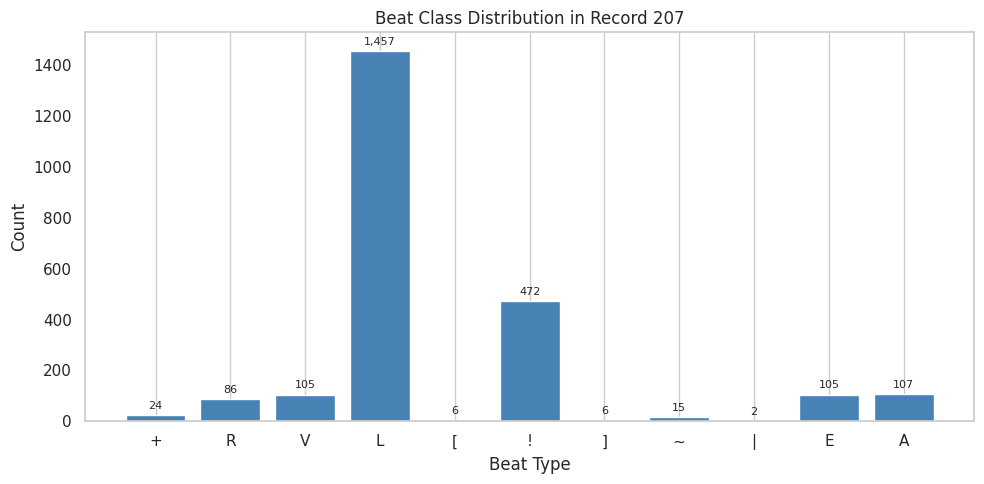

Record: 208
--------------------------------------------------------------------------------
Total number of annotations: 3040

R-peak classes (symbols):
+, F, V, N, F, V, N, V, V, N, V, V, N, V, V, N, V, V, N, F, V, N, F, V, N
F, V, N, V, V, ~, N, F, V, N, N, F, N, N, ~, N, V, N, N, N, V, N, N, N, V
N, N, N, V, N, N, N, V, N, N, N, V, N, N, N, N, ~, N, F, N, N, N, N, N, N
V, N, N, V, N, N, F, N, N, V, N, N, V, N, N, F, N, N, N, N, N, N, V, N, N
V, ~, N, N, F, V, N, F, V, N, N, V, N, N, F, +, V, N, N, V, N, N, V, N, N
V, V, N, F, V, N, F, V, N, N, V, N, N, V, +, N, N, V, V, N, V, V, N, F, V
N, N, N, N, N, V, V, N, V, V, N, F, V, N, N, F, N, N, N, N, N, F, V, N, F
+, V, N, N, V, N, N, V, +, N, N, F, V, N, N, N, N, N, F, V, N, V, V, N, F
V, N, N, V, N, V, V, N, V, V, N, V, V, N, F, V, N, V, V, N, F, V, N, F, V
N, F, V, N, F, V, N, F, V, N, F, +, V, N, N, V, N, N, V, N, N, V, N, N, +
V, N, V, V, N, V, V, N, V, V, N, F, V, N, F, +, V, N, N, V, N, N, V, N, N
V, +, N, F, V, N, V, V, N, F, V,

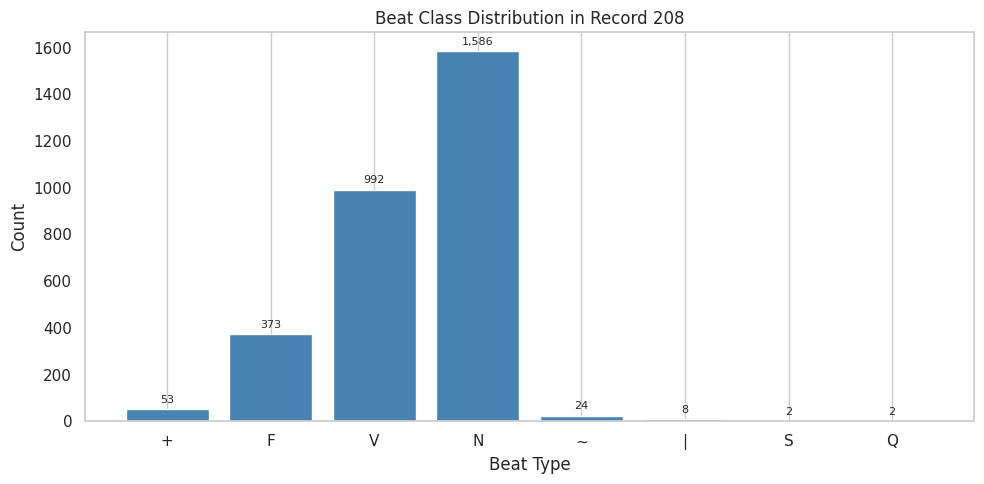

Record: 209
--------------------------------------------------------------------------------
Total number of annotations: 3052

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, A, N, N, N, |, N, N, N, N, N, N, N, N, N, |, N
N, A, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

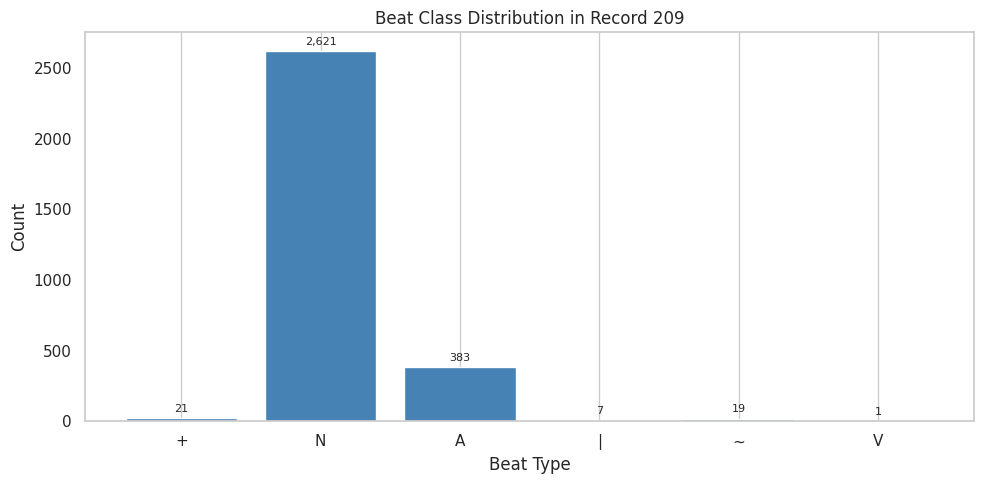

Record: 210
--------------------------------------------------------------------------------
Total number of annotations: 2685

R-peak classes (symbols):
+, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N
N, N, N, N, V, N, N, N, N, N, N, F, N, N, N, N, N, N, N, N, N, N, N, V, N
N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N
N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, V
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, V, V, N, V, N, V, N, N, V, N, V, N, N
V, N, N, V, V, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, ~, N, N, N, N, N,

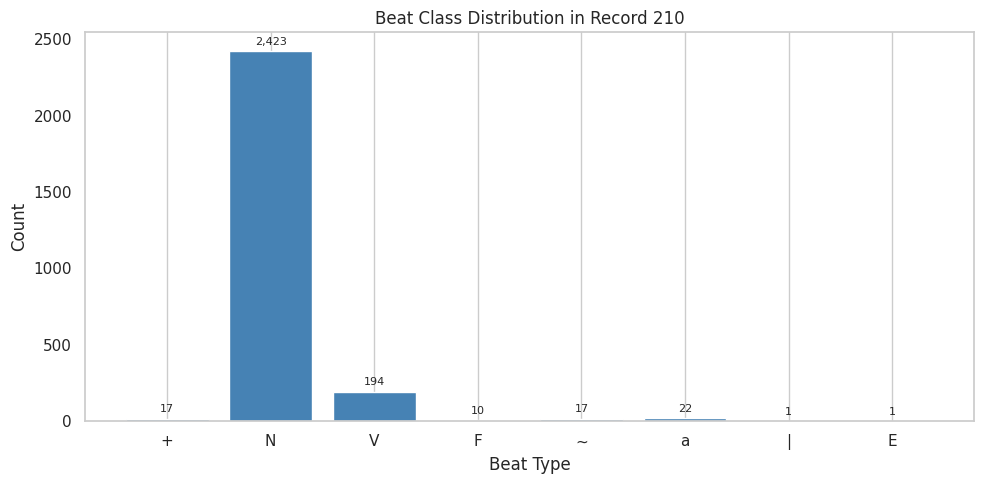

Record: 212
--------------------------------------------------------------------------------
Total number of annotations: 2763

R-peak classes (symbols):
+, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, R, R, R, R, R, R, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R,

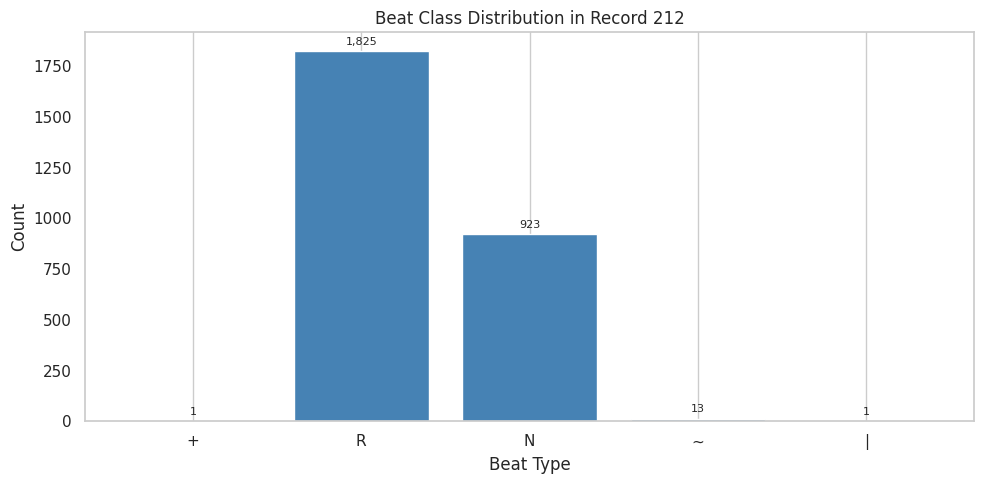

Record: 213
--------------------------------------------------------------------------------
Total number of annotations: 3294

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, F, N, N, N, N, A, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, F, N, N, N, N, N, N, N, N, N, N, N, N, N, F, N, F, N, F, N, V
N, F, N, F, N, F, N, N, N, F, N, F, N, F, N, F, N, F, N, F, N, F, N, F, N
F, N, F, N, F, N, V, N, F, N, F, N, F, N, N, N, N, N, N, N, N, N, F, N, F
N, +, V, N, V, N, V, +, N, F, N,

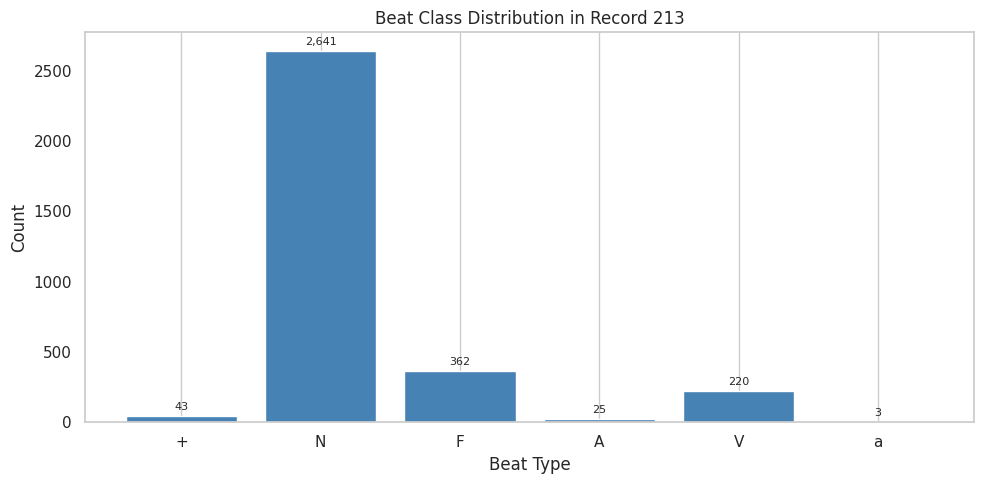

Record: 214
--------------------------------------------------------------------------------
Total number of annotations: 2297

R-peak classes (symbols):
+, L, L, L, L, L, L, L, V, L, L, L, V, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, V, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, ~, L
~, L, +, V, L, L, V, ~, L, L, ~, V, L, L, V, L, L, V, +, L, L, L, L, L, L
L, V, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L
L, V, L, L, L, L, L, L, V, L, L, L, L, L, L, L, V, L, L, L, V, L, L, L, V
L, L, L, L, L, L, L, L, L, L, |, L, L, L, L, L, V, L, L, L, L, L, V, L, L
L, L, L, L, L, L, L, V, L, L, V, L, L, L, V, V, L, L, L, L, L, L, L, L, V
L, L, L, V, L, L, V, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, V, L, L
L, L, L, V, L, L, L, L, L, L, L, V, L, L, L, L, L, V, L, L, L, L, L, L, L
L, L, L, L, L, V, L, L, L, L, L,

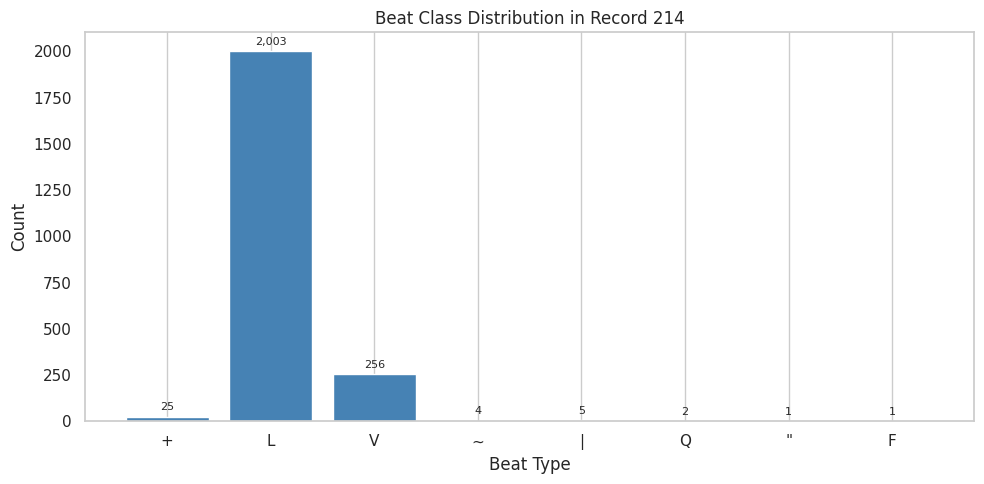

Record: 215
--------------------------------------------------------------------------------
Total number of annotations: 3400

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, V, V
N, N, N, N, N, V, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, V, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, V, N, N
N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, V, V, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, V, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N
N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

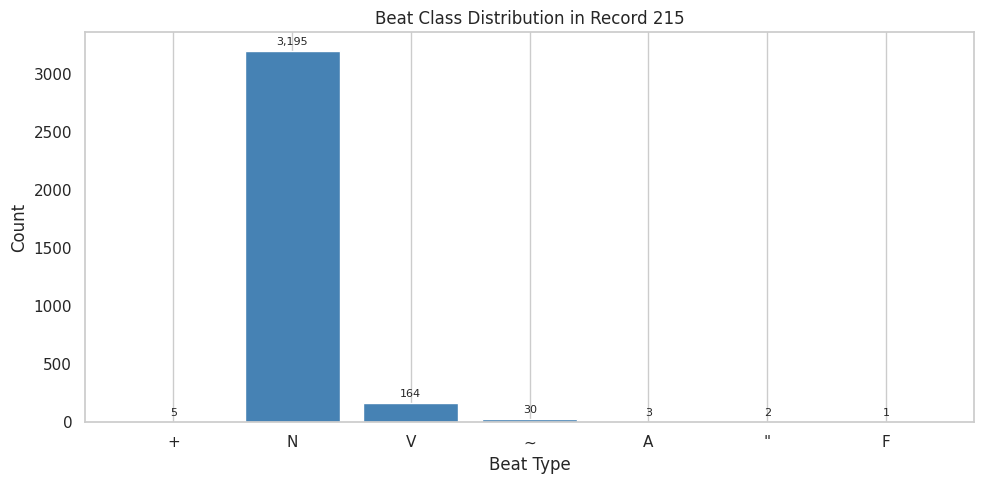

Record: 217
--------------------------------------------------------------------------------
Total number of annotations: 2280

R-peak classes (symbols):
+, /, /, /, /, /, f, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, V, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, f, V, f, V
/, /, /, /, f, +, V, f, V, f, V, f, V, +, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, V, f, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, f, V, f, N, f
/, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, f, f, N, V, /, /
/, /, f, +, N, N, V, +, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /, /
f, /, f, f, N, V, f, f, f, V, /, /, /, /, /, /, /, f, /, /, /, /, /, /, /
/, /, /, /, /, /, /, /, /, /, /,

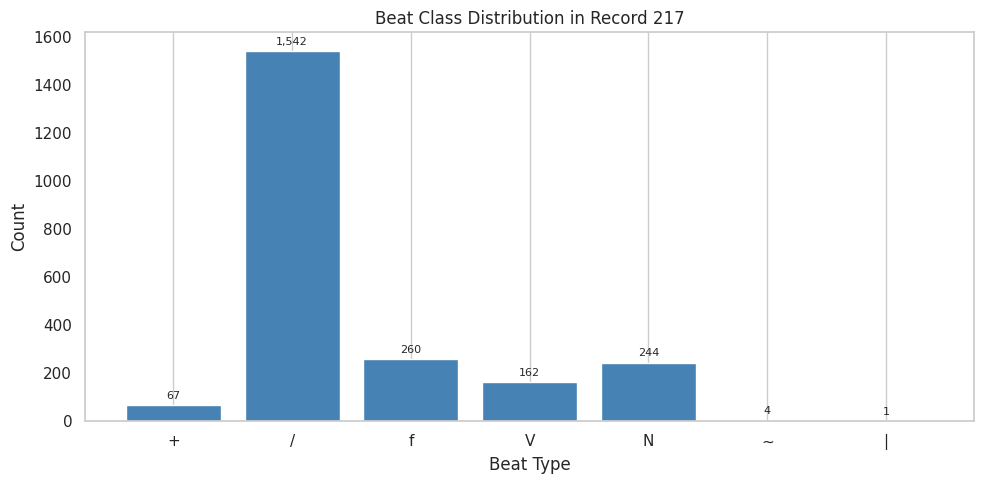

Record: 219
--------------------------------------------------------------------------------
Total number of annotations: 2312

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, V, N, N
V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, +, V, N, N, V, N, N, V
N, N, V, N, N, V, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
F, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, V, N, N, N, N,

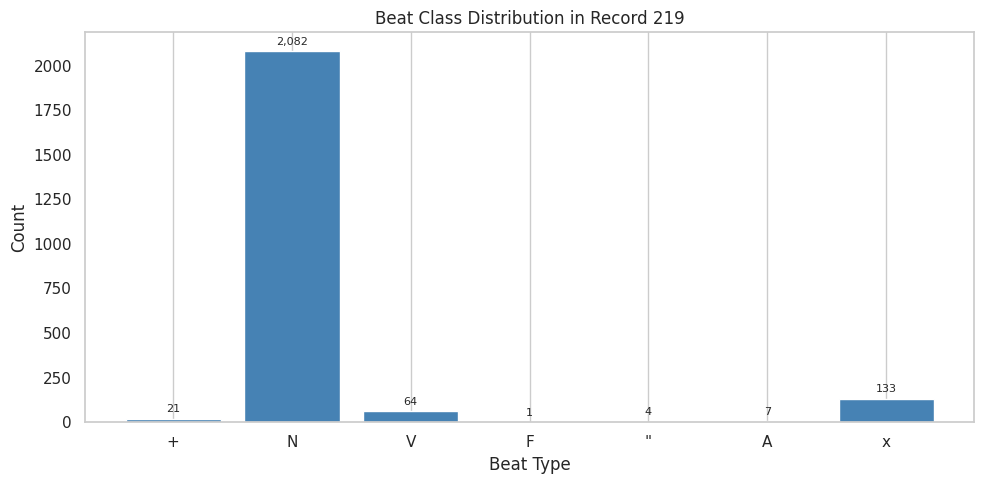

Record: 220
--------------------------------------------------------------------------------
Total number of annotations: 2069

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, A, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

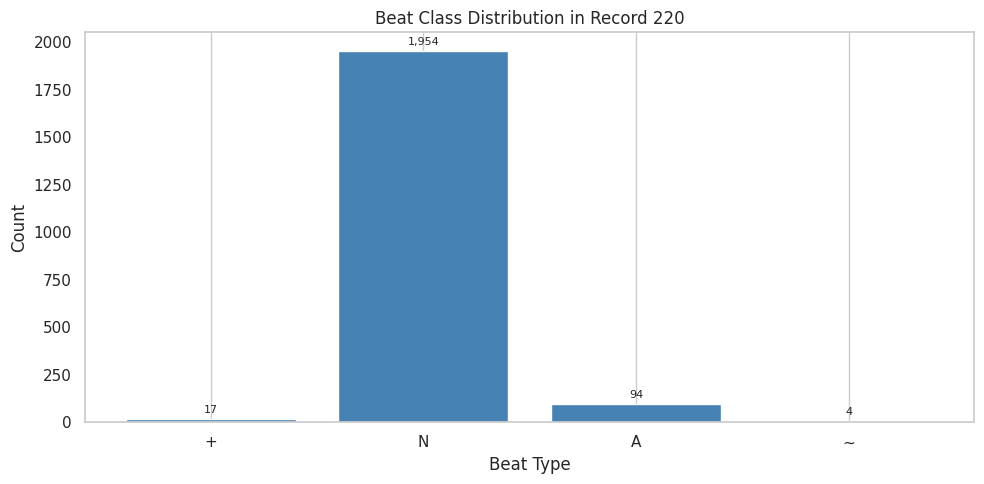

Record: 221
--------------------------------------------------------------------------------
Total number of annotations: 2462

R-peak classes (symbols):
+, N, N, V, N, N, V, N, N, N, V, N, N, N, N, N, N, N, N, N, V, N, N, N, V
N, N, N, V, N, N, N, N, N, N, N, N, N, N, V, N, N, N, V, N, N, N, N, V, N
N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, V
N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, V, N, N, N, V, N, N, N
V, N, N, N, N, V, N, N, N, N, V, N, N, N, N, N, N, N, N, V, N, N, V, N, N
N, N, V, N, N, N, N, N, V, N, N, N, V, N, N, N, N, N, N, N, V, N, N, N, V
N, N, N, N, V, N, N, V, N, N, N, N, N, N, V, N, N, V, N, N, N, V, N, N, N
N, V, N, N, V, N, N, N, V, N, N, N, V, N, N, N, V, N, N, V, N, N, N, N, N
N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, V, N, N, N, V, N, N, N, N, N
N, N, V, V, N, V, N, N, V, N, N, N, N, V, N, N, N, V, N, N, N, V, N, N, N
V, N, N, N, V, N, N, N, N, N, N, N, N, N, V, N, N, N, N, V, N, N, N, V, N
N, N, V, N, N, N, N, N, N, V, N,

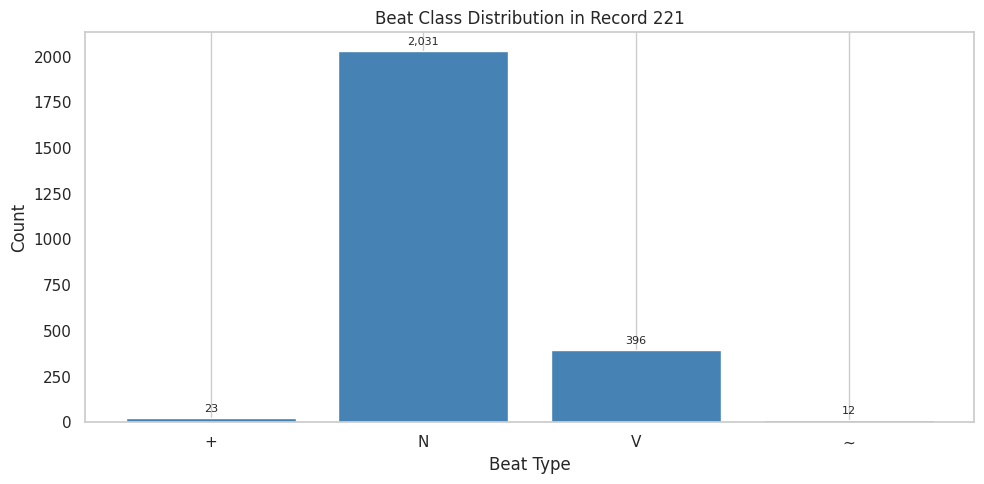

Record: 222
--------------------------------------------------------------------------------
Total number of annotations: 2634

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, ~, N, N, N, N, ~, N, N, N, N, ~, N, N, ~, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

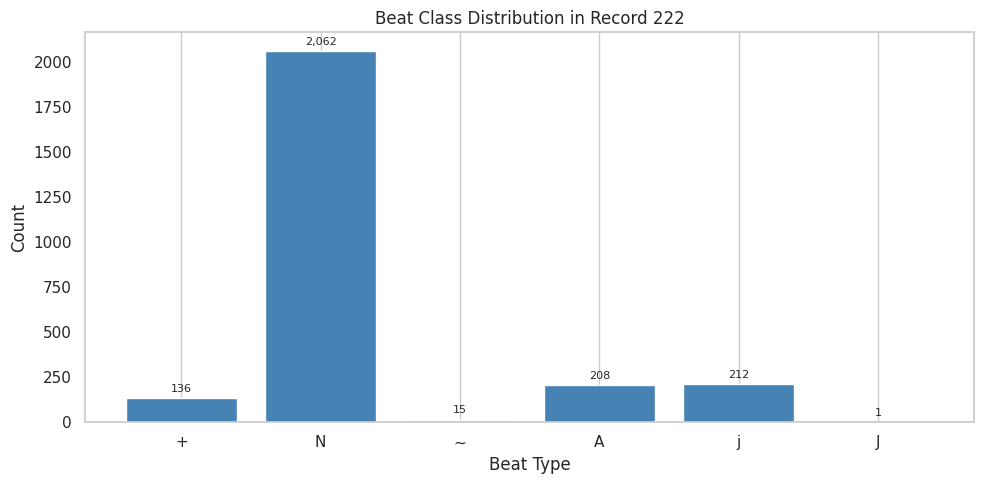

Record: 223
--------------------------------------------------------------------------------
Total number of annotations: 2643

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, V, N, N, A, N, N, N, N, N, N, N, N, N, N, N, V, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, V, V, e, +, V, N, N, V, N, N, V, N, N, V, N
N, V, N, N, V, N, N, V, N, N, V, +, N, V, V, N, N, N, F, N, N, N, F, N, N
N, F, N, N, N, F, N, N, N, F, N, N, N, F, ~, N, N, N, N, N, N, N, ~, N, N
V, N, N, N, N, N, N, N, N, N, N, N, A, N, N, A, N, N, N, N, N, N, N, N, N
N, N, N, N, N, A, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

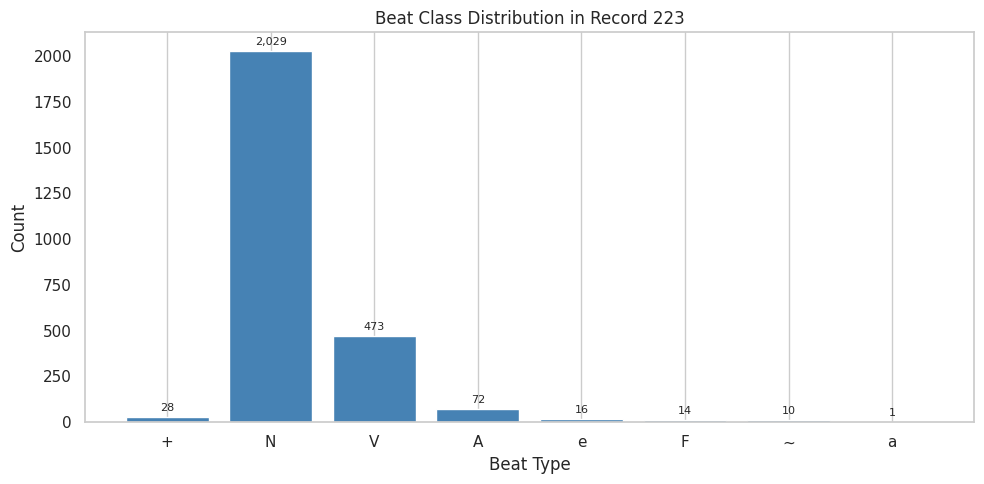

Record: 228
--------------------------------------------------------------------------------
Total number of annotations: 2141

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, |, N, N, |, N, |, N
+, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, N, V, +, N, N
N, N, N, N, N, N, N, N, N, N, |, |, N, |, |, |, N, N, |, |, N, N, N, N, N
V, N, N, N, V, V, N, N, N, ~, N, N, N, N, ~, V, N, N, N, V, N, V, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, V, N, V, N, N
N, +, V, |, N, V, |, N, V, N, V, N, V, N, |, V, N, V, N, V, N, V, N, V, N
V, |, |, N, V, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, +, V, N
V, N, V, +, N, N, N, N, N, N, N, N, N, N, N, N, N, +, V, N, V, N, V, +, N
N, N, V, N, N, N, N, N, V, N, N, N, N, V, ~, N, N, N, V, N, N, N, N, N, V
N, V, N, N, N, N, N, N, N, N, N, N, |, N, N, ~, N, V, N, N, N, N, N, N, ~
N, N, N, N, N, ~, V, N, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, V, N
N, N, N, N, N, N, N, N, V, N, V,

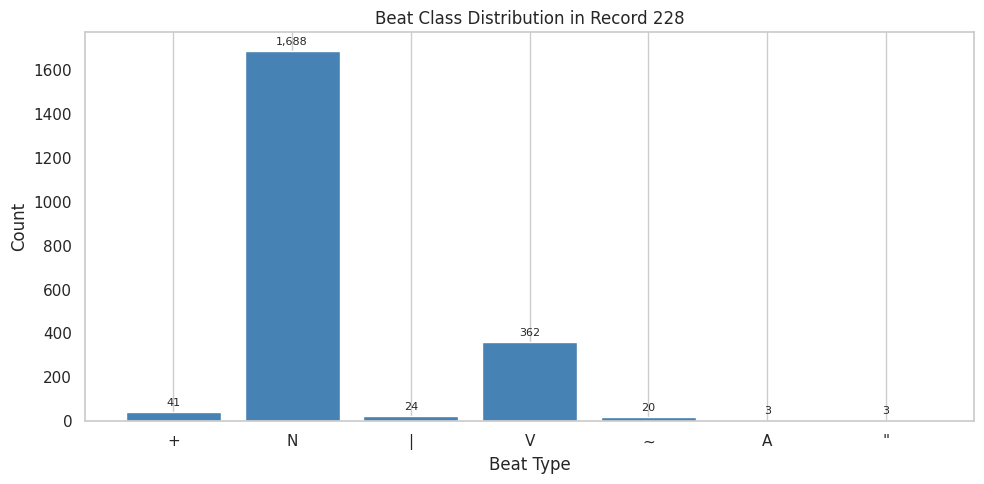

Record: 230
--------------------------------------------------------------------------------
Total number of annotations: 2466

R-peak classes (symbols):
+, N, N, N, N, N, N, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, +, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, +, N, N, N, N, N, N, +, N, N, N
N, N, N, N, +, N, N, N, N, N, N, N, N, +, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, +, N, N, N, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, +, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, +, N
+, N, +, N, N, N, N, N, +, N, N, N, N, N, N, N, N, N, +, N, +, N, N, N, N
N, +, N, N, N, N, N, N, N, N, N, N, N, N, N, +, N, N, N, N, N, N, N, N, +
N, +, N, N, +, N, N, N, N, N, N, N, N, N, N, +, N, +, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

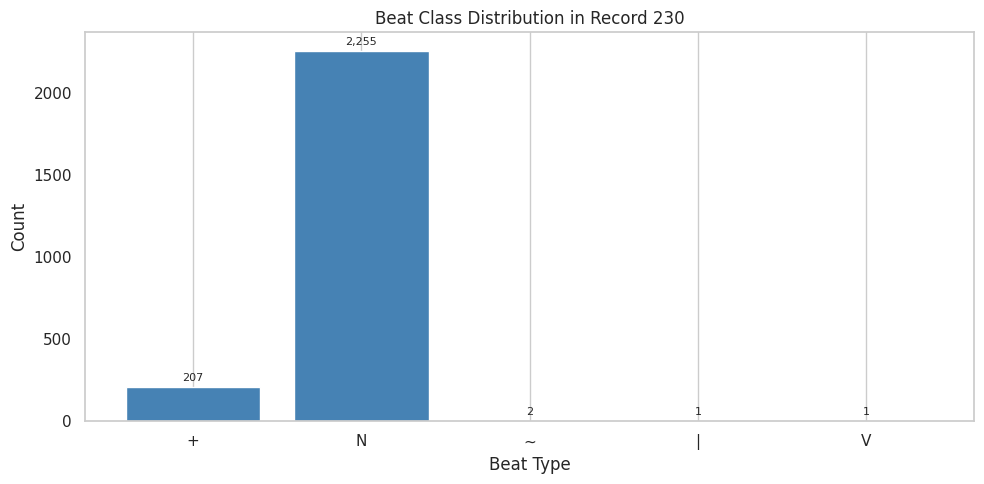

Record: 231
--------------------------------------------------------------------------------
Total number of annotations: 2011

R-peak classes (symbols):
+, R, R, R, R, R, R, ", R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, ", N, R, +, ", N, ", N, ", N, ", N, ", N, ", N, ", N, ", N, ", N, "
N, ", N, ", R, ", R, ", R, ", R, ", R, ", R, ", R, ", R, ", R, ", R, ", R
", R, ", R, ", R, ", R, ", R, ", R, ", R, x, A, R, x, V, V, +, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R, R
R, R, R, R, R, R, R, R, R, R, R,

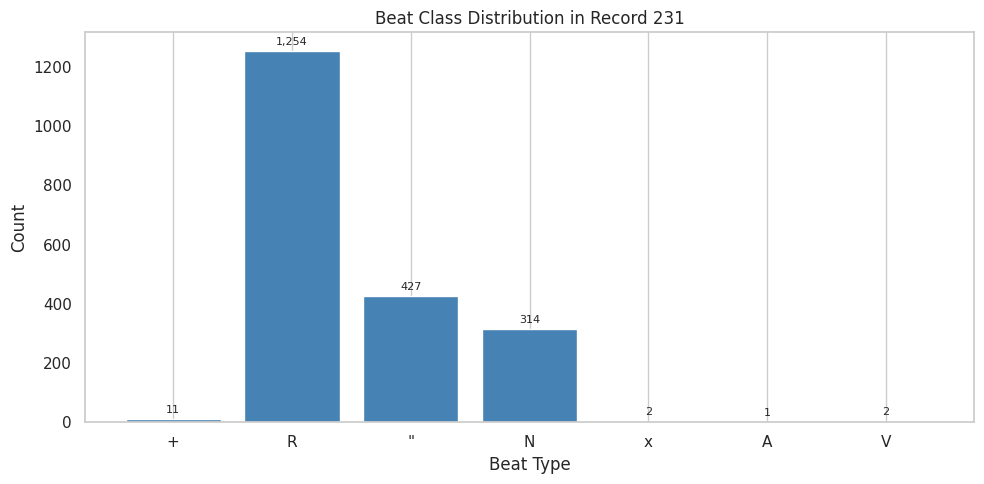

Record: 232
--------------------------------------------------------------------------------
Total number of annotations: 1816

R-peak classes (symbols):
+, R, A, A, R, A, A, ~, R, A, R, A, R, A, R, A, A, R, A, A, A, A, A, A, A
R, R, R, A, A, R, A, A, A, A, A, A, A, A, A, A, A, R, R, A, A, R, A, A, A
R, R, A, A, A, A, A, R, R, A, A, R, A, A, R, A, A, A, R, ~, R, R, A, A, A
A, A, A, A, A, A, A, R, ~, A, A, A, R, A, A, ~, R, A, A, A, A, A, R, A, A
R, A, A, A, R, A, A, R, A, A, A, R, A, A, R, A, A, R, A, A, R, A, A, R, A
A, A, A, A, R, A, A, A, A, A, A, A, A, A, A, R, R, A, A, A, A, R, A, A, R
A, A, R, A, A, R, A, A, R, A, A, A, A, A, R, R, A, A, R, A, A, A, A, A, R
A, R, A, R, A, R, A, A, R, A, A, R, A, A, R, A, R, A, A, R, A, A, A, R, A
R, A, A, A, A, R, R, A, A, R, A, A, R, A, A, R, A, A, A, A, A, R, A, A, ~
A, A, A, A, A, A, A, A, A, A, A, A, A, R, A, A, A, A, R, ~, R, A, A, A, A
A, A, A, A, R, A, A, R, A, R, A, A, A, A, R, A, A, R, A, A, A, A, A, ~, R
A, R, A, A, A, ~, A, ~, R, A, A,

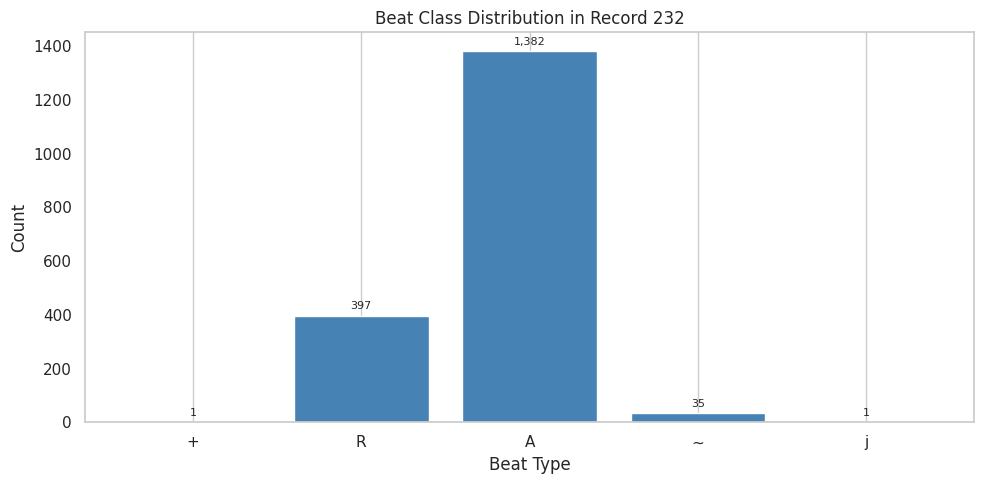

Record: 233
--------------------------------------------------------------------------------
Total number of annotations: 3152

R-peak classes (symbols):
+, V, N, V, N, N, V, N, V, N, N, V, N, N, N, V, N, N, N, N, N, N, V, N, V
N, N, A, V, N, N, N, N, N, N, N, A, N, N, V, N, N, N, V, N, N, N, N, +, V
V, V, +, N, V, N, N, V, N, V, N, N, V, N, V, N, N, N, V, N, N, V, N, V, N
N, N, V, V, N, V, N, N, N, N, N, V, N, N, N, V, N, N, N, N, N, V, N, N, N
V, N, N, V, N, N, N, N, N, N, V, N, V, N, N, V, N, V, N, N, N, N, N, V, N
N, V, N, V, N, N, V, N, N, N, V, N, N, N, +, V, N, N, V, N, N, V, +, N, N
N, N, N, N, N, N, N, N, N, V, N, N, N, N, N, V, N, N, N, V, N, N, N, N, N
V, N, N, N, N, N, N, N, V, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, V
N, N, N, N, N, N, N, V, N, N, N, N, V, N, V, N, N, V, N, V, N, N, +, V, N
V, N, V, N, V, +, N, N, V, N, A, N, N, +, V, N, V, N, V, N, V, +, N, N, N
V, N, N, +, V, N, V, N, V, N, V, +, N, N, +, V, N, V, N, V, N, V, V, N, V
+, N, N, V, N, V, N, N, +, V, N,

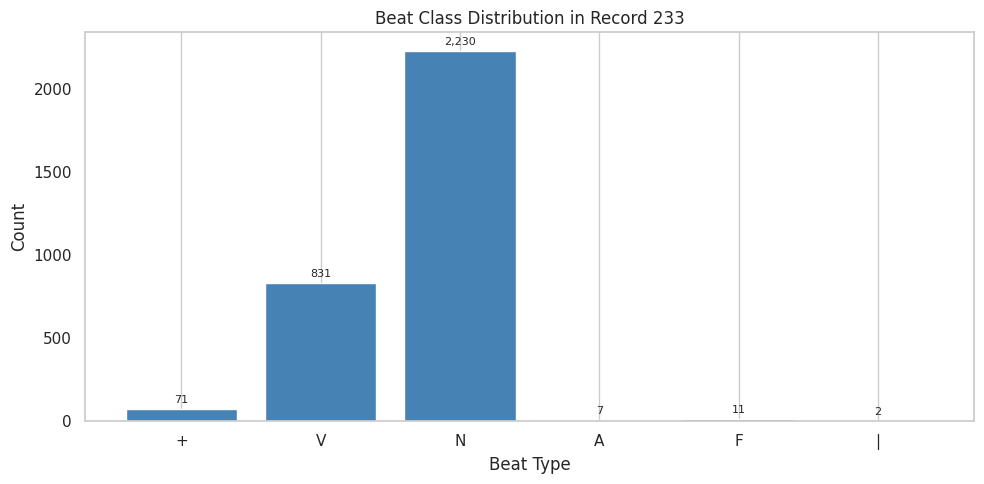

Record: 234
--------------------------------------------------------------------------------
Total number of annotations: 2764

R-peak classes (symbols):
+, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N, N
N, N, N, N, N, N, N, N, N, N, N,

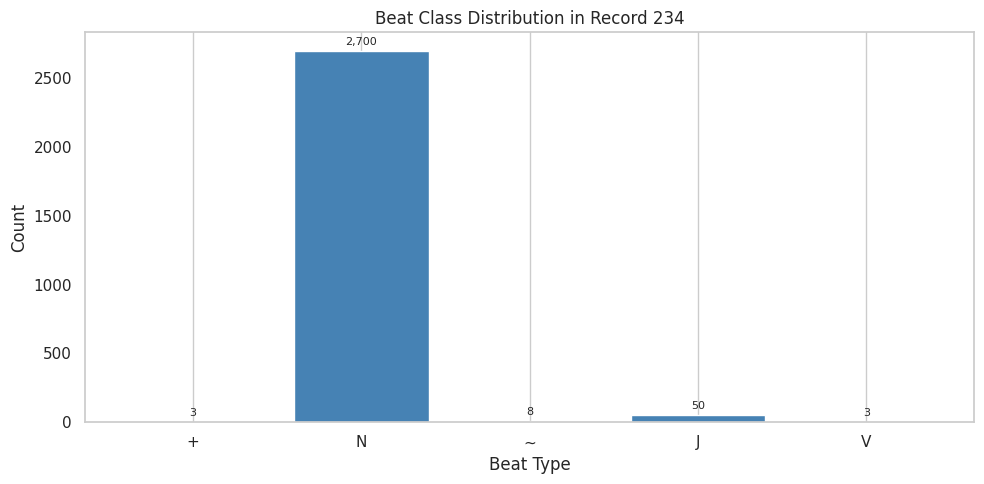

In [ ]:
import wfdb
import matplotlib.pyplot as plt
from collections import Counter
import textwrap

# Path to MIT-BIH dataset
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"

# List of MIT-BIH record numbers
records = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
    111, 112, 113, 114, 115, 116, 117, 118, 119,
    121, 122, 123, 124, 200, 201, 202, 203, 205,
    207, 208, 209, 210, 212, 213, 214, 215, 217,
    219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234
]

# Function to print symbols in a grid layout
def print_in_grid(symbols, cols=20):
    for i in range(0, len(symbols), cols):
        print(", ".join(symbols[i:i+cols]))

# Loop through each record
for record in records:
    try:
        annotation = wfdb.rdann(f"{project_path}{record}", 'atr')
        Rlocation = annotation.sample
        Rclass = annotation.symbol

        # Print info
        print("="*80)
        print(f"Record: {record}")
        print("-"*80)
        print(f"Total number of annotations: {len(Rclass)}\n")
        print("R-peak classes (symbols):")
        print_in_grid(Rclass, cols=25)
        print("\nR-peak locations (first 20 sample indices):")
        print(", ".join(map(str, Rlocation[:20])) + (" ..." if len(Rlocation) > 20 else ""))
        print("="*80 + "\n")

        # Count beats
        beat_counts = Counter(Rclass)

        # Plot beat distribution
        plt.figure(figsize=(10, 5))
        bars = plt.bar(beat_counts.keys(), beat_counts.values(), color="steelblue")
        plt.title(f"Beat Class Distribution in Record {record}")
        plt.xlabel("Beat Type")
        plt.ylabel("Count")
        plt.grid(axis="y")

        # Annotate counts on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.annotate(f'{int(height):,}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),
                         textcoords='offset points',
                         ha='center', va='bottom',
                         fontsize=8)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("="*80)
        print(f"Record: {record} - Error reading annotation: {e}")
        print("="*80 + "\n")

In [ ]:
import wfdb
import pandas as pd
from collections import Counter
# Path to MIT-BIH dataset folder
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# MIT-BIH record list
records = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
    111, 112, 113, 114, 115, 116, 117, 118, 119,
    121, 122, 123, 124, 200, 201, 202, 203, 205,
    207, 208, 209, 210, 212, 213, 214, 215, 217,
    219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234
]
# Initialize storage for statistics
record_summary = []
global_counts = Counter()
print("\n========== ARRHYTHMIA ANNOTATION STATISTICS ==========\n")
# Loop through all records
for record in records:
    try:
        # Load annotation file
        annotation = wfdb.rdann(f"{project_path}{record}", 'atr')
        Rclass = annotation.symbol
        Rlocation = annotation.sample
        # Count annotation types in the record
        class_counts = Counter(Rclass)
        total_ann = len(Rclass)
        # Update global counts
        global_counts.update(class_counts)
        # Store summary per record
        record_summary.append({
            "Record": record,
            "Total_Annotations": total_ann,
            "Unique_Classes": len(class_counts),
            "Most_Common_Class": class_counts.most_common(1)[0][0],
            "Most_Common_Count": class_counts.most_common(1)[0][1],
            "Annotation_Distribution": dict(class_counts)
        })
        # Display concise summary per record
        print(f"Record {record}: Total={total_ann}, Classes={len(class_counts)}, Most Common={class_counts.most_common(1)}")
    except Exception as e:
        print(f"⚠️ Error reading record {record}: {e}")
# Convert record summary to DataFrame
df_summary = pd.DataFrame(record_summary)
# Display table of per-record summaries
print("\n\n========== PER-RECORD SUMMARY ==========\n")
print(df_summary[["Record", "Total_Annotations", "Unique_Classes", "Most_Common_Class", "Most_Common_Count"]])
# Global annotation statistics
print("\n\n========== GLOBAL CLASS DISTRIBUTION ==========\n")
for cls, count in global_counts.most_common():
    print(f"{cls:>3} : {count}")
# Save results to CSV (optional)
output_path = "/content/arrhythmia_annotation_summary.csv"
df_summary.to_csv(output_path, index=False)
print(f"\n✅ Summary saved to {output_path}")


========== ARRHYTHMIA ANNOTATION STATISTICS ==========

Record 100: Total=2274, Classes=4, Most Common=[('N', 2239)]
Record 101: Total=1874, Classes=6, Most Common=[('N', 1860)]
Record 102: Total=2192, Classes=5, Most Common=[('/', 2028)]
Record 103: Total=2091, Classes=4, Most Common=[('N', 2082)]
Record 104: Total=2311, Classes=7, Most Common=[('/', 1380)]
Record 105: Total=2691, Classes=6, Most Common=[('N', 2526)]
Record 106: Total=2098, Classes=4, Most Common=[('N', 1507)]
Record 107: Total=2140, Classes=4, Most Common=[('/', 2078)]
Record 108: Total=1824, Classes=9, Most Common=[('N', 1739)]
Record 109: Total=2535, Classes=5, Most Common=[('L', 2492)]
Record 111: Total=2133, Classes=4, Most Common=[('L', 2123)]
Record 112: Total=2550, Classes=4, Most Common=[('N', 2537)]
Record 113: Total=1796, Classes=3, Most Common=[('N', 1789)]
Record 114: Total=1890, Classes=8, Most Common=[('N', 1820)]
Record 115: Total=1962, Classes=4, Most Common=[('N', 1953)]
Record 116: Total=2421, Clas

In [ ]:
# For exmaple, we extract '100' recording annotation
annotation = wfdb.rdann(project_path + '100', 'atr')
Rlocation = annotation.sample
print(Rlocation)
Rclass = annotation.symbol
print(Rclass)

[    18     77    370 ... 649484 649734 649991]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '

In [ ]:
len(annotation.symbol)

2274

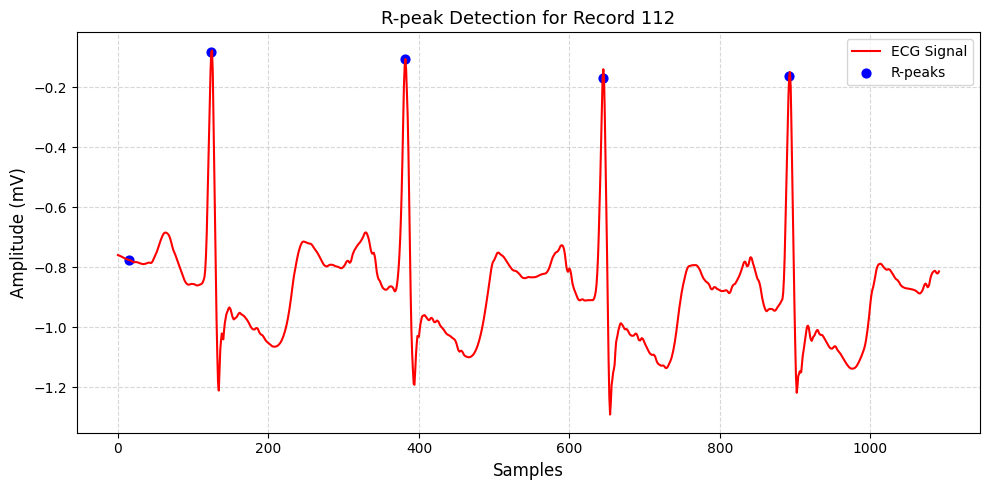

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
# Example record (you can change this)
record = '112'
project_path = r"/content/drive/MyDrive/PhD Dataset/mit-bih-arrhythmia-database-1.0.0/"
# Load ECG data and annotation
record_data = wfdb.rdrecord(project_path + record)
annotation = wfdb.rdann(project_path + record, 'atr')
# Extract signal and annotation info
rdata = denoise(data=data)                   # ECG signal (first channel)
Rlocation = annotation.sample           # R-peak sample indices
# Number of R-peaks to show (e.g., first 5)
n_peak = 5
r_peak_x = Rlocation[:n_peak]
r_peak_y = rdata[Rlocation[:n_peak]]
# Select a segment for plotting (zoomed around first few peaks)
start = Rlocation[0] - 100 if Rlocation[0] > 100 else 0
end = Rlocation[n_peak - 1] + 200
x = np.arange(start, end)
segment = rdata[start:end]
# Plot ECG with R-peaks
plt.figure(figsize=(10, 5))
plt.plot(x, segment, color='red', linewidth=1.5, label='ECG Signal')
plt.scatter(r_peak_x, r_peak_y, color='blue', s=40, label='R-peaks')
plt.title(f"R-peak Detection for Record {record}", fontsize=13)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Amplitude (mV)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **B3: Segmentation**
Each ECG signal is segmented by using a window **length of 300**. From R-peak location, **99** samples taken from **left** and **201** samples from **right**. Thus a complete **heartbeat** is found.

(300,)
(300,)
(300,)


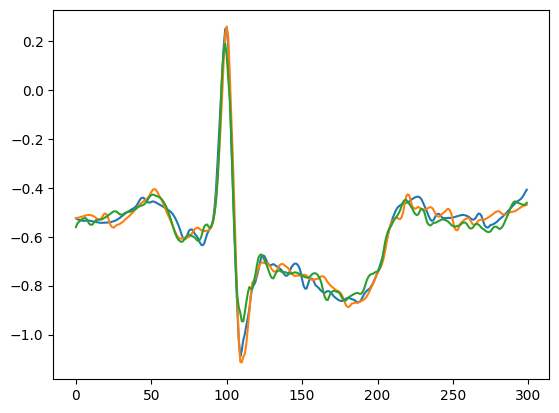

In [ ]:
# Plotting 3 heartbeats
k = np.arange(100, 103)
for i in k:
  # print(i)
  # print(Rlocation[i] - 99, Rlocation[i] + 201)
  x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
  plt.plot(x_train)
  print(x_train.shape)
plt.show()

### **B4: Complete Preprocessing Figures**
The complete preprocessing including denosinsing, R-peak location detection and segmentation is expected to view in a single figure.

In [ ]:
r_peak_xx = Rlocation[0], Rlocation[1], Rlocation[2], Rlocation[3]
r_peak_yy = rdata[Rlocation[0]], rdata[Rlocation[1]], rdata[Rlocation[2]], rdata[Rlocation[3]]

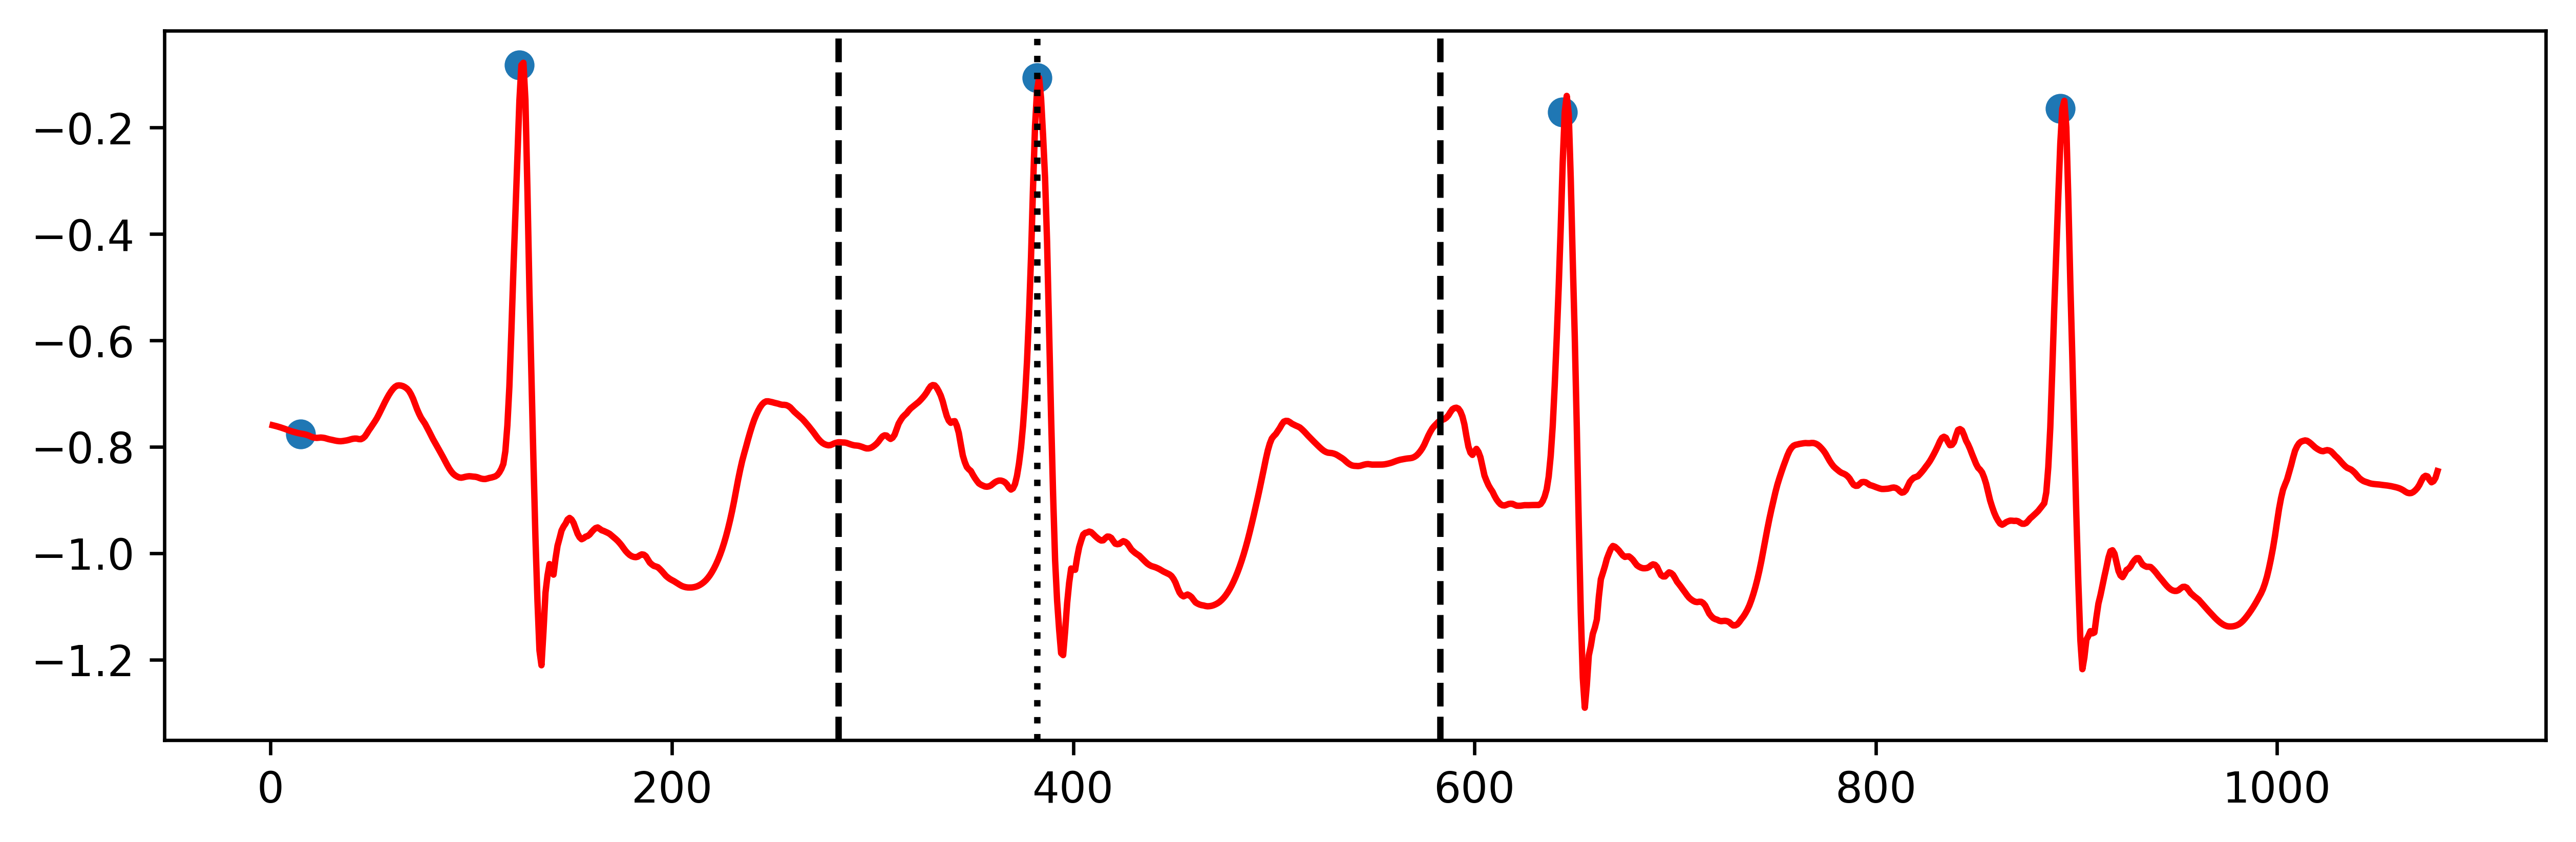

In [ ]:
# Plotting R-peaks and segmentation lines
fig = plt.figure(figsize=(10,3), dpi=600)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':')
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

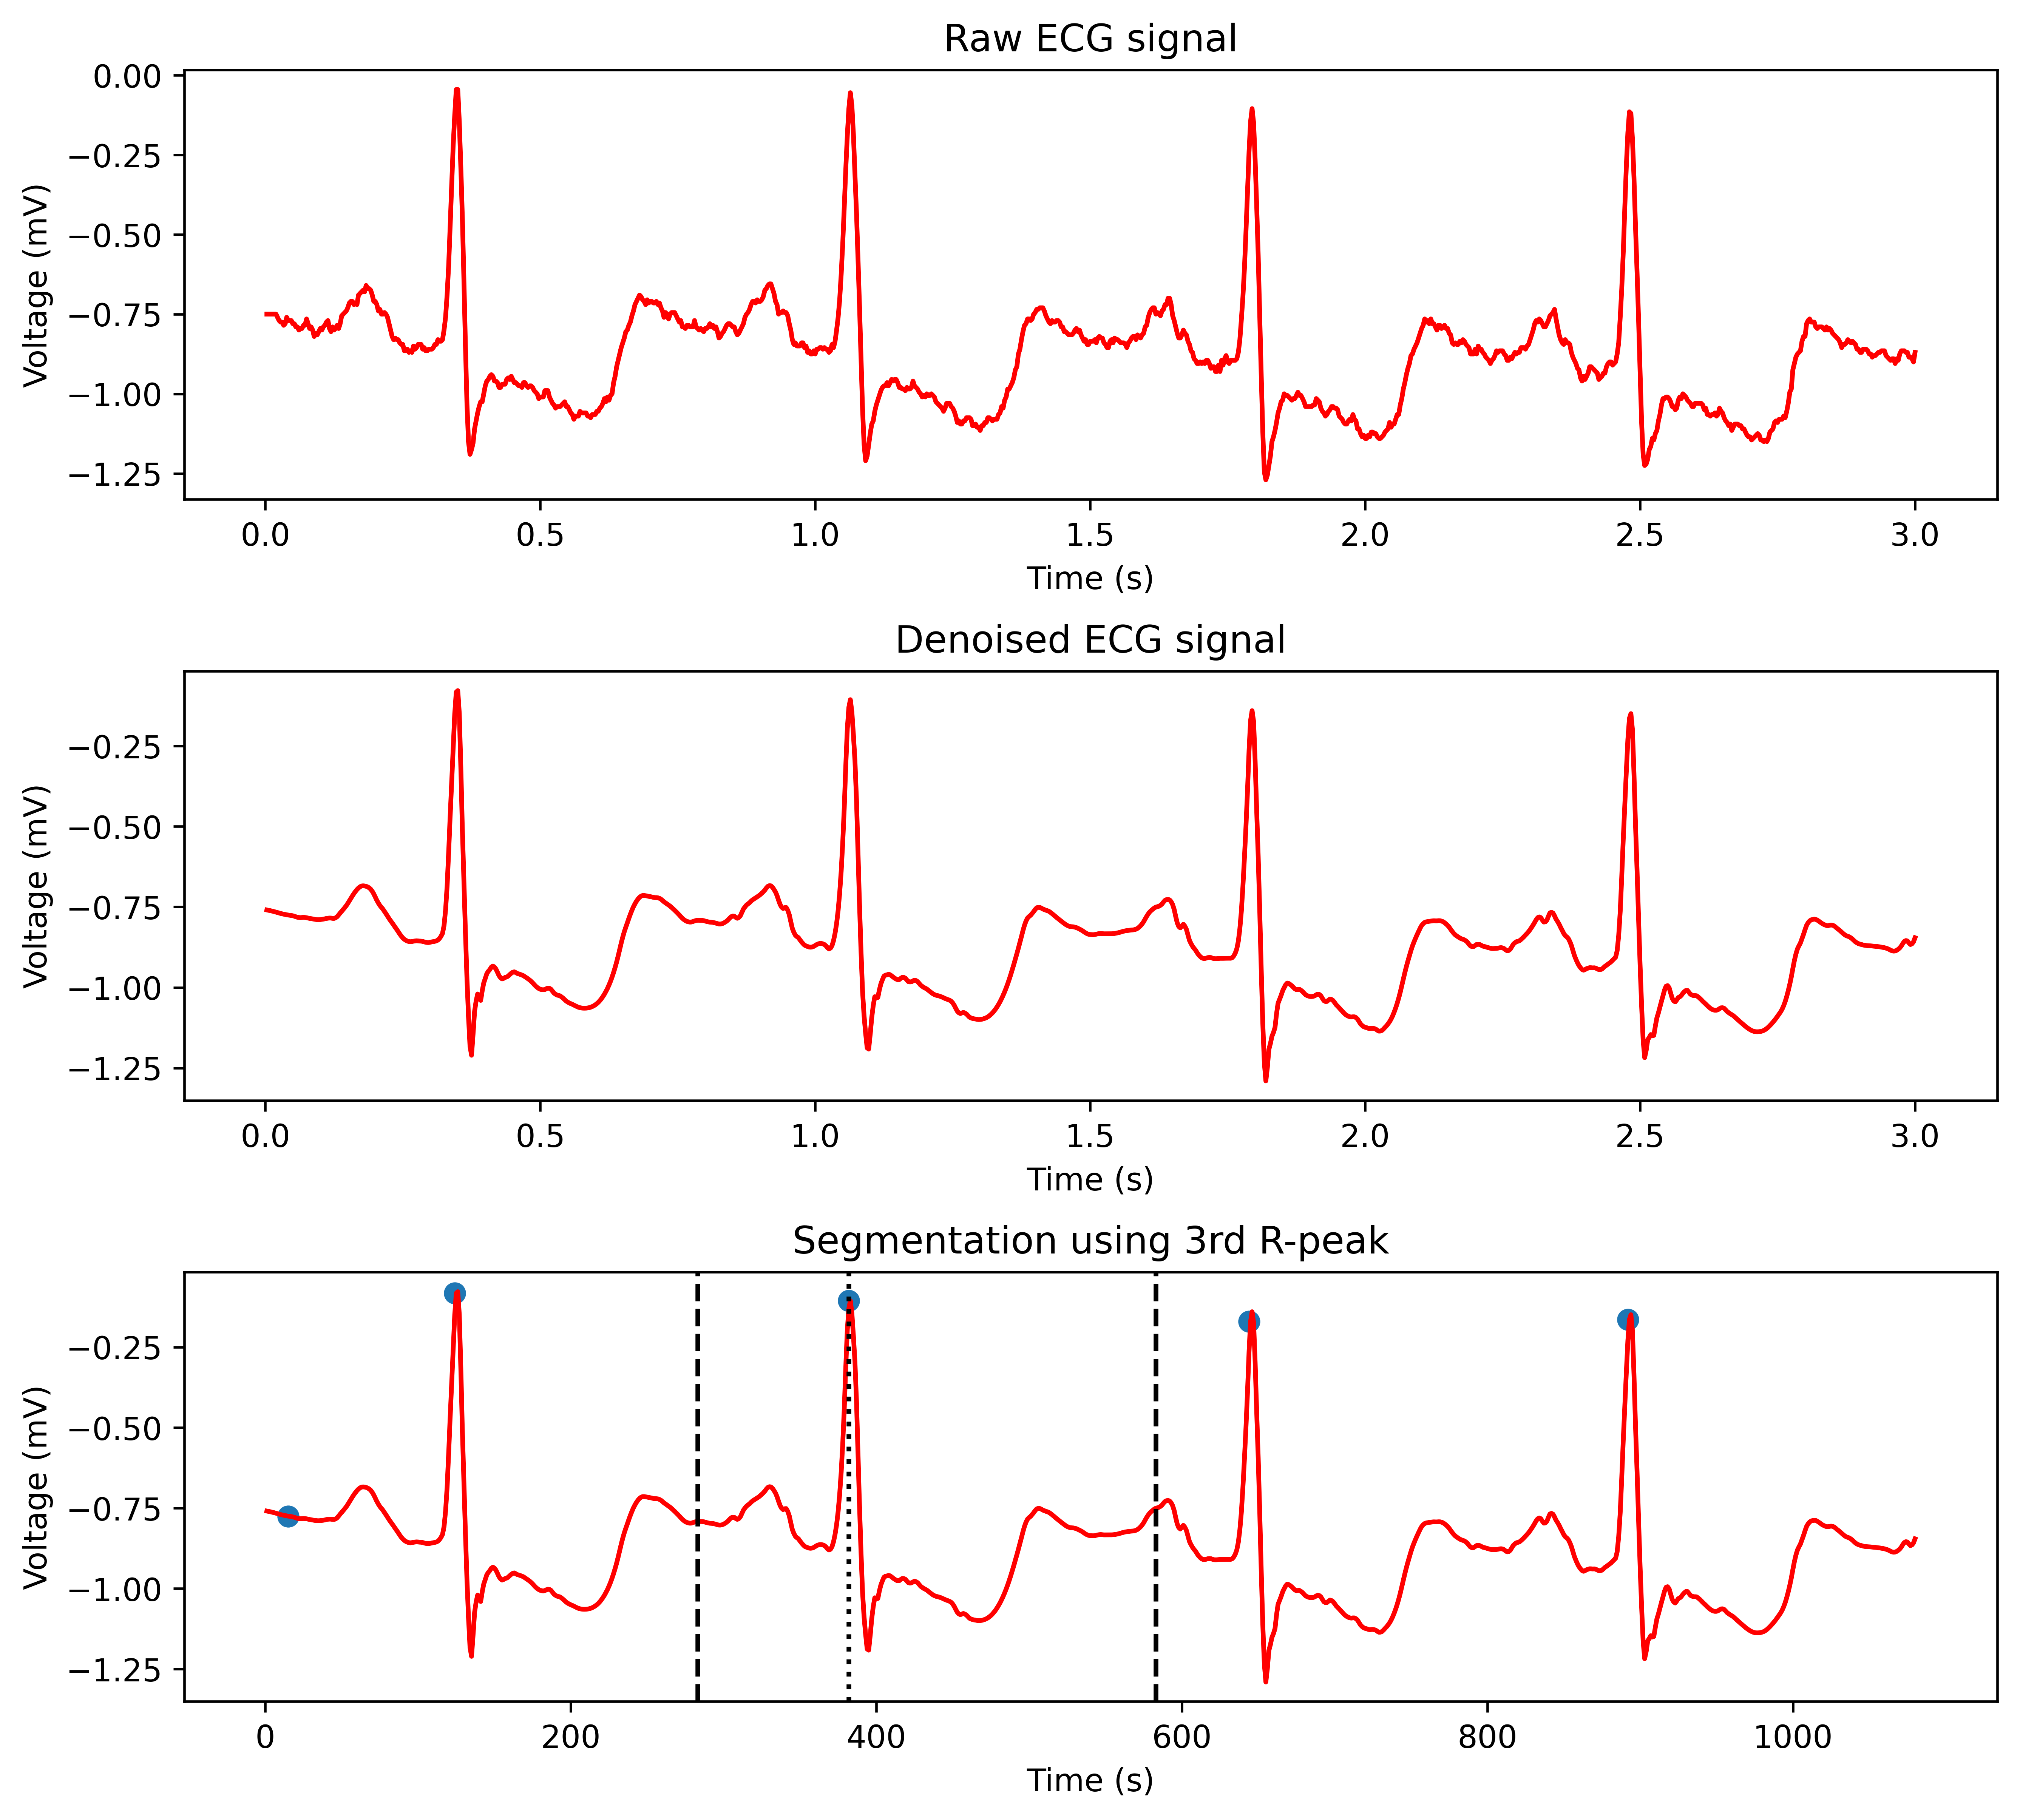

In [ ]:
# Plot together raw, denoised and segmted signal
fig = plt.figure(figsize=(10,9), dpi=600)
x = np.arange(1, 1081)

# Raw signal plotting
plt.subplot(3, 1, 1)
plt.plot(x/360, data[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Raw ECG signal')

# Denoised signal plotting
plt.subplot(3, 1, 2)
plt.plot(x/360, rdata[0:1080], color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Denoised ECG signal')

# Segmentation visualization using two border lines
plt.subplot(3, 1, 3)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(Rlocation[i])
  r_peak_y.append(rdata[Rlocation[i]])
x = np.arange(1, 1081)
plt.plot(x, rdata[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
# line plotting
plt.axvline(x = Rlocation[2], color = 'k', linestyle = ':') # 3rd r-peak
plt.axvline(x = Rlocation[2]-99, color = 'k', linestyle = '--')
plt.axvline(x = Rlocation[2]+201, color = 'k', linestyle = '--')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Segmentation using 3rd R-peak')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)

#figure_path = '/content/gdrive/MyDrive/ECG Arrhythmia trying/Heartbeat_Figures/'
#fig.savefig(figure_path+ 'Denoised and segmented ECG.png')

# **Part C: Dataset Loading**

## **C1: Loading whole data**

In [145]:
# Read ECG signals and corresponding label
def getDataSet(number, X_data, Y_data):

    # Considering 15 types ECG heartbeats that are later grouped in 5 classes
    ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q']

    # Reading Channel names
    _, info = wfdb.io.rdsamp(osj(project_path, number))
    channels = info['sig_name']
    channel1, channel2 = channels[0], channels[1]
    print(channel1, channel2)


    # Read ECG data records
    print("reading " + number+ " ECG data...")
    record = wfdb.rdrecord(project_path + number, channel_names=[channel1])
    data = record.p_signal.flatten()
    rdata = denoise(data=data)

    # Obtain the position and corresponding label of the R wave in the ECG data record
    annotation = wfdb.rdann(project_path + number, 'atr')
    Rlocation = annotation.sample
    Rclass = annotation.symbol

    # Unstable data before and after removal
    start = 2  # if it creates problem then except will do the job
    end = 3
    i = start
    j = len(annotation.symbol) - end

    # Making labels, Y_data Convert NSVFQ in order to 0123456...14
    while i < j:
        try:
            beat_type = Rclass[i]
            lable = ecgClassSet.index(beat_type)  # when beat is like '+' or other it will go on except loop
            x_train = rdata[Rlocation[i] - 99:Rlocation[i] + 201]
            X_data.append(x_train)
            Y_data.append(lable)
            i += 1
        except ValueError:
            # print(f' when i = {i}, beat type is out of our choise. For example +, [, ! or other')
            i += 1
    return X_data, Y_data

In [146]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)

    # dataset and its label set
    X = train_ds[:, :300]
    Y = train_ds[:, 300]
    return X, Y

In [147]:
# Input X and Output Y data loading
X, Y = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [148]:
from collections import Counter
# Assuming Y is your list/array of heartbeat classes
Y_list = list(Y)
count_dict = Counter(Y_list)
print(count_dict)

Counter({np.float64(0.0): 74920, np.float64(1.0): 8063, np.float64(2.0): 7244, np.float64(9.0): 7123, np.float64(12.0): 7012, np.float64(5.0): 2540, np.float64(13.0): 982, np.float64(11.0): 802, np.float64(4.0): 229, np.float64(6.0): 150, np.float64(10.0): 106, np.float64(7.0): 83, np.float64(14.0): 33, np.float64(3.0): 16, np.float64(8.0): 2})


## **C2: Ploting 15 Different Heartbeats**

In [149]:
# Before renaming and joining
print("Before renaming and joining:")
print("df_Y columns:", df_Y.columns.tolist())
print("df_X shape:", df_X.shape)
print("df_Y shape:", df_Y.shape)

# Display first few rows
print("\nSample df_Y before rename:")
print(df_Y.head())
print("\nSample df_X before join:")
print(df_X.head())

# Perform rename and join
df_Y.rename(columns={0: 300}, inplace=True)
df = pd.concat([df_X, df_Y], axis=1)

# After renaming and joining
print("\nAfter renaming and joining:")
print("df_Y columns:", df_Y.columns.tolist())
print("Combined df shape:", df.shape)

# Display first few rows after join
print("\nSample df after join:")
print(df.head())

Before renaming and joining:
df_Y columns: [300]
df_X shape: (109305, 300)
df_Y shape: (109305, 1)

Sample df_Y before rename:
    300
0   0.0
1   0.0
2  11.0
3  12.0
4   9.0

Sample df_X before join:
        0         1         2         3         4         5         6    \
0 -0.231830 -0.227509 -0.224017 -0.221125 -0.218474 -0.215692 -0.212382   
1 -0.465439 -0.468932 -0.471235 -0.473122 -0.474420 -0.475535 -0.477061   
2 -0.061039 -0.078442 -0.093250 -0.104936 -0.115189 -0.124743 -0.133298   
3 -0.136527 -0.139488 -0.142408 -0.145149 -0.147732 -0.150032 -0.152322   
4 -0.265732 -0.266227 -0.266745 -0.267255 -0.267746 -0.268206 -0.268614   

        7         8         9    ...       290       291       292       293  \
0 -0.209609 -0.208064 -0.207203  ... -0.133778 -0.133277 -0.131828 -0.130640   
1 -0.478469 -0.479756 -0.481141  ... -0.324071 -0.318316 -0.312761 -0.308200   
2 -0.141462 -0.147396 -0.149724  ... -0.641584 -0.668588 -0.691393 -0.706922   
3 -0.154796 -0.157256 -0.159

In [150]:
# making pandas dataframe
df_X = pd.DataFrame(X)
df_Y = pd.DataFrame(Y)

In [151]:
# changing the name from 0 to 300
df_Y.rename(columns = {0:300}, inplace = True)
# join X and Y
df = pd.concat([df_X, df_Y], axis=1)

In [152]:
def Plot_Random_Beat(type, num):

  ecgClassSet = ['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', 'slash', 'f', 'Q']

  ecgClassName = ['Normal (N)', 'Left bundle br. bl. (L)', 'Right bundle br. bl. (R)',
                  'Atrial escape (e)', 'Nodal jun. esc. (j)', 'Atrial premature (A)',
                  'Aberrated atrial prem. (a)', 'Nodal jun. pre. (J)',
                  'Supraventricular prem. (S)', 'Premature ventr. (V)',
                  'Ventricular escape (E)', 'Fusion of ve. & no. (F)',
                  'Paced (/)', 'Fusion of pa. & no. (f)',
                  'Unclassifiable(Q)']

  # getting only a specific class ECG signal
  df_0 = df.loc[df[300]==type]  # For normanl class: 0, shape is 74920,301
  df_0 = df_0.drop(columns=[300]) # changing the shape to 74920,300

  # selecting some random row to plot
  if num<=df_0.shape[0]:
    np.random.seed(234)
    random_beat_number = np.random.randint(df_0.shape[0], size=(num))
    random_beat_number = list(random_beat_number)
  else: # Needed for Supraventricular Premature Beat (S) only, as it contains only 2 beats
    print(f"Warning: You have only {df_0.shape[0]} beat, but asked to plot {num}")
    random_beat_number = np.arange(0, df_0.shape[0])
    random_beat_number = list(random_beat_number)

  # ploting the ECG signal
  for i in random_beat_number:
    ecg_beat = df_0.iloc[i]
    plt.plot(ecg_beat)
  plt.title(str(ecgClassName[type]))

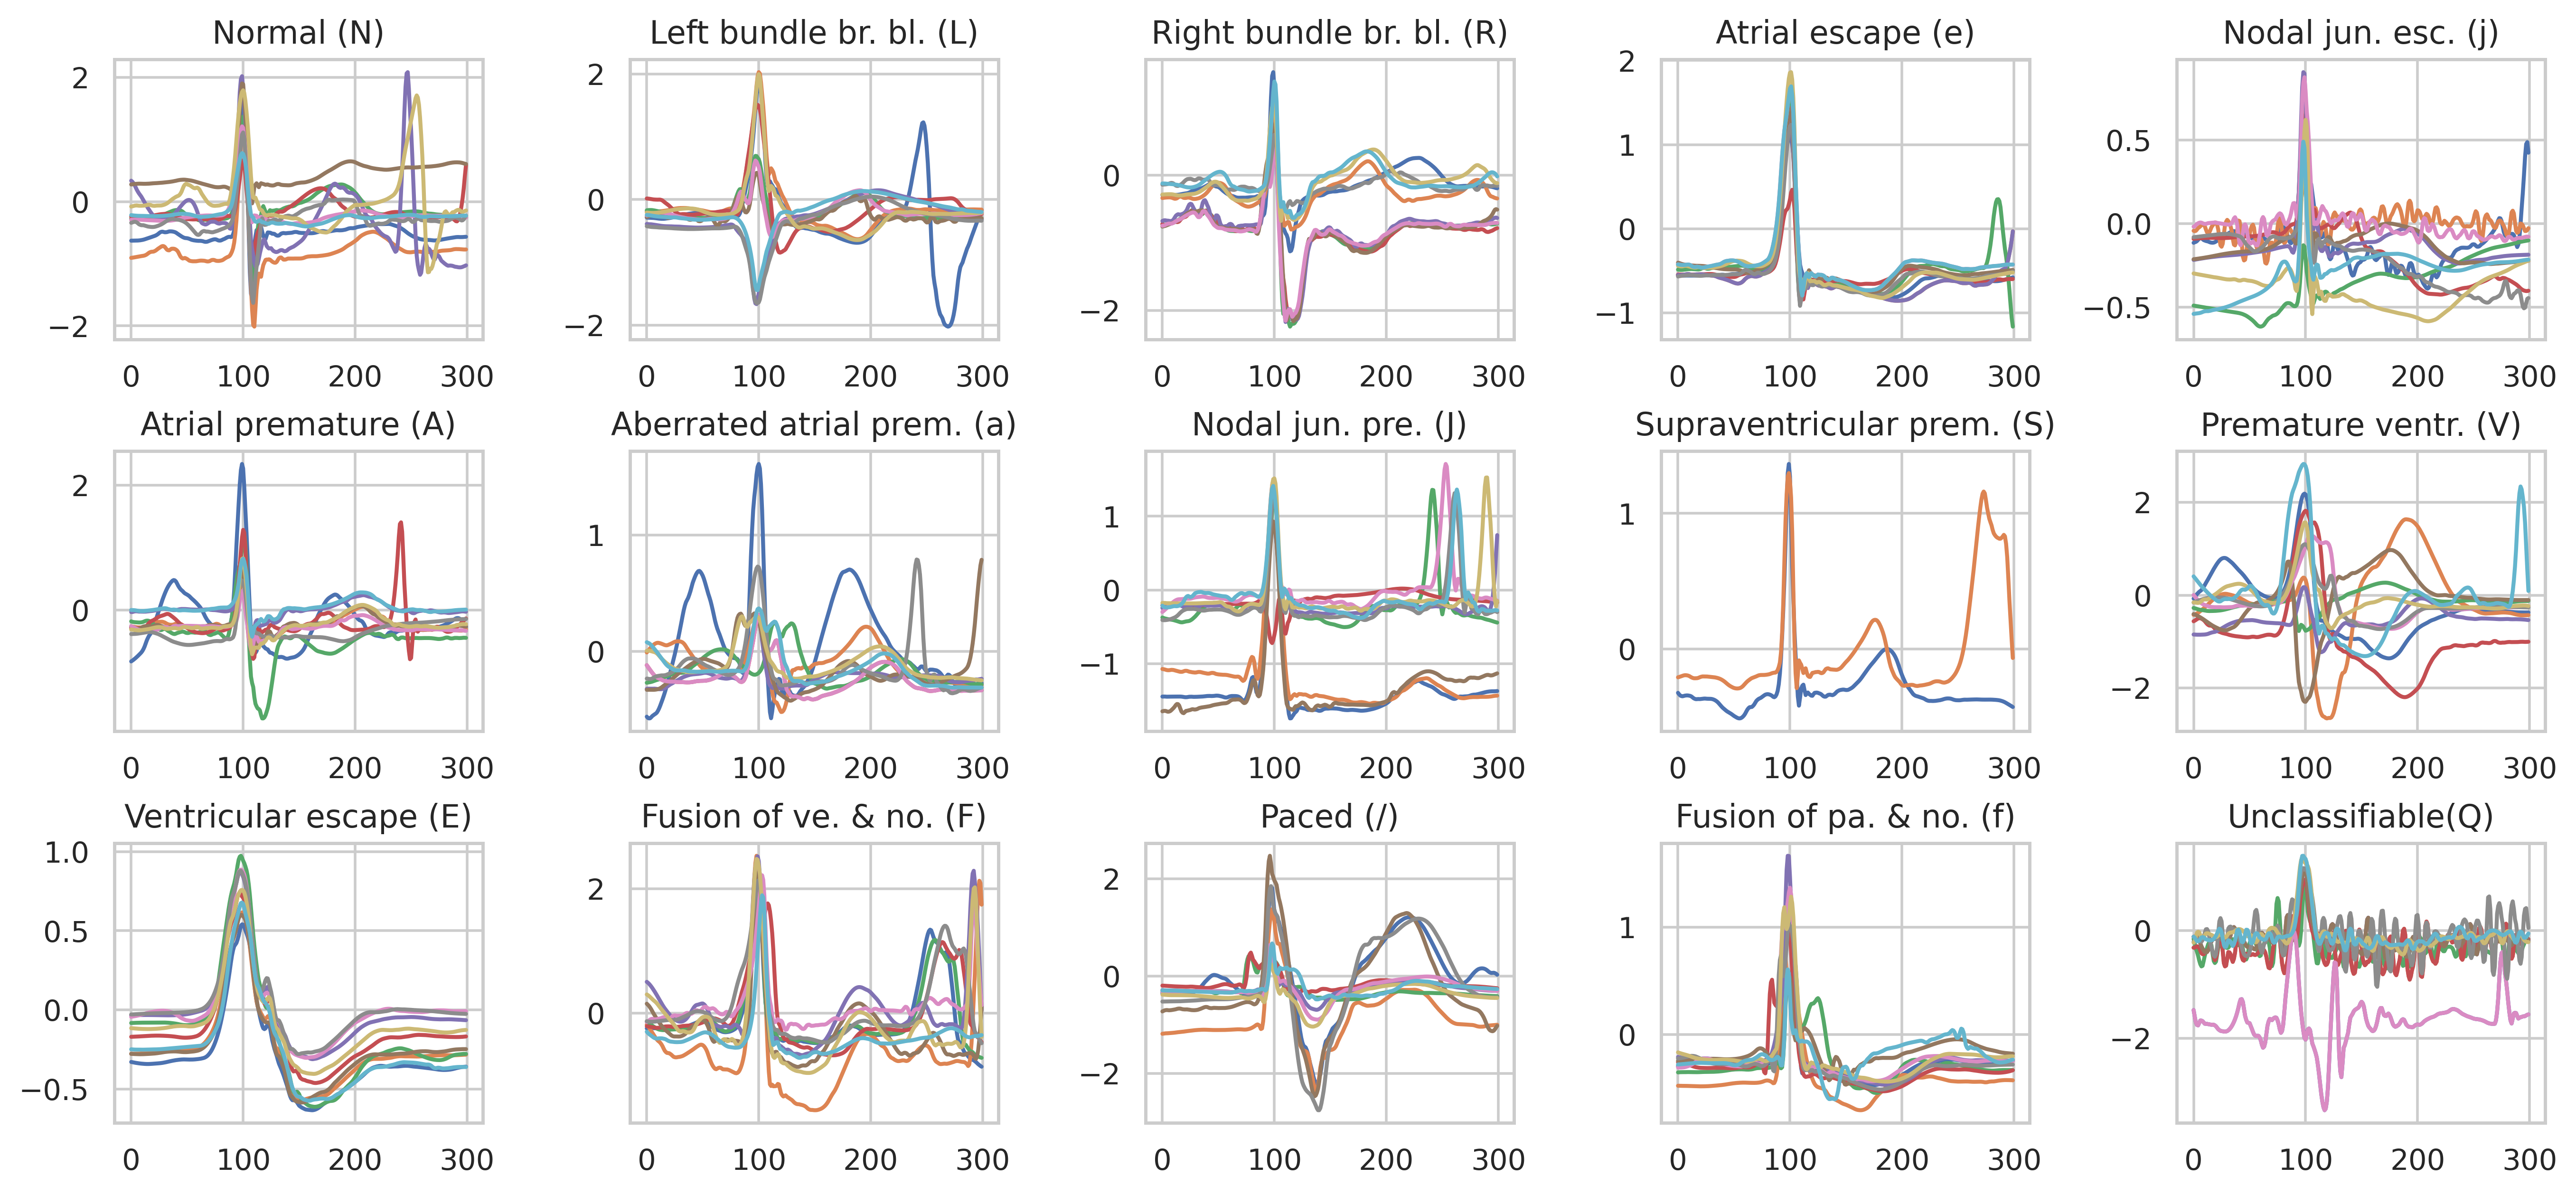

In [153]:
# Plotting 15 different types of heartbeat
fig = plt.figure(figsize=(16,7), dpi=400)
fig.tight_layout(pad=15.0)
for i in range(15):
  plt.subplot(3,5,i+1)
  plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
  Plot_Random_Beat(type=i, num=10)
#figure_path = '/content/gdrive/MyDrive/ECG Arrhythmia trying/Heartbeat_Figures/'
#fig.savefig(figure_path+ 'all_heartbeats.png')

# **Part D: Train-Test Splitting and Class Balancing**

## **D1: Data loading**
Data is already loaded, **this step can be skipped.** However, here the whole dataset is saved in a train_ds variable.

### **a. Load whole data**

In [154]:
# Load the dataset and preprocess it
def loadData():
    numberSet = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                 '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                 '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
                 '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
                 '222', '223', '228', '230', '231', '232', '233', '234']  # 48 readings
    dataSet = []
    lableSet = []
    for n in numberSet:
        # getDataSet(n, dataSet, lableSet)
        dataSet, lableSet = getDataSet(n, dataSet, lableSet)

    # Turn numpy array, scramble the order
    dataSet = np.array(dataSet).reshape(-1, 300)
    lableSet = np.array(lableSet).reshape(-1, 1)
    train_ds = np.hstack((dataSet, lableSet))
    np.random.shuffle(train_ds)
    return train_ds

In [155]:
# Load the whole dataset (109305,301). Each row indicate an ECG beat time series data upto 300
# and 301 column is its label among 15 difference level
train_ds = loadData()

MLII V5
reading 100 ECG data...
MLII V1
reading 101 ECG data...
V5 V2
reading 102 ECG data...
MLII V2
reading 103 ECG data...
V5 V2
reading 104 ECG data...
MLII V1
reading 105 ECG data...
MLII V1
reading 106 ECG data...
MLII V1
reading 107 ECG data...
MLII V1
reading 108 ECG data...
MLII V1
reading 109 ECG data...
MLII V1
reading 111 ECG data...
MLII V1
reading 112 ECG data...
MLII V1
reading 113 ECG data...
V5 MLII
reading 114 ECG data...
MLII V1
reading 115 ECG data...
MLII V1
reading 116 ECG data...
MLII V2
reading 117 ECG data...
MLII V1
reading 118 ECG data...
MLII V1
reading 119 ECG data...
MLII V1
reading 121 ECG data...
MLII V1
reading 122 ECG data...
MLII V5
reading 123 ECG data...
MLII V4
reading 124 ECG data...
MLII V1
reading 200 ECG data...
MLII V1
reading 201 ECG data...
MLII V1
reading 202 ECG data...
MLII V1
reading 203 ECG data...
MLII V1
reading 205 ECG data...
MLII V1
reading 207 ECG data...
MLII V1
reading 208 ECG data...
MLII V1
reading 209 ECG data...
MLII V1
read

In [156]:
Y = train_ds[:, 300]

In [157]:
# Here 15 class of ECG data are saved
Y_list = list(Y)
Counter(Y_list)

Counter({np.float64(2.0): 7244,
         np.float64(0.0): 74920,
         np.float64(13.0): 982,
         np.float64(12.0): 7012,
         np.float64(9.0): 7123,
         np.float64(1.0): 8063,
         np.float64(5.0): 2540,
         np.float64(11.0): 802,
         np.float64(6.0): 150,
         np.float64(10.0): 106,
         np.float64(4.0): 229,
         np.float64(3.0): 16,
         np.float64(7.0): 83,
         np.float64(14.0): 33,
         np.float64(8.0): 2})

In [158]:
from collections import Counter
import numpy as np

# Convert Y to list
Y_list = list(Y)

# Count occurrences
count_dict = Counter(Y_list)

# Sort the counter by key (class label)
sorted_counts = dict(sorted(count_dict.items(), key=lambda x: x[0]))

# Display in order
for k, v in sorted_counts.items():
    print(f"Class {int(k)}: {v}")

Class 0: 74920
Class 1: 8063
Class 2: 7244
Class 3: 16
Class 4: 229
Class 5: 2540
Class 6: 150
Class 7: 83
Class 8: 2
Class 9: 7123
Class 10: 106
Class 11: 802
Class 12: 7012
Class 13: 982
Class 14: 33


### **b. 15 types to 5 level conversion**

In [159]:
# 15 level to 5 level conversion
Y_5class = np.copy(Y)

for i in range(Y.shape[0]):
  # print(i)
  if 0 <= Y[i] <= 4:
    Y_5class[i] = 0
  if 5 <= Y[i] <= 8:
    Y_5class[i] = 1
  if 9 <= Y[i] <= 10:
    Y_5class[i] = 2
  if Y[i] == 11:
    Y_5class[i] = 3
  if 12 <= Y[i] <= 14:
    Y_5class[i] = 4
print('changing done')

changing done


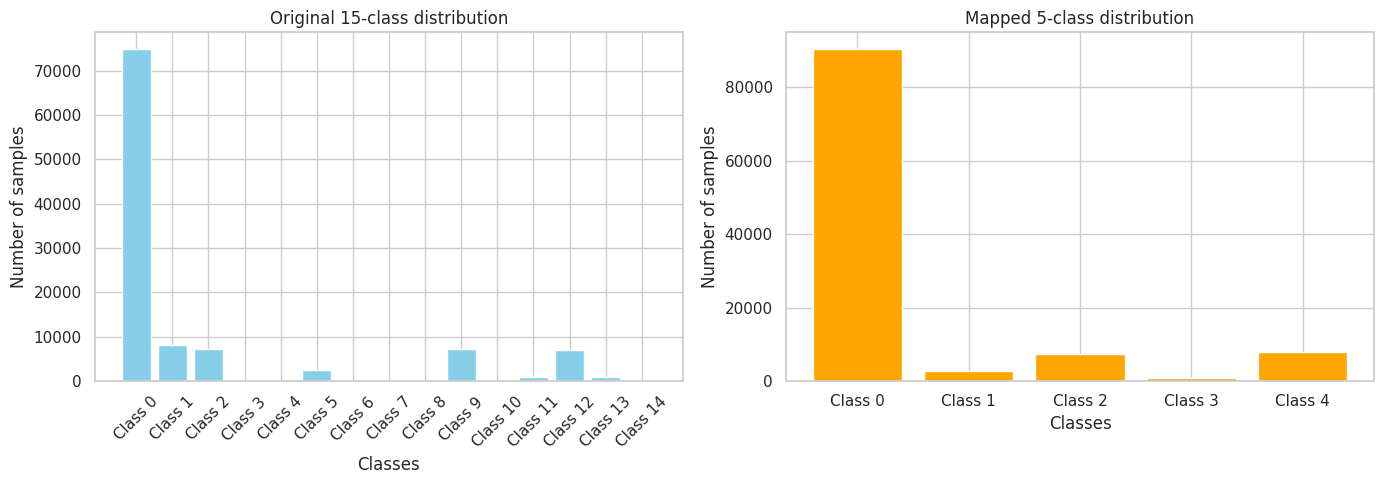

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Assuming Y is the original 15-class labels
# And Y_5class is the mapped 5-class labels

# Count original 15-class
count_15 = Counter(Y)
labels_15 = [f'Class {i}' for i in range(15)]
values_15 = [count_15[i] for i in range(15)]

# Count new 5-class
count_5 = Counter(Y_5class)
labels_5 = [f'Class {i}' for i in range(5)]
values_5 = [count_5[i] for i in range(5)]

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Original 15-class distribution
ax[0].bar(labels_15, values_15, color='skyblue')
ax[0].set_title('Original 15-class distribution')
ax[0].set_ylabel('Number of samples')
ax[0].set_xlabel('Classes')
ax[0].tick_params(axis='x', rotation=45)

# Mapped 5-class distribution
ax[1].bar(labels_5, values_5, color='orange')
ax[1].set_title('Mapped 5-class distribution')
ax[1].set_ylabel('Number of samples')
ax[1].set_xlabel('Classes')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

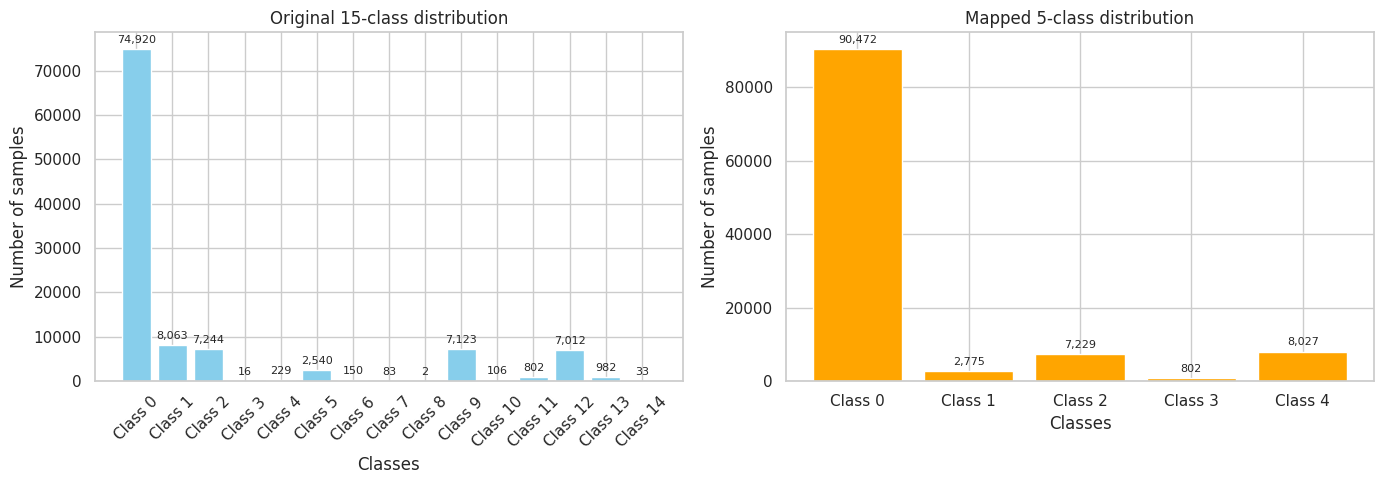

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Assuming Y is the original 15-class labels
# And Y_5class is the mapped 5-class labels

# Count original 15-class
count_15 = Counter(Y)
labels_15 = [f'Class {i}' for i in range(15)]
values_15 = [count_15[i] for i in range(15)]

# Count new 5-class
count_5 = Counter(Y_5class)
labels_5 = [f'Class {i}' for i in range(5)]
values_5 = [count_5[i] for i in range(5)]

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Original 15-class distribution
bars1 = ax[0].bar(labels_15, values_15, color='skyblue')
ax[0].set_title('Original 15-class distribution')
ax[0].set_ylabel('Number of samples')
ax[0].set_xlabel('Classes')
ax[0].tick_params(axis='x', rotation=45)

# Annotate counts on top of bars
for bar in bars1:
    height = bar.get_height()
    ax[0].annotate(f'{height:,}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0,3),  # 3 points vertical offset
                   textcoords='offset points',
                   ha='center', va='bottom',
                   fontsize=8)

# Mapped 5-class distribution
bars2 = ax[1].bar(labels_5, values_5, color='orange')
ax[1].set_title('Mapped 5-class distribution')
ax[1].set_ylabel('Number of samples')
ax[1].set_xlabel('Classes')
ax[1].tick_params(axis='x', rotation=0)

# Annotate counts on top of bars
for bar in bars2:
    height = bar.get_height()
    ax[1].annotate(f'{height:,}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0,3),
                   textcoords='offset points',
                   ha='center', va='bottom',
                   fontsize=8)

plt.tight_layout()
plt.show()

In [162]:
Y_5class_list = list(Y_5class)
Counter(Y_5class_list)

Counter({np.float64(0.0): 90472,
         np.float64(4.0): 8027,
         np.float64(2.0): 7229,
         np.float64(1.0): 2775,
         np.float64(3.0): 802})

In [163]:
ecg_dataset = np.copy(train_ds)

In [164]:
# label encode the target variable # just convert numpy.float64 to numpy.int64
from sklearn.preprocessing import LabelEncoder
Y_5class = LabelEncoder().fit_transform(Y_5class)

In [165]:
ecg_data = ecg_dataset[:, :300]
ecg_lable = Y_5class.reshape(-1, 1) # otherwise np.hstack will not work

In [166]:
# Complete ECG dataset with 5 type of Arrhythmia
ecg_dataset_5 = np.hstack((ecg_data, ecg_lable))

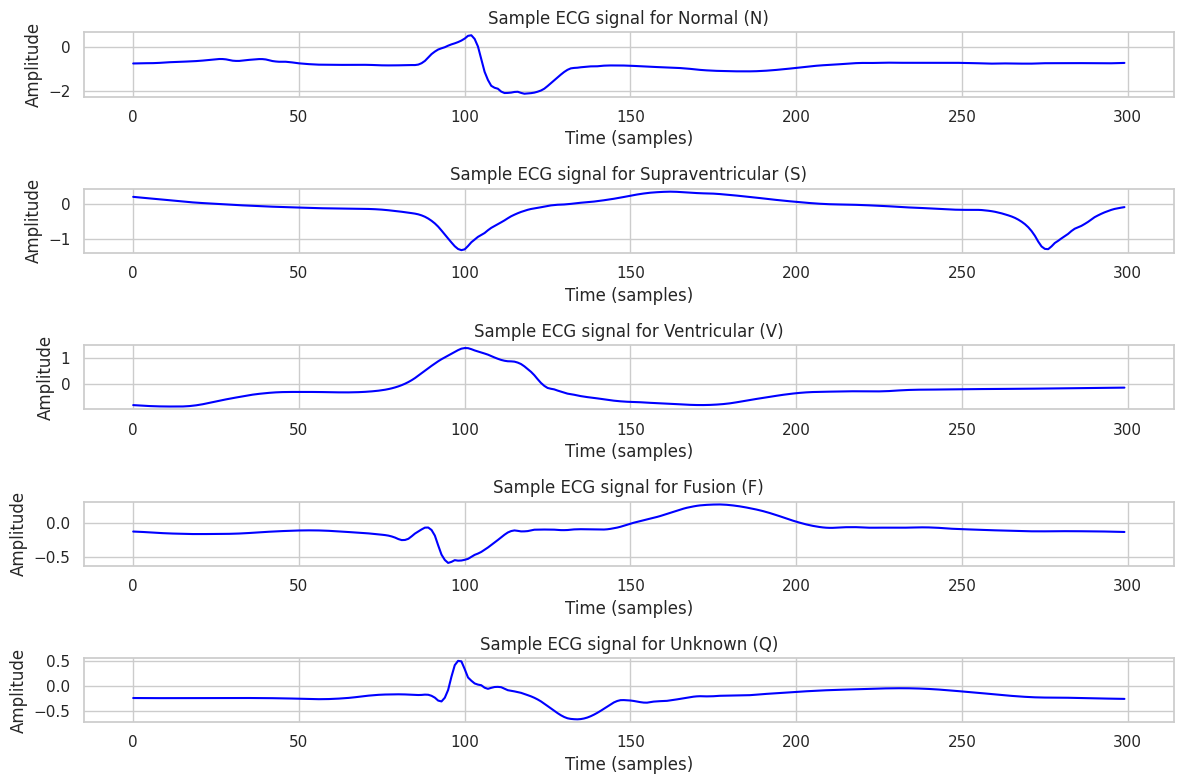

In [167]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose ecg_data is shape (N_samples, signal_length)
# and ecg_label is shape (N_samples,) with values 0-4 (5 arrhythmia classes)

classes = ["Normal (N)",
           "Supraventricular (S)",
           "Ventricular (V)",
           "Fusion (F)",
           "Unknown (Q)"]

plt.figure(figsize=(12, 8))

for i, cls in enumerate(np.unique(ecg_lable)):
    idx = np.where(ecg_lable == cls)[0][0]   # pick one example
    plt.subplot(5, 1, i+1)
    plt.plot(ecg_data[idx], color="blue")
    plt.title(f"Sample ECG signal for {classes[cls]}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### **c. Per class data status checking (Full data)**

In [168]:
# Convert ndarray to dataframe
df_ecg = pd.DataFrame(ecg_dataset_5)
class_data = df_ecg[300].value_counts()
class_data

,count
300,
0.0,90472
4.0,8027
2.0,7229
1.0,2775
3.0,802


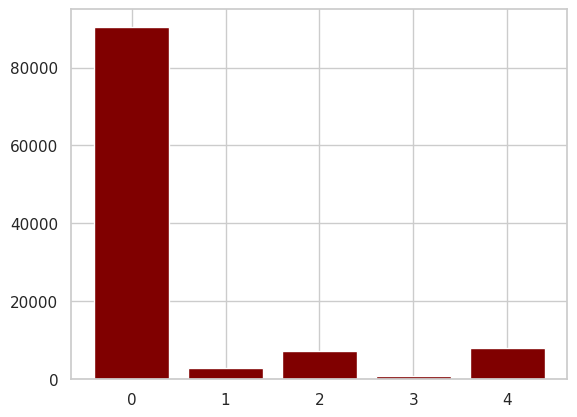

In [169]:
# per class data status plotting,
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

<Axes: xlabel='300'>

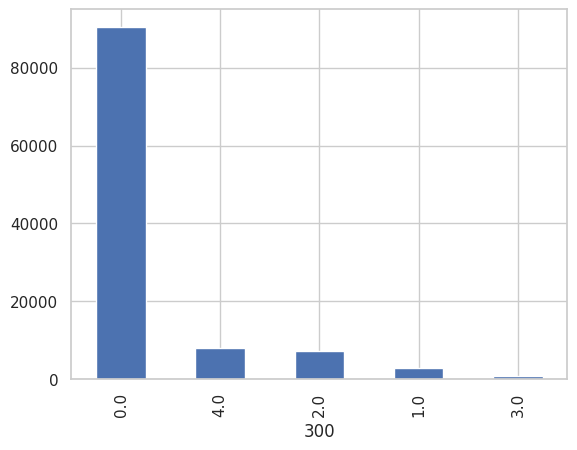

In [170]:
# shortcut for per class data status plotting,
# Order is not maintained by class. Higher to lower
df_ecg[300].value_counts().plot(kind='bar')

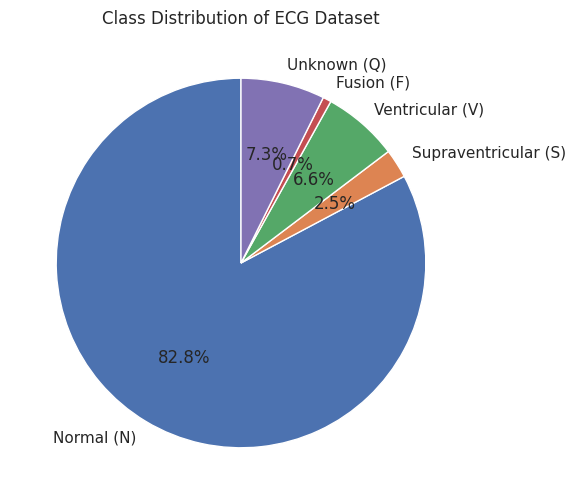

In [171]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["Normal (N)", "Supraventricular (S)", "Ventricular (V)", "Fusion (F)", "Unknown (Q)"]

unique, counts = np.unique(ecg_lable, return_counts=True)

plt.figure(figsize=(6,6))
plt.pie(counts, labels=[classes[i] for i in unique], autopct='%1.1f%%', startangle=90)
plt.title("Class Distribution of ECG Dataset")
plt.show()

## **D2: Train-Test Spliting**
**Note: Class Balance should be done on Training Data Only. Not Testing Data.**

In [172]:
# train test splitting
from sklearn.model_selection import train_test_split
ecg_data = ecg_dataset_5[:, :300]
ecg_label = ecg_dataset_5[:, 300]
x_train, x_test, y_train, y_test = train_test_split(ecg_data, ecg_label,
                                   random_state=104,
                                   test_size=0.20,
                                   shuffle=True)

In [173]:
# reshaping for using hstack function
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
train_data = np.hstack((x_train, y_train))
test_data = np.hstack((x_test, y_test))

In [174]:
#  converting dataframe
train_data = pd.DataFrame(train_data)
test_data = pd.DataFrame(test_data)

In [175]:
# saving the test data (in imbalanced condition)
file_name = project_path + 'test_data.pkl'
test_data.to_pickle(file_name)

**Training dataset status checking:** balanced / imbalanced

300
0.0    72396
4.0     6421
2.0     5773
1.0     2223
3.0      631
Name: count, dtype: int64


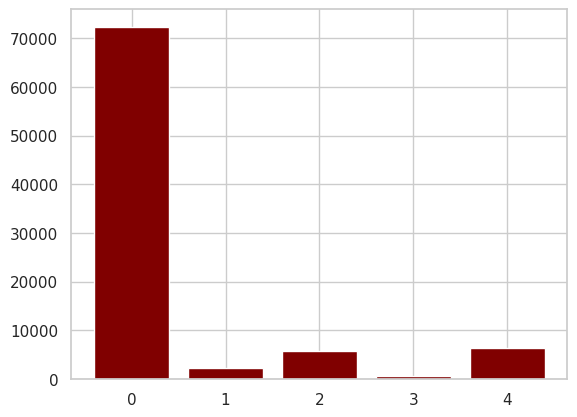

In [176]:
# Imblanced training data graph ploting
class_data = train_data[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

## **D3: Class balancing by undersampling and SMOTE**
**SMOTE** stands for '**Synthetic Minority Oversampling Technique**'.
Plan for train data
1. Class 1: Randomly selected 50000 data
2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

In [177]:
# extracting class 0 and 4 others class
train_data_0 = train_data.loc[(train_data[300] == 0)]
train_data_1234 = train_data.loc[(train_data[300] != 0)]

In [248]:
# 1. Class 1: Randomly selected 50000 data
from sklearn.utils import resample
train_data_0_resampled=train_data_0.sample(n=50000,random_state=42)

# convert dataframe to numpy array
train_data_0_resampled = train_data_0_resampled.to_numpy()

In [249]:
# 2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 50000 data

# converting from df to np ndarray
train_data_1234_arr = train_data_1234.to_numpy()
X_4cl, y_4cl = train_data_1234_arr[:, :-1], train_data_1234_arr[:, -1]

from imblearn.over_sampling import SMOTE
# transform the dataset
strategy = {1:50000, 2:50000, 3:50000, 4:50000}
oversample = SMOTE(sampling_strategy=strategy)
X, y = oversample.fit_resample(X_4cl, y_4cl)

y = y.reshape(-1, 1)
train_data_1234_resampled = np.hstack((X, y))

In [250]:
# Join the class 0 and 1234
train_data_resampled = np.vstack((train_data_0_resampled, train_data_1234_resampled))

# shuffle the data, needed for proper training
np.take(train_data_resampled,np.random.permutation(train_data_resampled.shape[0]),axis=0,out=train_data_resampled)

array([[-0.23048357, -0.23126321, -0.23208419, ..., -0.26362534,
        -0.26447822,  4.        ],
       [-0.20526769, -0.20106898, -0.19876566, ..., -0.3330475 ,
        -0.3327947 ,  1.        ],
       [ 0.03894136,  0.0643107 ,  0.0909468 , ..., -0.4025566 ,
        -0.40516926,  2.        ],
       ...,
       [-0.01189646, -0.03323545, -0.05625468, ..., -0.13678445,
        -0.54746679,  3.        ],
       [-0.34842073, -0.35252209, -0.35737085, ..., -0.18660327,
        -0.18709737,  2.        ],
       [ 0.27699354,  0.29513091,  0.31305313, ..., -0.37221366,
        -0.38582113,  2.        ]])

300
4.0    50000
1.0    50000
2.0    50000
3.0    50000
0.0    50000
Name: count, dtype: int64


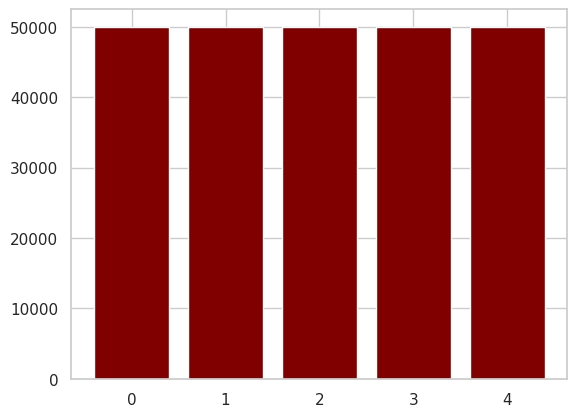

In [251]:
# Balanced training data graph ploting
train_data_r = pd.DataFrame(train_data_resampled)
class_data = train_data_r[300].value_counts()
print(class_data)
plt.bar(class_data.index, class_data.values, color ='maroon')
plt.show()

# save balanced training data
file_name = project_path + 'train_data_SMOTE.pkl'
train_data_r.to_pickle(file_name)

In [252]:
data_bal = np.array(class_data)
data_bal2 = data_bal.reshape(1, 5)

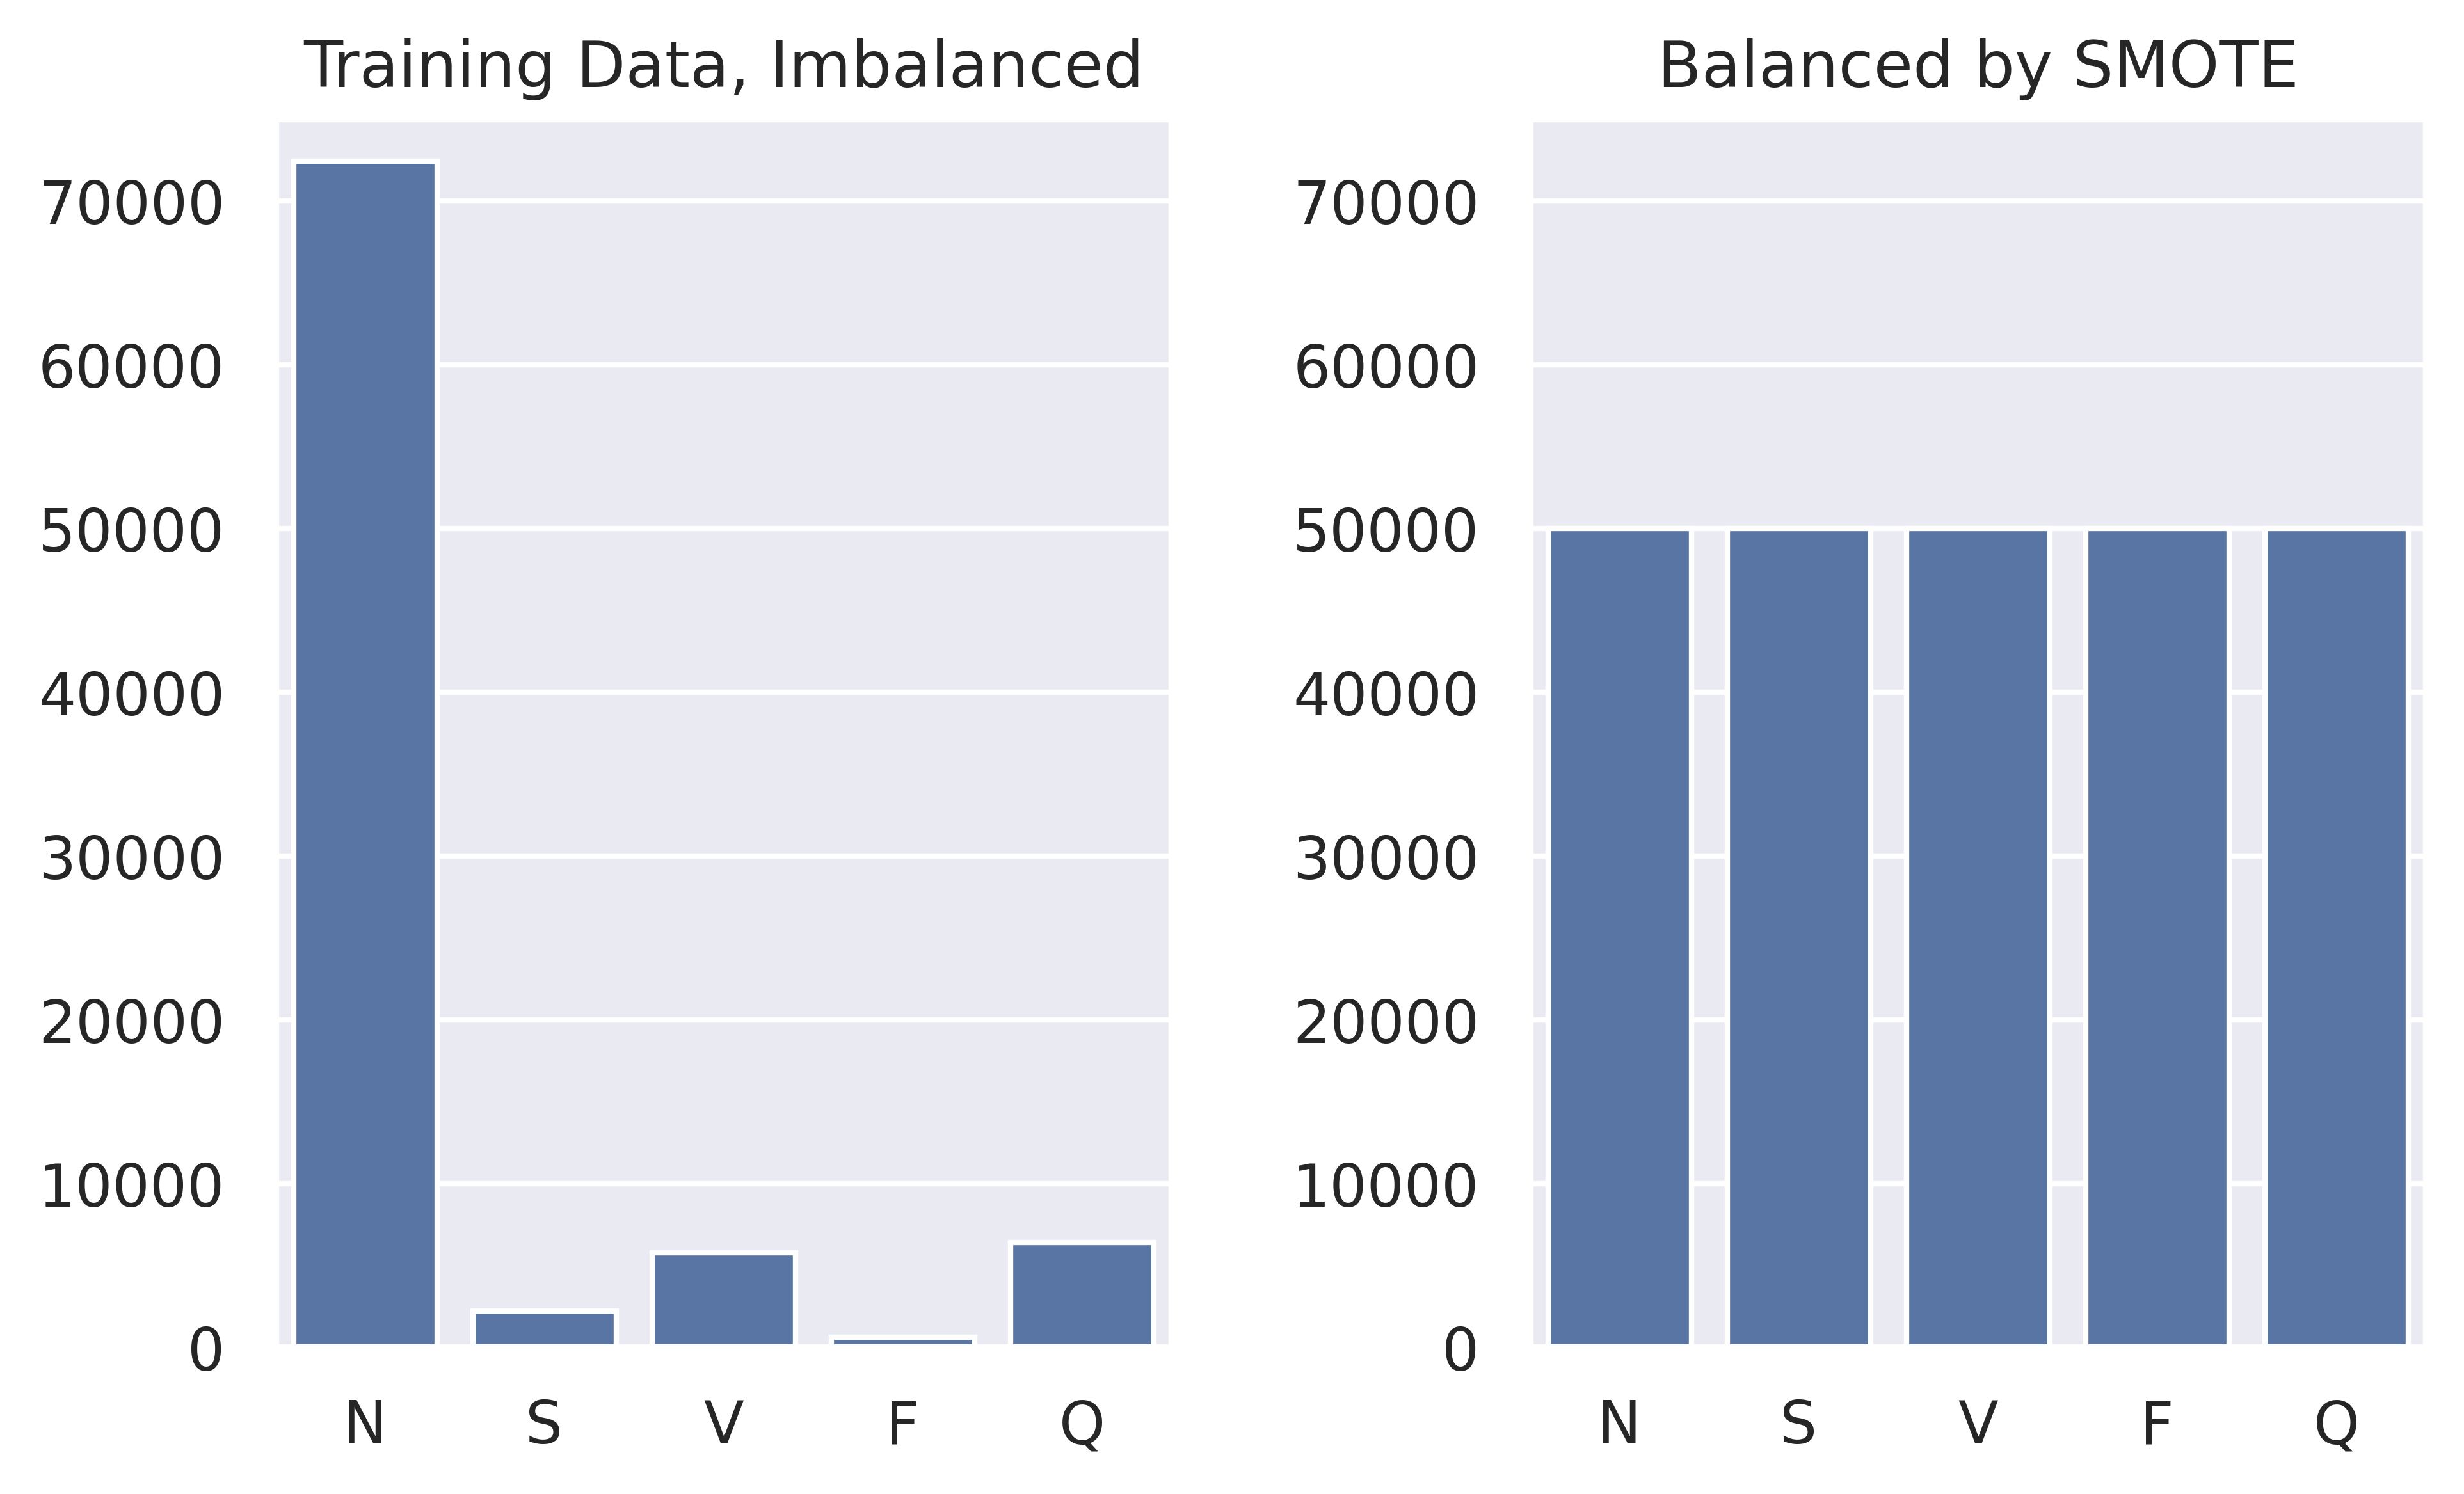

In [253]:
# A single plot which gives proper illustration before and after class balancing
import seaborn as sns
sns.set()
sns.color_palette("hls", 8)

fig = plt.figure(figsize=(7,4), dpi=600)
plt.subplot(121)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = [72420, 2212, 5774, 637, 6401])
plt.ylim(0, 75000)
plt.title('Training Data, Imbalanced')

plt.subplot(122)
sns.barplot(x = ['N', 'S', 'V', 'F', 'Q'], y = class_data.values)
plt.ylim(0, 75000)
plt.title('Balanced by SMOTE')

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)

#figure_path = '/content/gdrive/MyDrive/ECG Arrhythmia trying/Heartbeat_Figures/'
#fig.savefig(figure_path+ 'Class balancing.png')

/tmp/ipython-input-1087044400.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=before_labels, y=before_counts, palette="Set2")
/tmp/ipython-input-1087044400.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=after_labels, y=after_counts, palette="Set2")


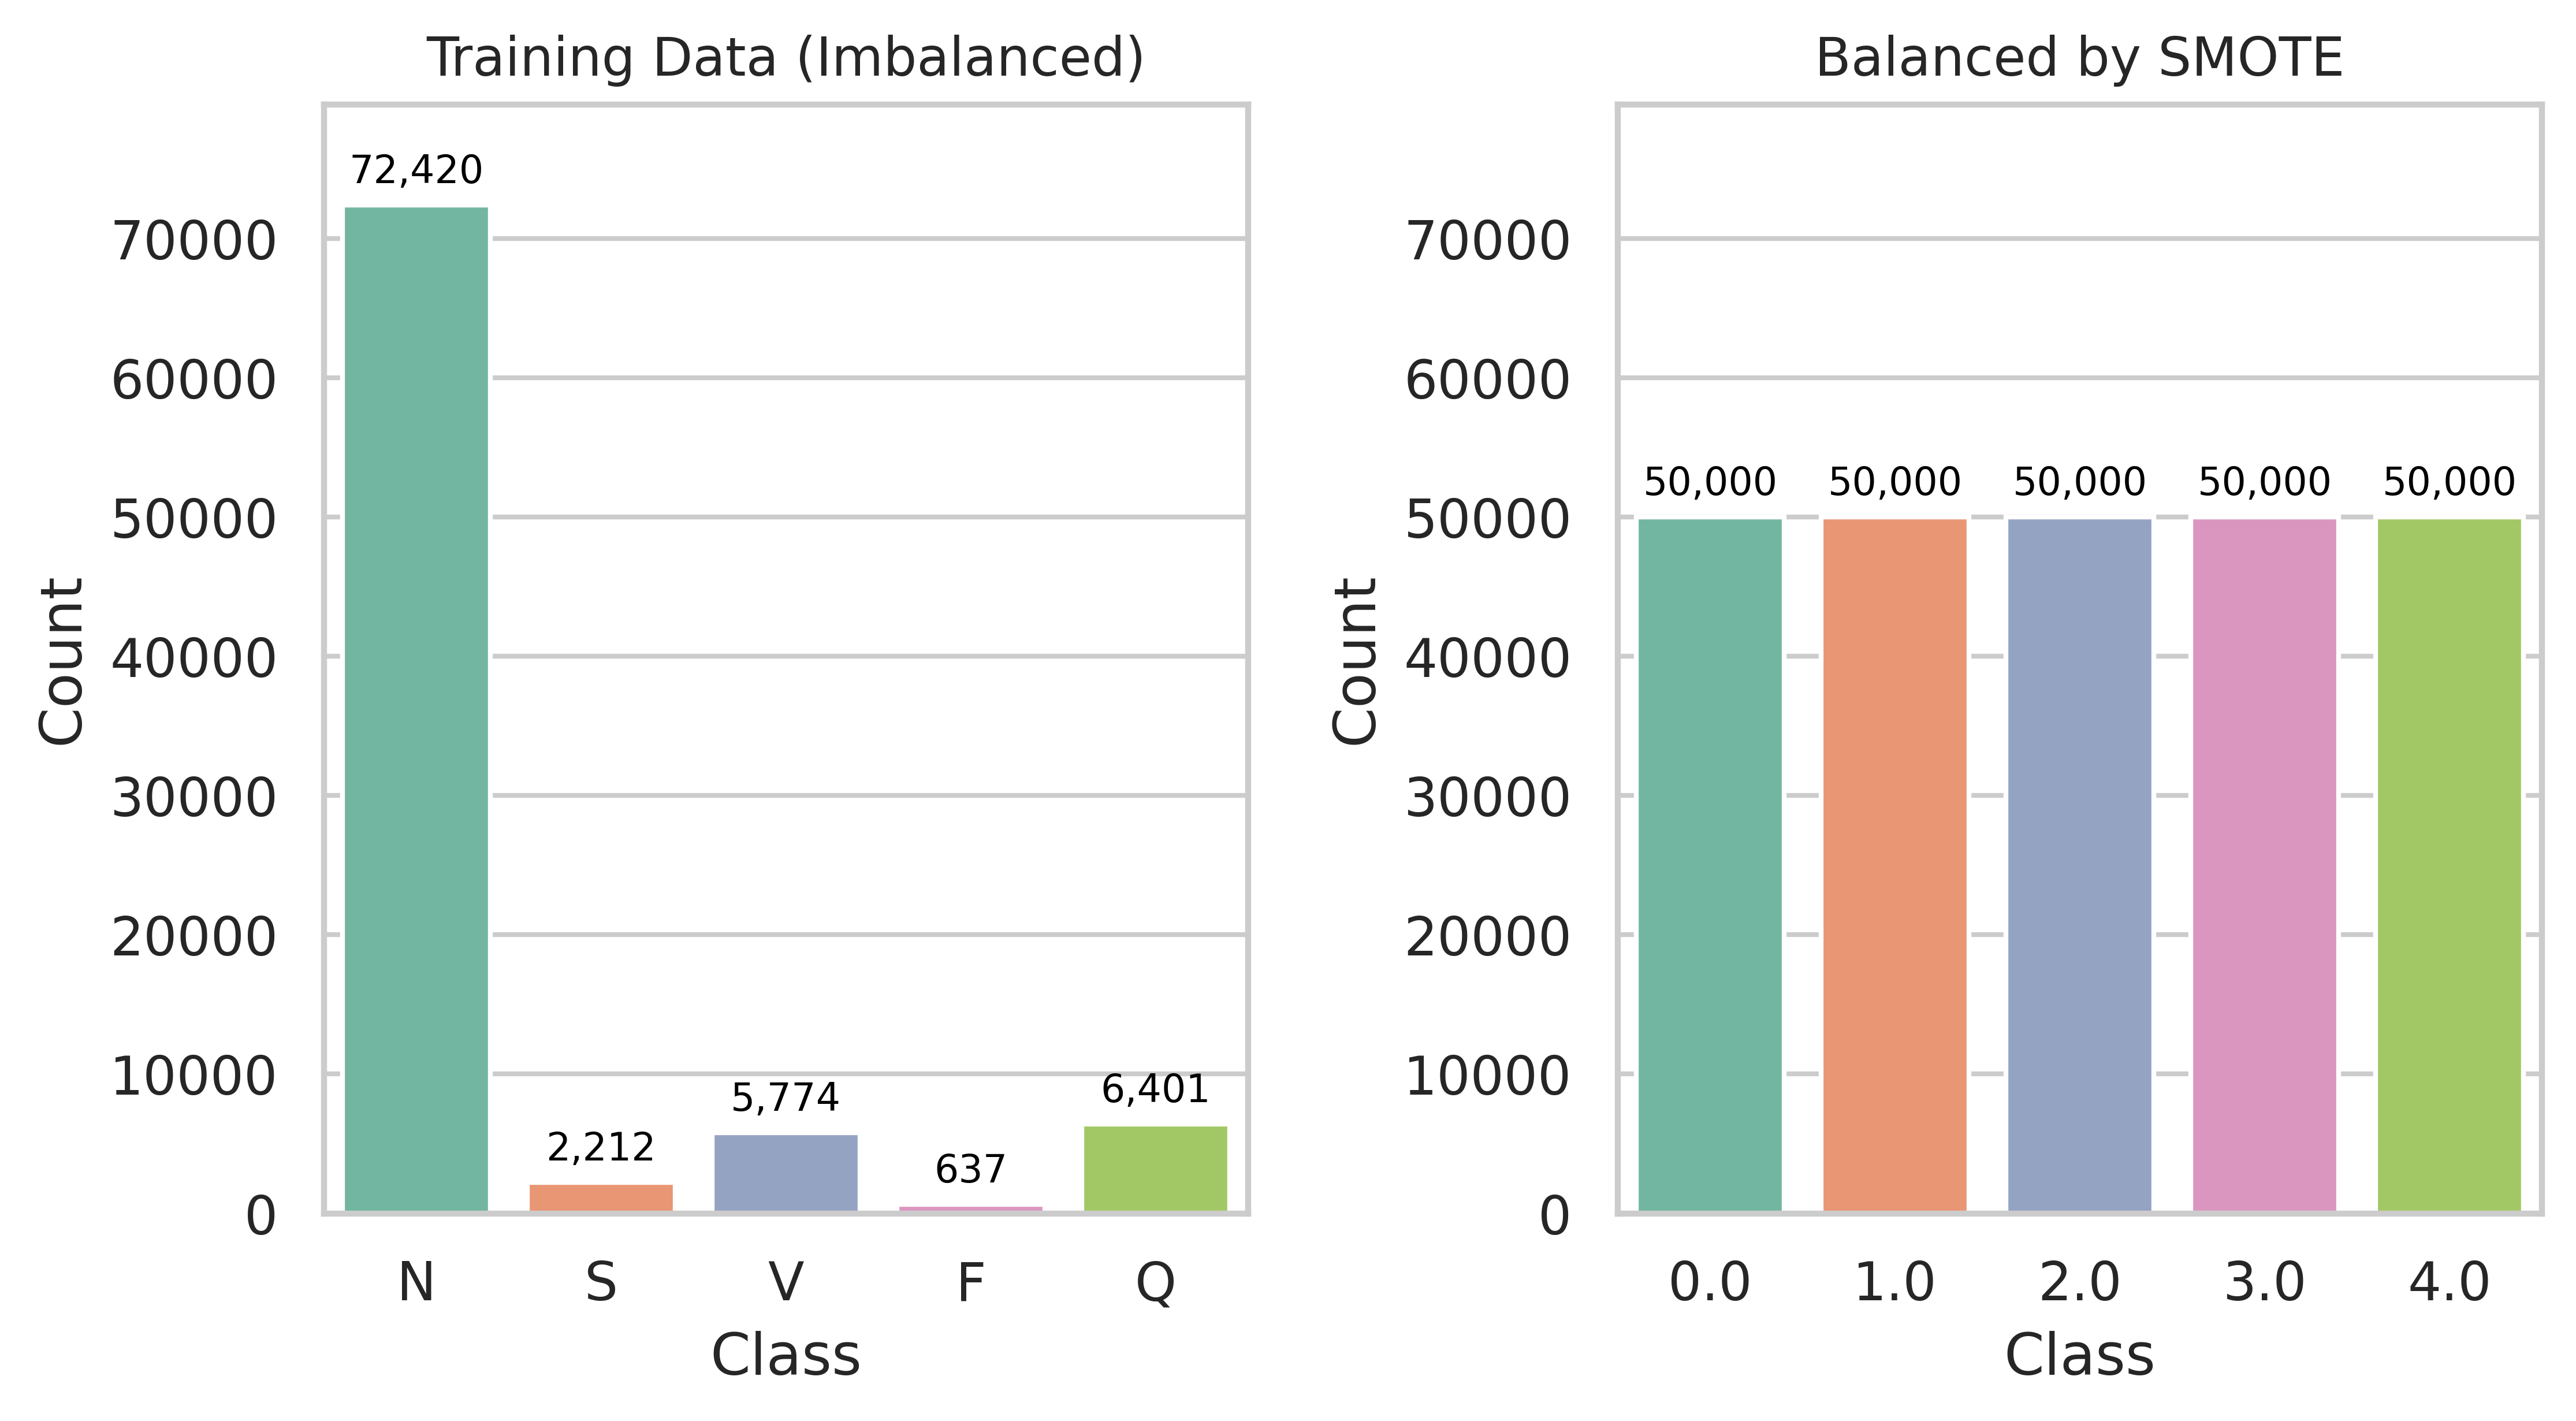

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
sns.color_palette("hls", 8)

# ---- Data from your existing variables ----
# Before balancing (you provided these counts manually)
before_labels = ['N', 'S', 'V', 'F', 'Q']
before_counts = [72420, 2212, 5774, 637, 6401]

# After balancing (class_data is from your database)
after_labels = class_data.index.tolist()
after_counts = class_data.values.tolist()

# ---- Create subplots ----
fig = plt.figure(figsize=(8, 4), dpi=600)

# ---- Before Balancing ----
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x=before_labels, y=before_counts, palette="Set2")
plt.ylim(0, max(before_counts + after_counts) * 1.1)
plt.title('Training Data (Imbalanced)', fontsize=11)
plt.xlabel("Class")
plt.ylabel("Count")

# Annotate counts on bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3),
                 textcoords='offset points')

# ---- After Balancing ----
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x=after_labels, y=after_counts, palette="Set2")
plt.ylim(0, max(before_counts + after_counts) * 1.1)
plt.title('Balanced by SMOTE', fontsize=11)
plt.xlabel("Class")
plt.ylabel("Count")

# Annotate counts on bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, color='black', xytext=(0, 3),
                 textcoords='offset points')

# Adjust layout
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9,
                    wspace=0.4, hspace=0.5)

plt.show()

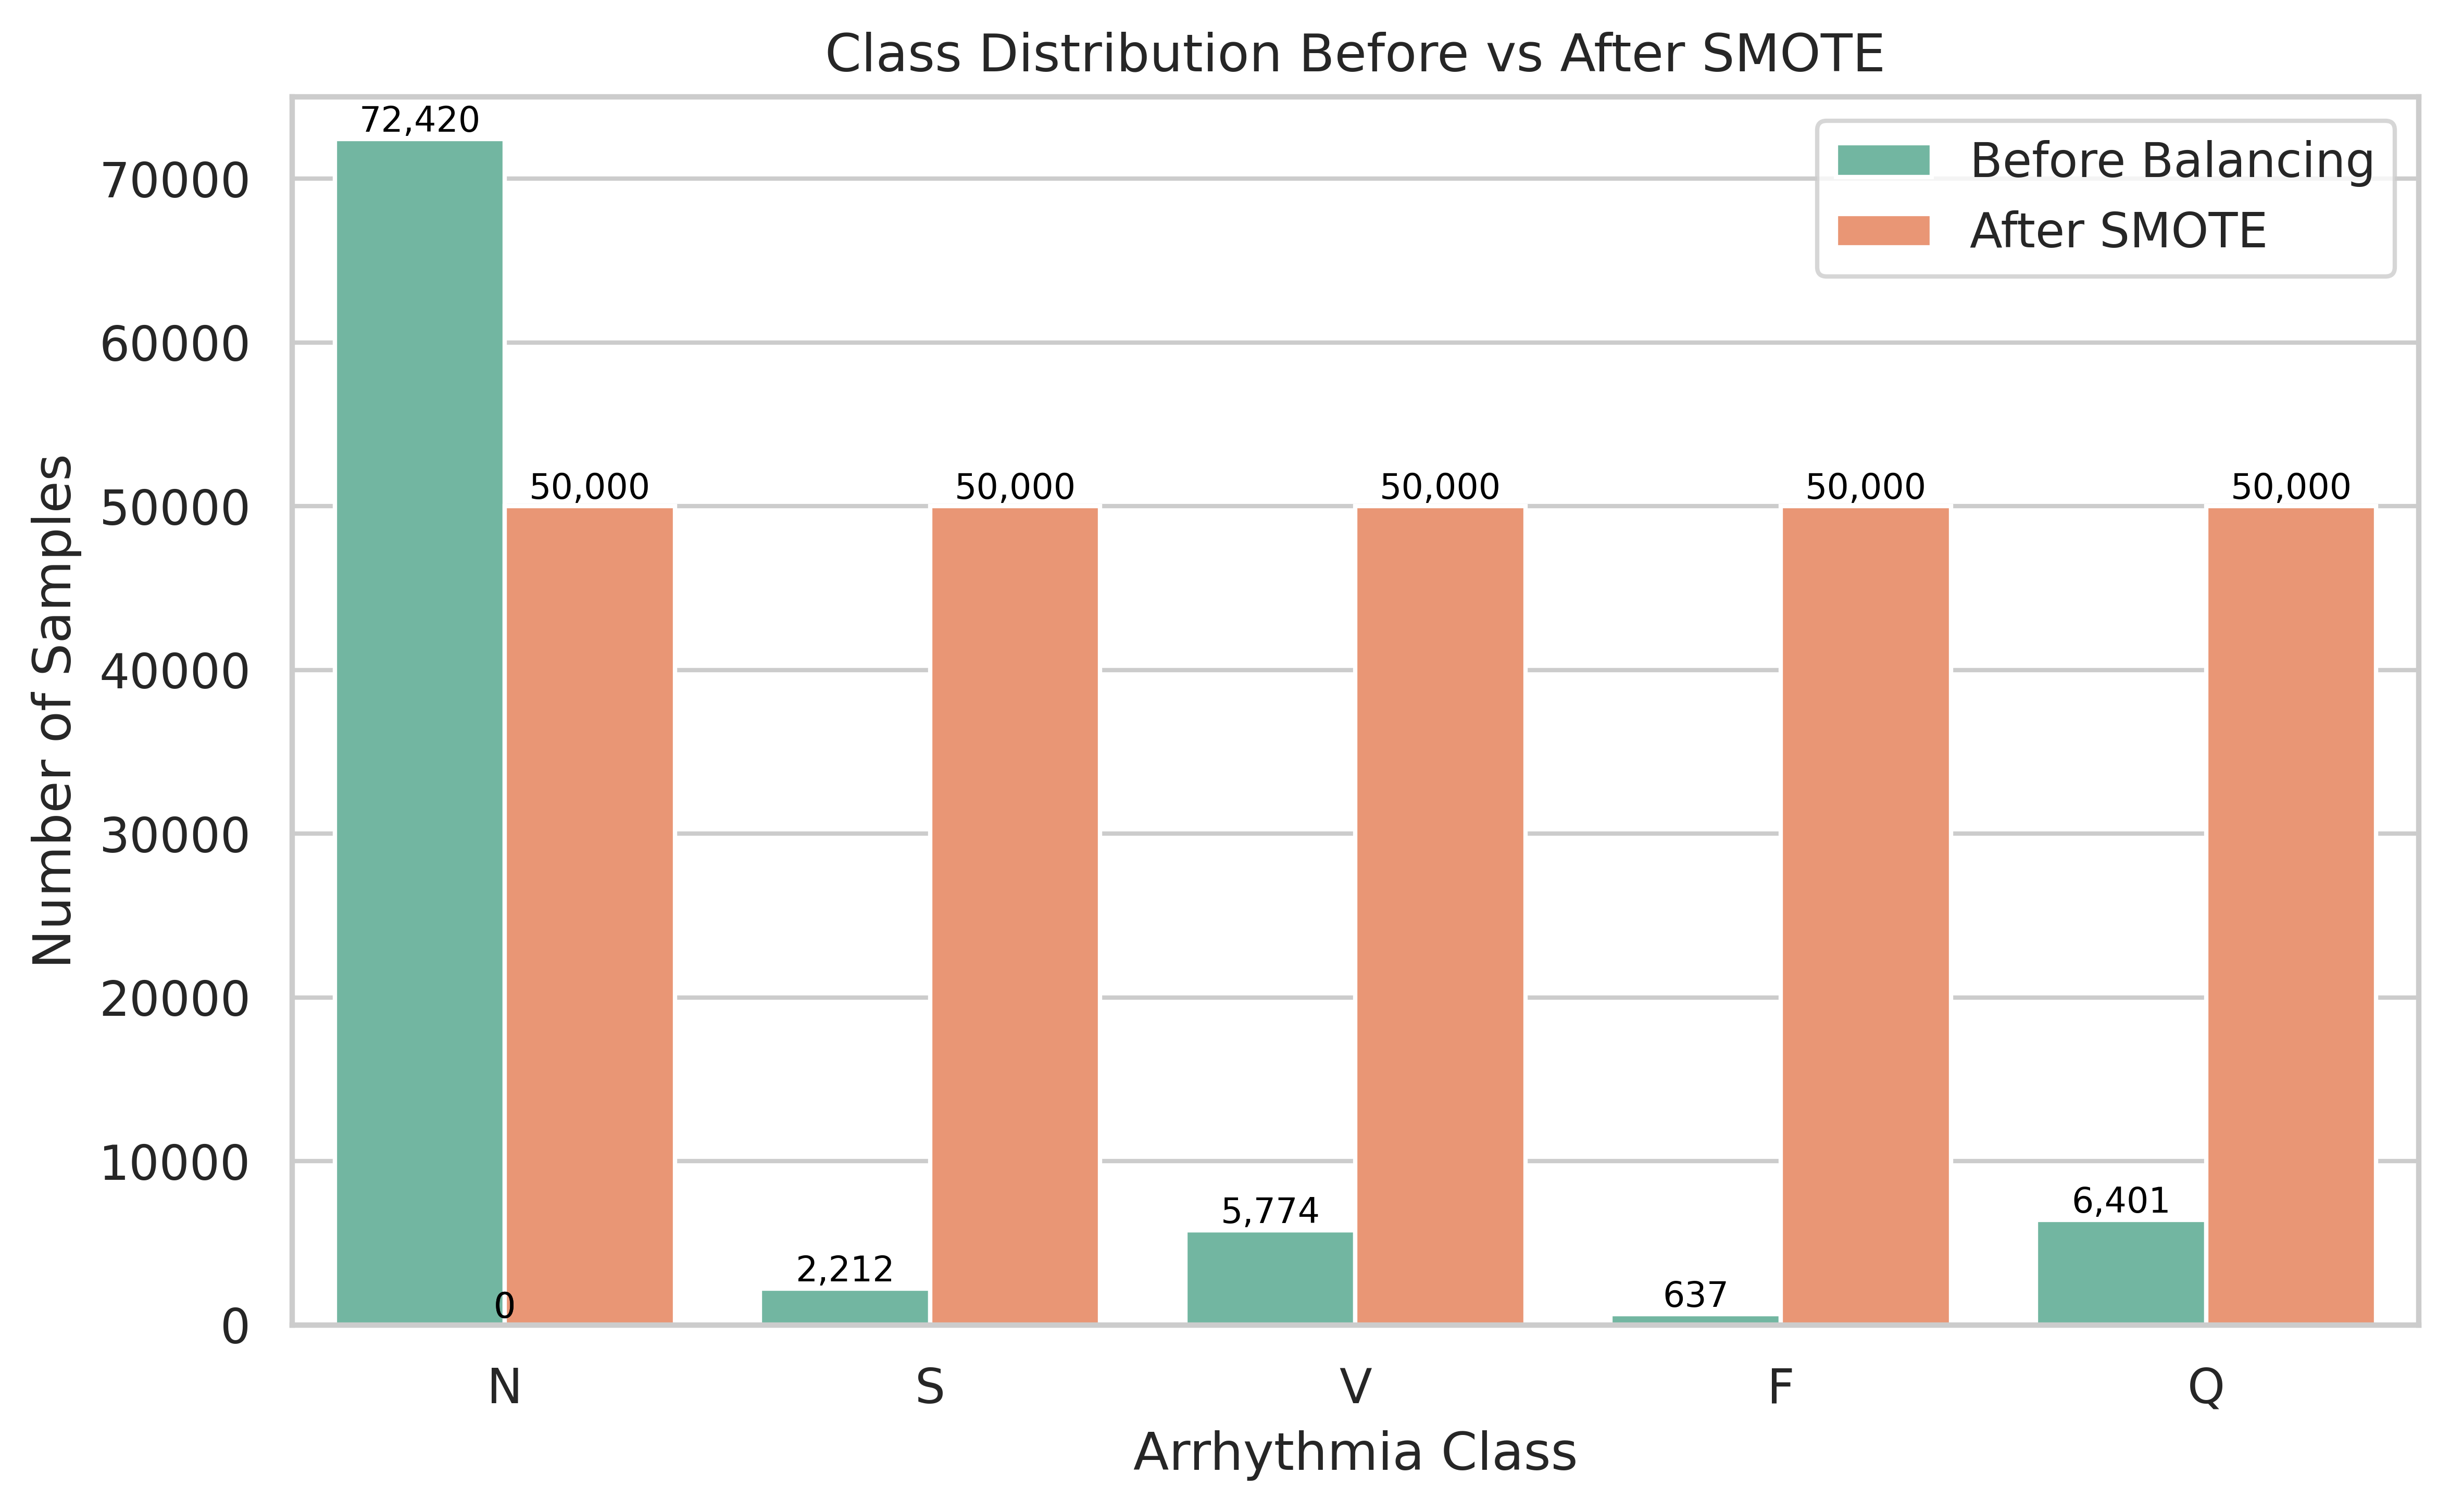

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Class names
classes = ['N', 'S', 'V', 'F', 'Q']

# Counts before balancing
counts_before = [72420, 2212, 5774, 637, 6401]

# Counts after balancing (from your class_data)
counts_after = class_data.values

# Build dataframe for plotting
df_plot = pd.DataFrame({
    "Class": classes * 2,
    "Samples": list(counts_before) + list(counts_after),
    "Dataset": ["Before Balancing"] * len(classes) + ["After SMOTE"] * len(classes)
})

# Plot grouped bars
plt.figure(figsize=(8, 5), dpi=600)
sns.barplot(data=df_plot, x="Class", y="Samples", hue="Dataset", palette="Set2")

plt.title("Class Distribution Before vs After SMOTE")
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Samples")
plt.ylim(0, 75000)

# Annotate counts on bars
for p in plt.gca().patches:
    plt.gca().annotate(format(int(p.get_height()), ','),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=8, color='black')

plt.legend(title="")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2928994015.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=labels, y=before_values, palette="Set2")
/tmp/ipython-input-2928994015.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=labels, y=after_values, palette="Set2")


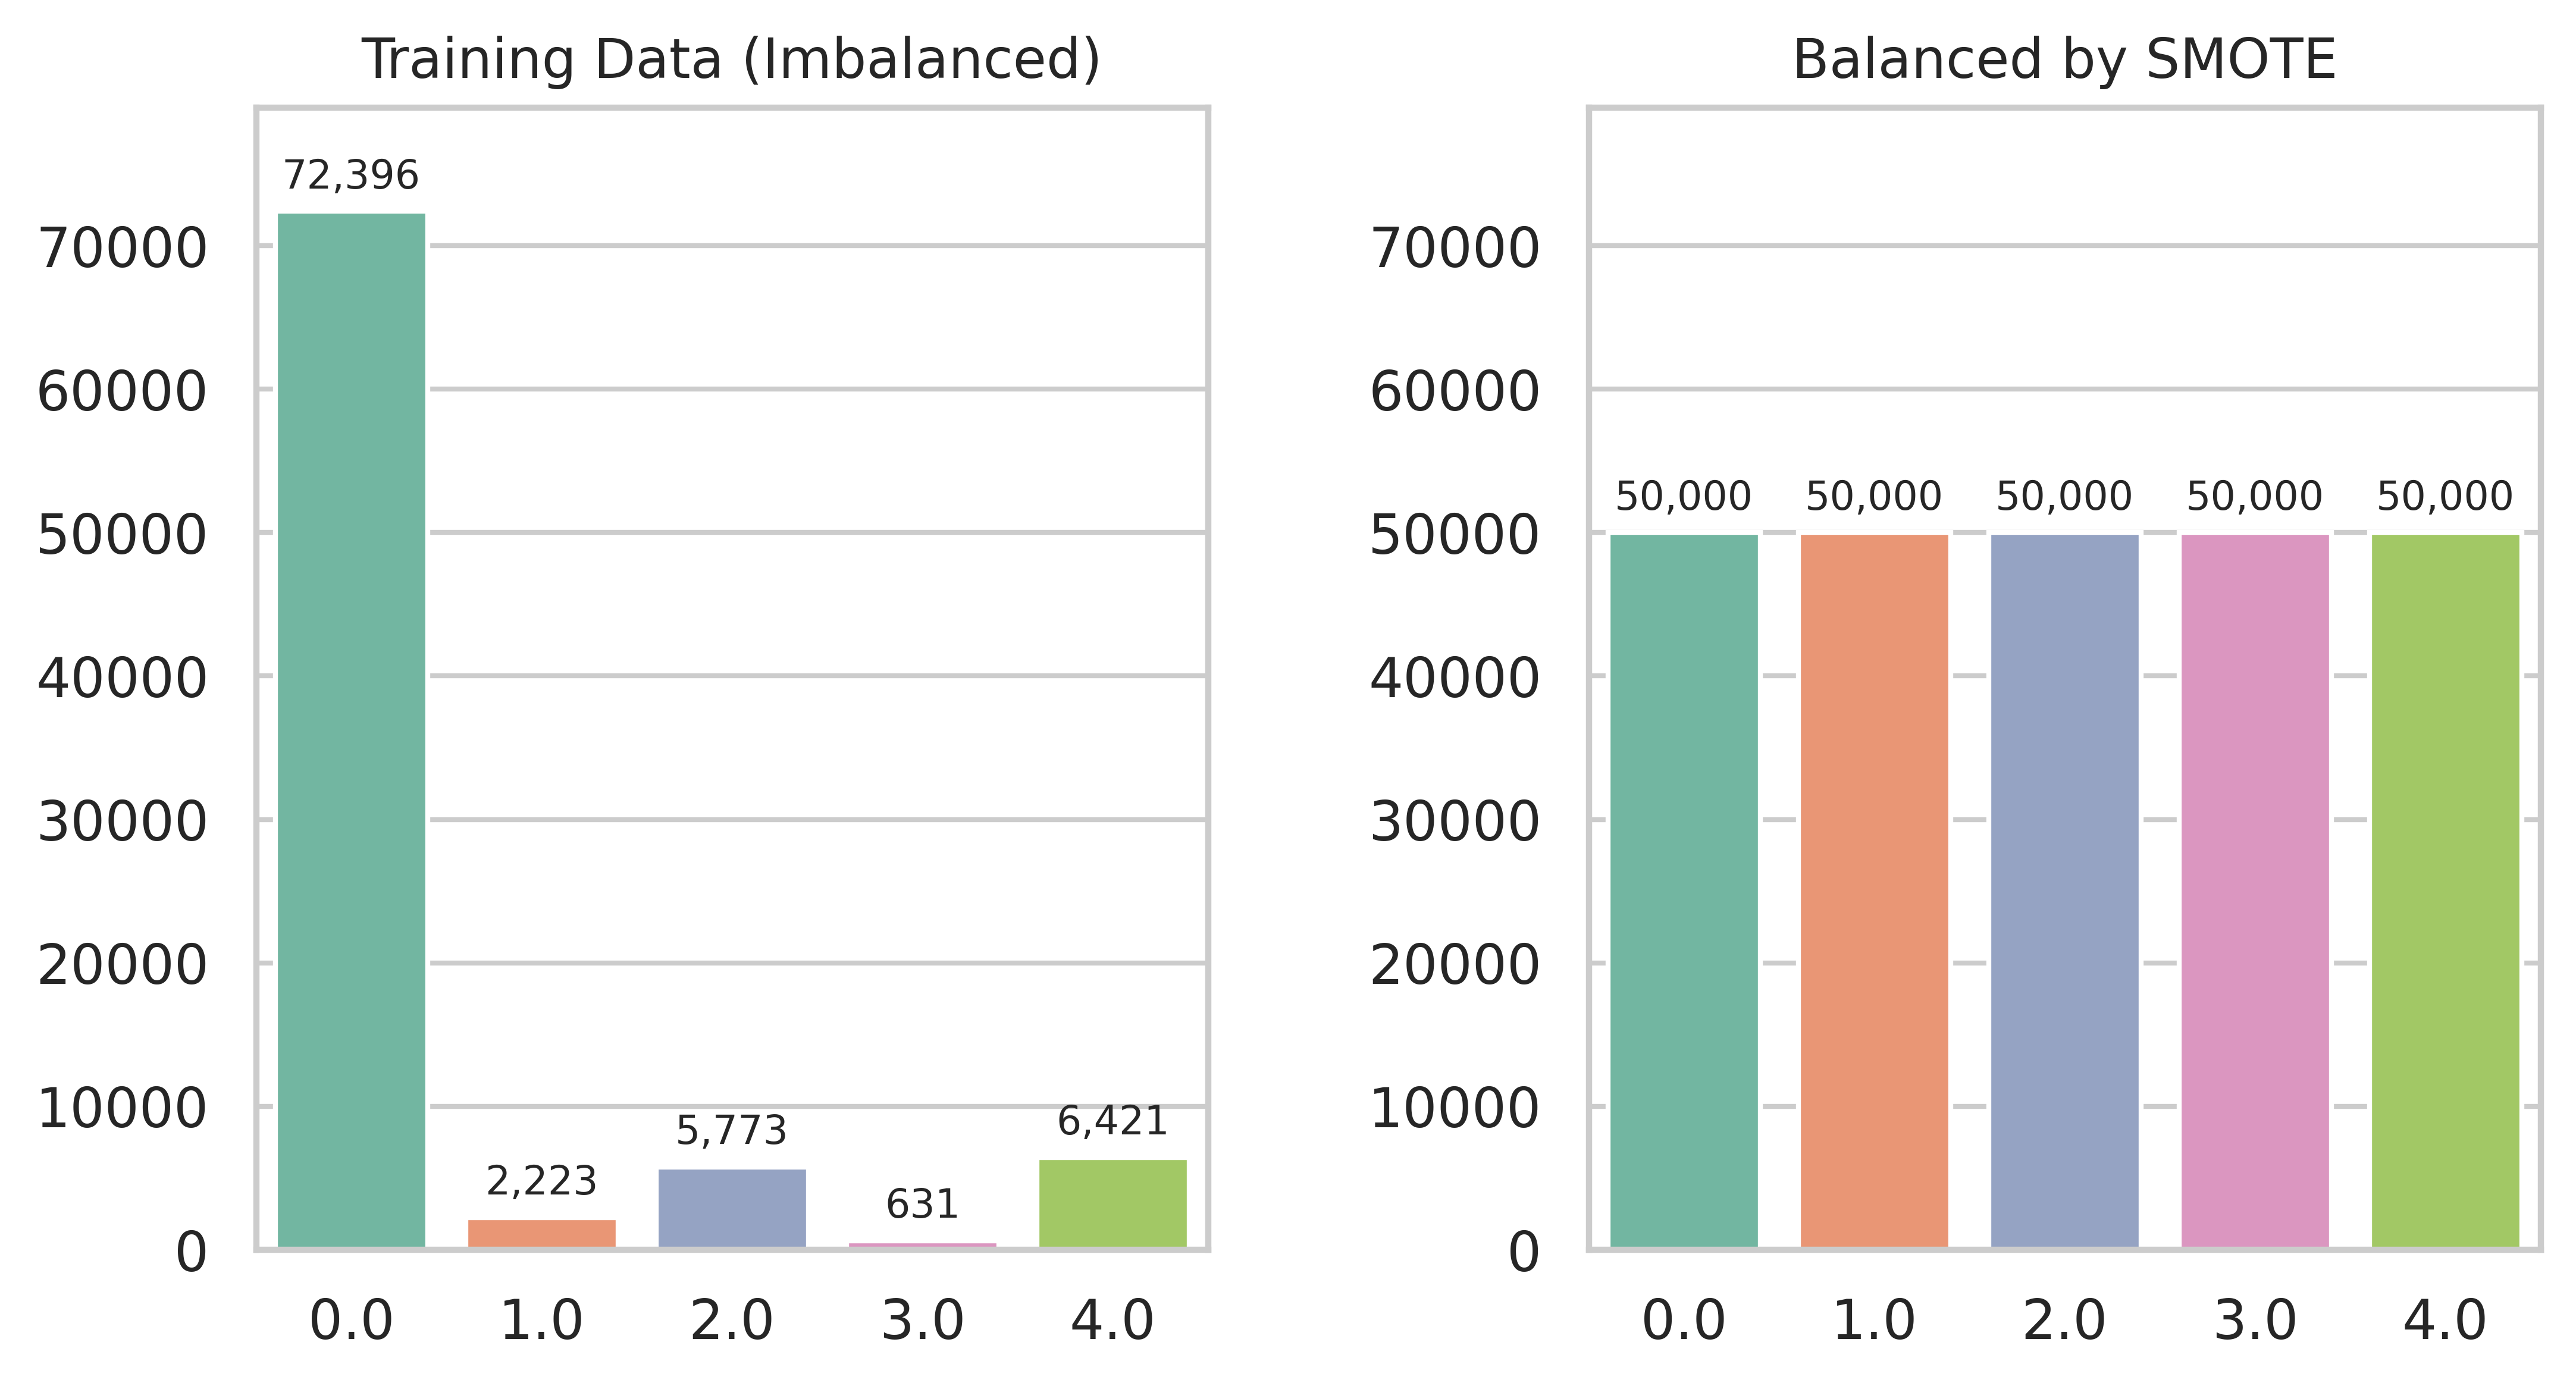

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")
sns.color_palette("hls", 8)

# Flatten the 2D y_train array
y_train_series = pd.Series(y_train.flatten())

# Counts before balancing
before_counts = y_train_series.value_counts().sort_index()

# Counts after balancing (class_data is assumed as a Series)
after_counts = class_data.sort_index()

# Labels and values
labels = before_counts.index.tolist()
before_values = before_counts.values
after_values = after_counts.values

# Plot
fig = plt.figure(figsize=(8, 4), dpi=600)

# Before balancing
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x=labels, y=before_values, palette="Set2")
plt.ylim(0, max(before_values.max(), after_values.max()) * 1.1)
plt.title('Training Data (Imbalanced)', fontsize=11)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, xytext=(0,3), textcoords='offset points')

# After balancing
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x=labels, y=after_values, palette="Set2")
plt.ylim(0, max(before_values.max(), after_values.max()) * 1.1)
plt.title('Balanced by SMOTE', fontsize=11)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, xytext=(0,3), textcoords='offset points')

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.5)
plt.show()

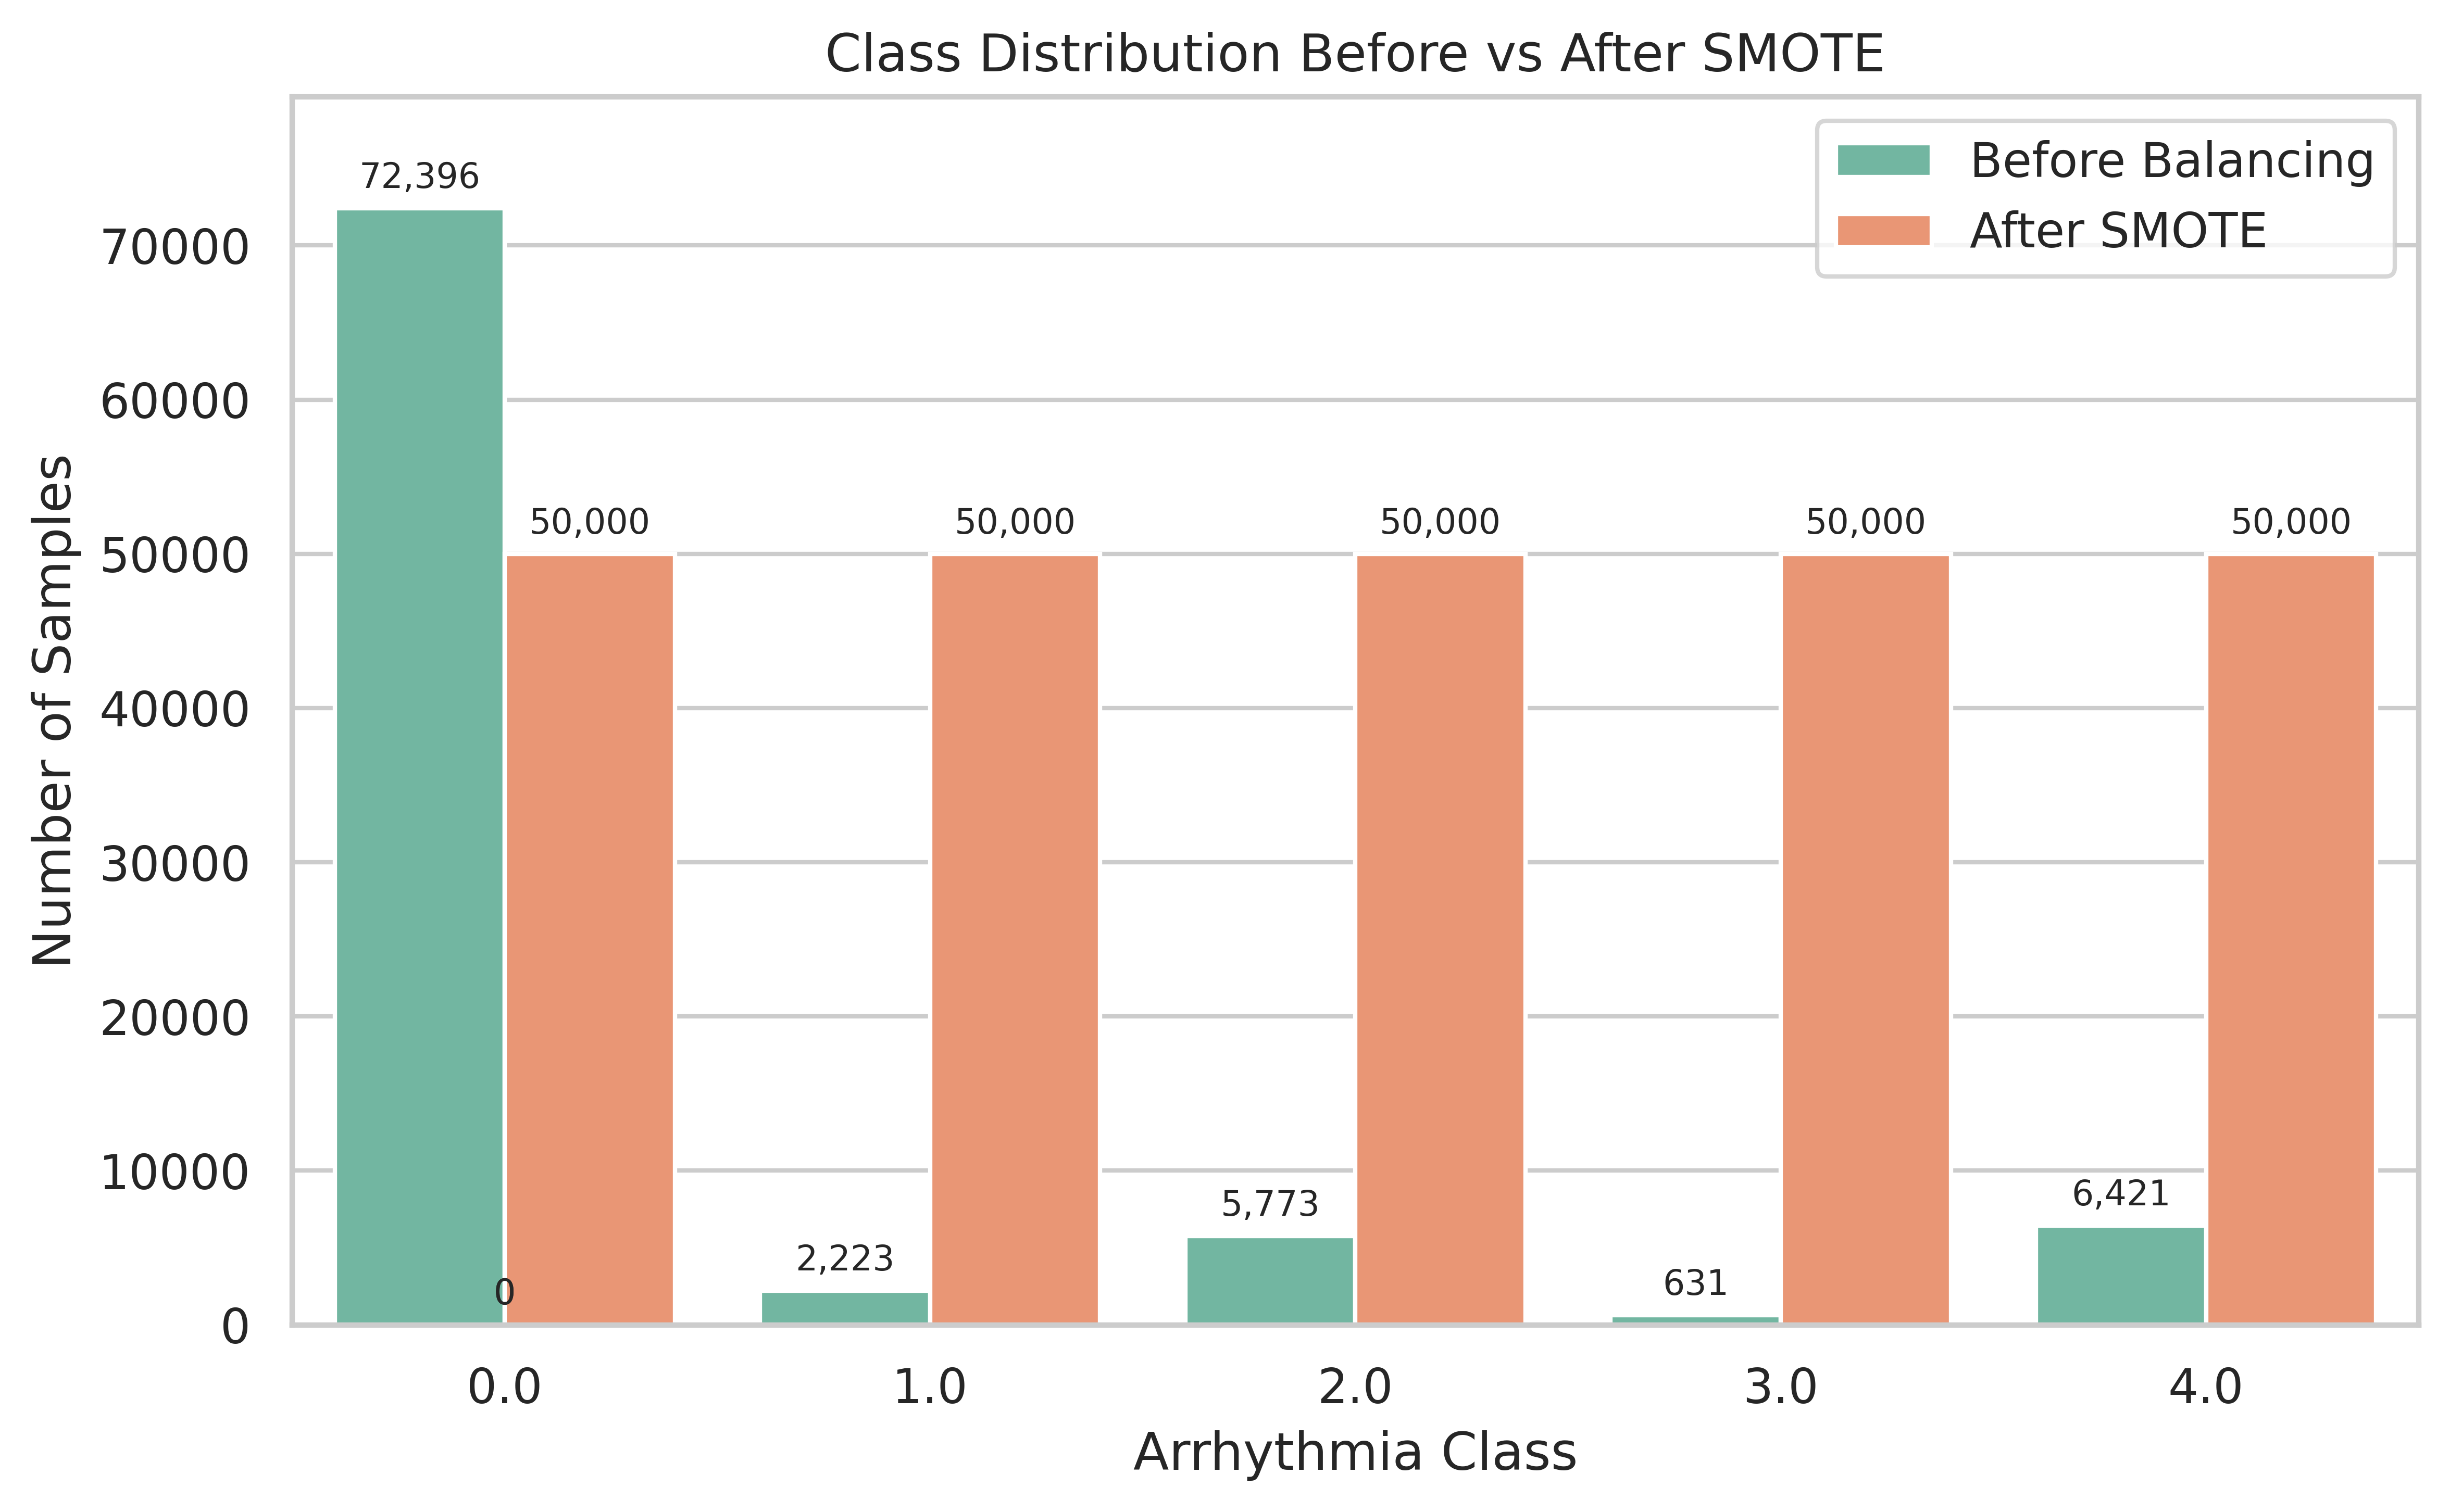

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# STEP 1: Count samples per class
# ----------------------------
# y_train can be a NumPy array or pandas Series
# If NumPy array with shape (n_samples, 1), flatten it
y_train_series = pd.Series(y_train.flatten())

# Counts before balancing
counts_before = y_train_series.value_counts().sort_index()
classes = counts_before.index.tolist()
counts_before_values = counts_before.values

# Counts after balancing (class_data is assumed to be a pandas Series)
counts_after = class_data.sort_index()
counts_after_values = counts_after.values

# ----------------------------
# STEP 2: Build DataFrame for plotting
# ----------------------------
df_plot = pd.DataFrame({
    "Class": classes * 2,
    "Samples": list(counts_before_values) + list(counts_after_values),
    "Dataset": ["Before Balancing"] * len(classes) + ["After SMOTE"] * len(classes)
})

# ----------------------------
# STEP 3: Plot grouped bars
# ----------------------------
plt.figure(figsize=(8, 5), dpi=600)
ax = sns.barplot(data=df_plot, x="Class", y="Samples", hue="Dataset", palette="Set2")

plt.title("Class Distribution Before vs After SMOTE")
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Samples")
plt.ylim(0, max(max(counts_before_values), max(counts_after_values)) * 1.1)

# ----------------------------
# STEP 4: Annotate counts on bars
# ----------------------------
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8, xytext=(0,3),
                textcoords='offset points')

plt.legend(title="")
plt.tight_layout()
plt.show()

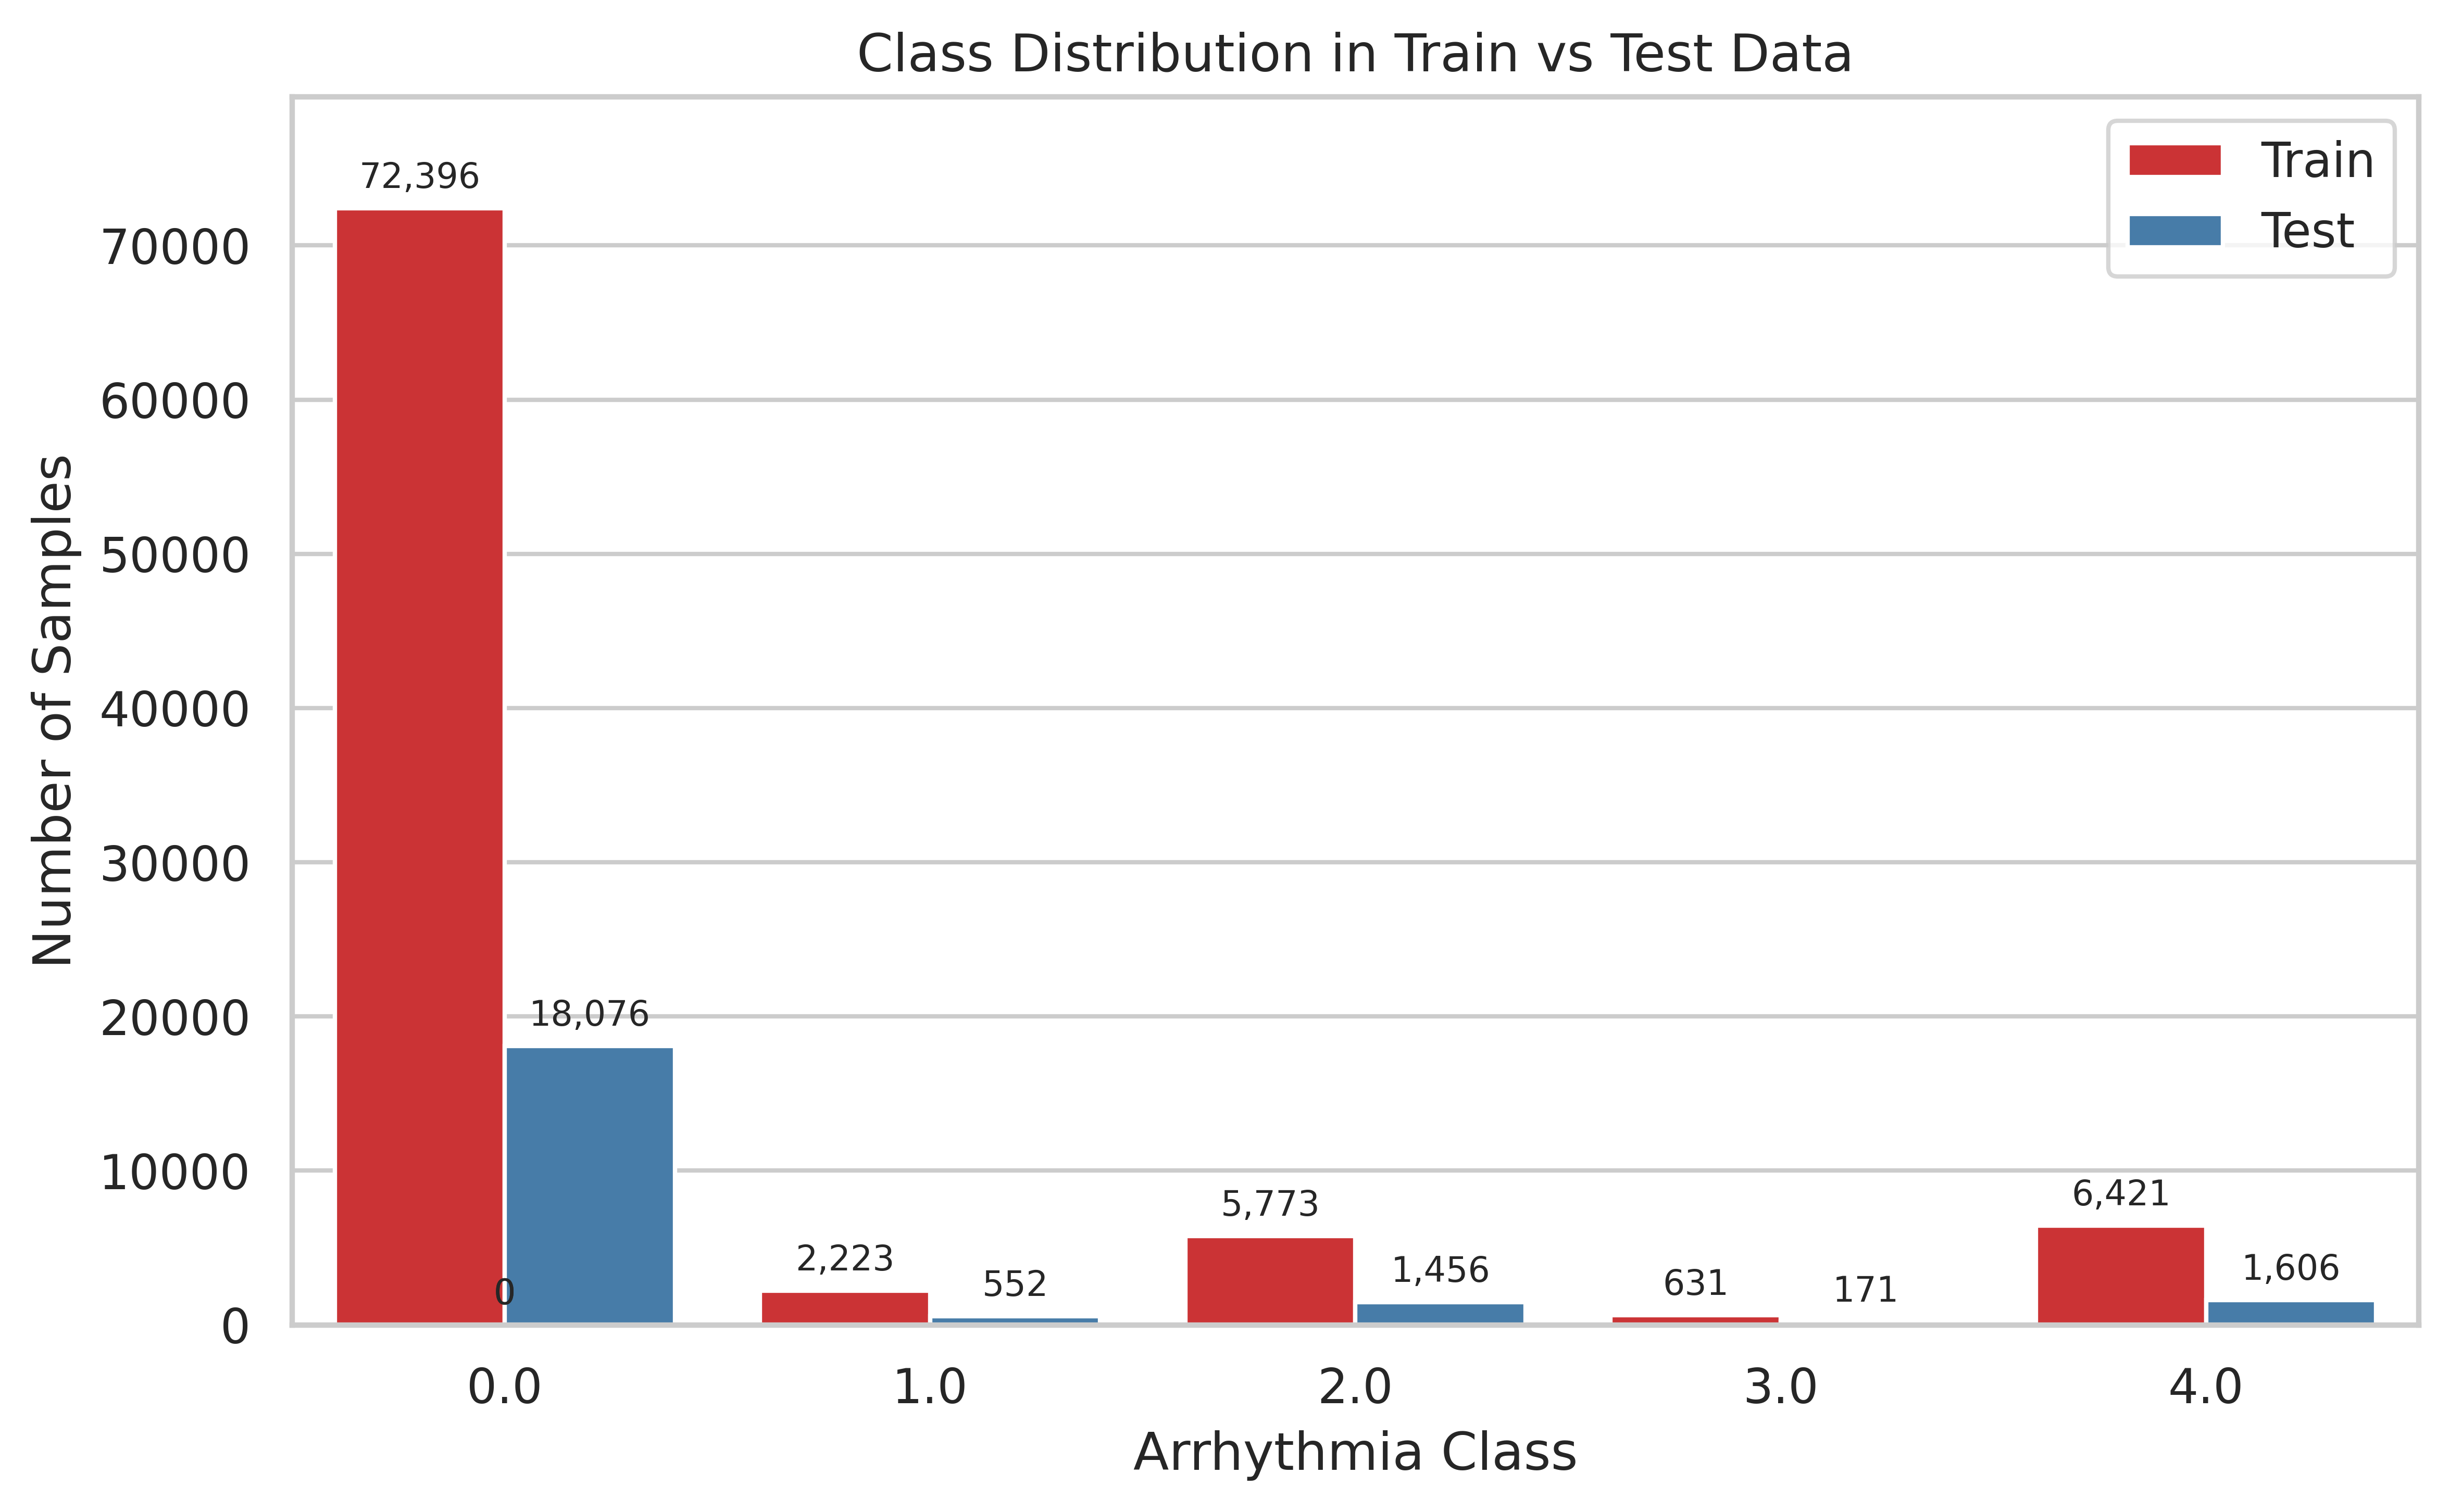

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# STEP 1: Count samples per class
# ----------------------------
# Convert to pandas Series if NumPy arrays
y_train_series = pd.Series(y_train.flatten(), name="Train")
y_test_series = pd.Series(y_test.flatten(), name="Test")

# Count class samples
counts_train = y_train_series.value_counts().sort_index()
counts_test = y_test_series.value_counts().sort_index()

classes = sorted(set(y_train_series.unique()) | set(y_test_series.unique()))

# Ensure all classes appear in both counts (fill missing with 0)
counts_train = counts_train.reindex(classes, fill_value=0)
counts_test = counts_test.reindex(classes, fill_value=0)

# ----------------------------
# STEP 2: Build DataFrame for plotting
# ----------------------------
df_plot = pd.DataFrame({
    "Class": classes * 2,
    "Samples": list(counts_train.values) + list(counts_test.values),
    "Dataset": ["Train"] * len(classes) + ["Test"] * len(classes)
})

# ----------------------------
# STEP 3: Plot grouped bars
# ----------------------------
plt.figure(figsize=(8, 5), dpi=600)
ax = sns.barplot(data=df_plot, x="Class", y="Samples", hue="Dataset", palette="Set1")

plt.title("Class Distribution in Train vs Test Data")
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Samples")
plt.ylim(0, max(max(counts_train.values), max(counts_test.values)) * 1.1)

# ----------------------------
# STEP 4: Annotate counts on bars
# ----------------------------
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8, xytext=(0,3),
                textcoords='offset points')

plt.legend(title="")
plt.tight_layout()
plt.show()

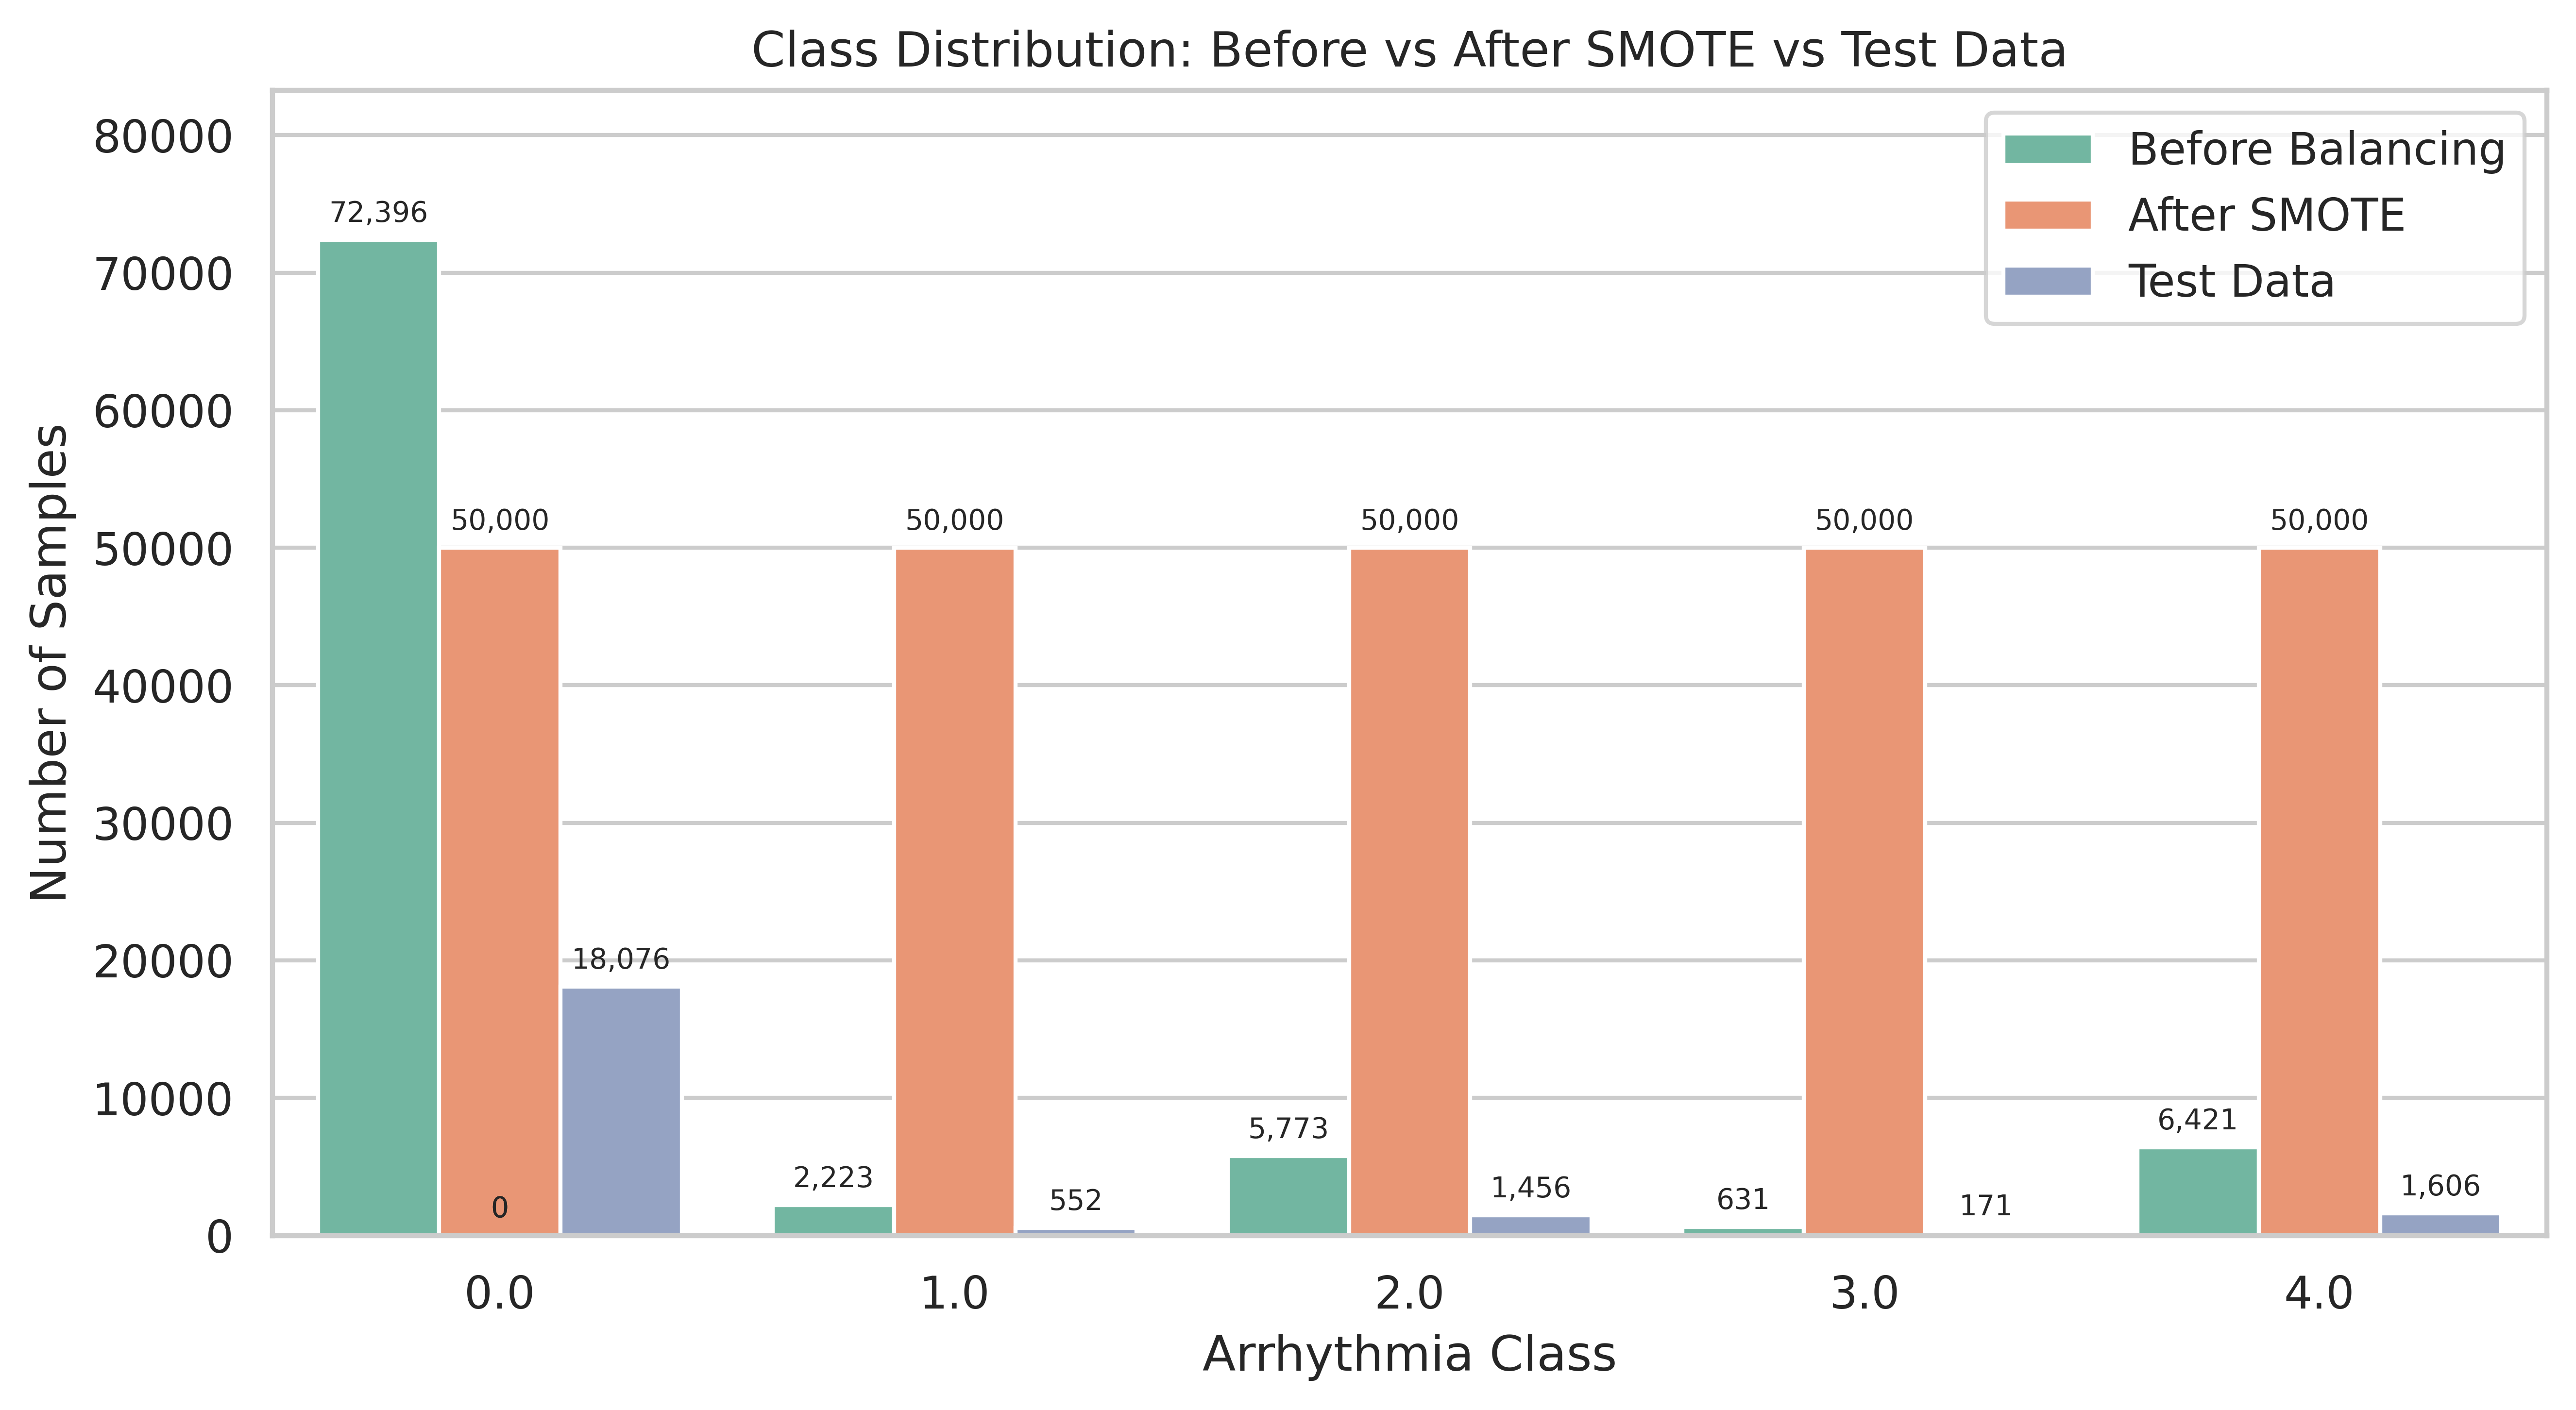

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# STEP 1: Prepare Data
# ----------------------------
# Convert to pandas Series (if arrays)
y_train_series = pd.Series(y_train.flatten(), name="Before Balancing")
y_test_series = pd.Series(y_test.flatten(), name="Test")

# Counts before balancing
counts_before = y_train_series.value_counts().sort_index()

# Counts after SMOTE (class_data is assumed to be a pandas Series of class counts)
counts_after = class_data.sort_index()

# Counts for test data
counts_test = y_test_series.value_counts().sort_index()

# Combine all class labels
classes = sorted(set(counts_before.index) | set(counts_after.index) | set(counts_test.index))

# Reindex to include all classes for each
counts_before = counts_before.reindex(classes, fill_value=0)
counts_after = counts_after.reindex(classes, fill_value=0)
counts_test = counts_test.reindex(classes, fill_value=0)

# ----------------------------
# STEP 2: Build DataFrame for plotting
# ----------------------------
df_plot = pd.DataFrame({
    "Class": classes * 3,
    "Samples": list(counts_before.values) + list(counts_after.values) + list(counts_test.values),
    "Dataset": (
        ["Before Balancing"] * len(classes)
        + ["After SMOTE"] * len(classes)
        + ["Test Data"] * len(classes)
    )
})

# ----------------------------
# STEP 3: Plot grouped bars
# ----------------------------
plt.figure(figsize=(9, 5), dpi=600)
sns.set(style="whitegrid")

ax = sns.barplot(data=df_plot, x="Class", y="Samples", hue="Dataset", palette="Set2")

plt.title("Class Distribution: Before vs After SMOTE vs Test Data")
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Samples")
plt.ylim(0, max(df_plot["Samples"]) * 1.15)

# ----------------------------
# STEP 4: Annotate counts on bars
# ----------------------------
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=7, xytext=(0,3),
                textcoords='offset points')

plt.legend(title="")
plt.tight_layout()
plt.show()

# **Part E: Model Building and Training**
A **CNN-LSTM and attention** based hybrid model is formulated.

## **E1: Attention Mechanism**
**Convolutional Block Attention Module** ([CBAM](https://arxiv.org/abs/1807.06521)) consists two parts (i) **channel attention**, (ii) spatial attention. ECG is an 1D signal and 1-lead ECG is used in the modle.Therefore, only channel attention is only used.

In [299]:
# udf for channel attention mechanism
class ChannelAttention(tf.keras.layers.Layer):
      def __init__(self, filters, ratio):
        super(ChannelAttention, self).__init__()
        self.filters = filters
        self.ratio = ratio

        def build(self, input_shape):
            self.shared_layer_one = tf.keras.layers.Dense(self.filters//self.ratio,
                             activation='relu', kernel_initializer='he_normal',
                              use_bias=True,
                              bias_initializer='zeros')
            self.shared_layer_two = tf.keras.layers.Dense(self.filters,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

        def call(self, inputs):
            # AvgPool
            avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)


            avg_pool = self.shared_layer_one(avg_pool)
            avg_pool = self.shared_layer_two(avg_pool)

            # MaxPool
            max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
            max_pool = tf.keras.layers.Reshape((1,1,filters))(max_pool)

            max_pool = shared_layer_one(max_pool)
            max_pool = shared_layer_two(max_pool)


            attention = tf.keras.layers.Add()([avg_pool,max_pool])
            attention = tf.keras.layers.Activation('sigmoid')(attention)

            return tf.keras.layers.Multiply()([inputs, attention])

In [300]:
# udf for spatial attention mechanism
class SpatialAttention(tf.keras.layers.Layer):
      def __init__(self, kernel_size):
        super(SpatialAttention, self).__init__()
        self.kernel_size = kernel_size

        def build(self, input_shape):
            self.conv2d = tf.keras.layers.Conv2D(filters = 1,
                    kernel_size=self.kernel_size,
                    strides=1,
                    padding='same',
                    activation='sigmoid',
                    kernel_initializer='he_normal',
                    use_bias=False)

        def call(self, inputs):

            # AvgPool
            avg_pool = tf.keras.layers.Lambda(lambda x: tf.keras.backend.mean(x, axis=3, keepdims=True))(inputs)

            # MaxPool
            max_pool = tf.keras.layers.Lambda(lambda x: tf.keras.backend.max(x, axis=3, keepdims=True))(inputs)

            attention = tf.keras.layers.Concatenate(axis=3)([avg_pool, max_pool])

            attention = self.conv2d(attention)


            return tf.keras.layers.multiply([inputs, attention])

## **E2: CNN-LSTM and attention model architecture**

### **a. Model building**

In [301]:
# Build a CNN model
def buildModel():
    newModel = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),
        # The first convolutional layer, sixteen 21x1 convolution kernels
        tf.keras.layers.Conv1D(filters=16, kernel_size=21, strides=1, padding='same', activation='relu'),
        ChannelAttention(16, 8),
        # SpatialAttention(7),
        # The first pooling layer, max pooling, 3x1 convolution kernels, stride 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The second convolution layer, 32 23x1 convolution kernels
        tf.keras.layers.Conv1D(filters=32, kernel_size=23, strides=1, padding='same', activation='relu'),
        ChannelAttention(32, 8),
        # SpatialAttention(7),
        # The second pooling layer, max pooling, 3x1 convolution kernels, with a stride of 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The third convolution layer, 64 25x1 convolution kernels
        tf.keras.layers.Conv1D(filters=64, kernel_size=25, strides=1, padding='same', activation='relu'),
        ChannelAttention(64, 8),
        # SpatialAttention(7),
        # The third pooling layer, average pooling, 3x1 convolution kernels, stride 2
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),
        # The fourth convolution layer, 128 27x1 convolution kernels
        tf.keras.layers.Conv1D(filters=128, kernel_size=27, strides=1, padding='same', activation='relu'),
        ChannelAttention(128, 8),
        SpatialAttention(7),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(64, return_sequences=True),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # LSTM layer, 32 nodes
        tf.keras.layers.LSTM(32, return_sequences=True),
        # Flatten the layer to facilitate the processing of the fully connected layer
        tf.keras.layers.Flatten(),
        # Fully connected layer, 128 nodes
        tf.keras.layers.Dense(128, activation='relu'),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # Fully connected layer, 5 nodes
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return newModel

### **b. Hyperparameter Tuning**
Many architectures of model is found by changing hyperparameters.
* Model: with or without channel or spatial attention.
* CNN Filters: Number of filters in each Conv layer is changing like 4, 16, 32, 64, 128 etc.
* LSTM Units: Number of units of two LSTM layer is varing like 32, 64, 128 etc.

In [302]:
# Build a CNN model
def buildModel():
    newModel = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(300, 1)),
        # The first convolutional layer, four 21x1 convolution kernels
        tf.keras.layers.Conv1D(filters=16, kernel_size=21, strides=1, padding='same', activation='relu'),
        # The first pooling layer, max pooling, four 3x1 convolution kernels, stride 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The second convolution layer, 16 23x1 convolution kernels
        tf.keras.layers.Conv1D(filters=32, kernel_size=23, strides=1, padding='same', activation='relu'),
        # The second pooling layer, max pooling, four 3x1 convolution kernels, with a stride of 2
        tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding='same'),
        # The third convolution layer, 32 25x1 convolution kernels
        tf.keras.layers.Conv1D(filters=64, kernel_size=25, strides=1, padding='same', activation='relu'),
        # The third pooling layer, average pooling, four 3x1 convolution kernels, stride 2
        tf.keras.layers.AvgPool1D(pool_size=3, strides=2, padding='same'),
        # The fourth convolution layer, 64 27x1 convolution kernels
        tf.keras.layers.Conv1D(filters=128, kernel_size=27, strides=1, padding='same', activation='relu'),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(128, return_sequences=True),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # LSTM layer, 64 nodes
        tf.keras.layers.LSTM(64, return_sequences=True),
        # Flatten the layer to facilitate the processing of the fully connected layer
        tf.keras.layers.Flatten(),
        # Fully connected layer, 128 nodes
        tf.keras.layers.Dense(128, activation='relu'),
        # Dropout layer,dropout = 0.2
        tf.keras.layers.Dropout(rate=0.2),
        # Fully connected layer, 5 nodes
        tf.keras.layers.Dense(5, activation='softmax')
    ])
    return newModel

### **c. Model Training**

**Build, save and then Fit the Model.**
If we have already the saved model, then no need to build, save and fit again.

In [303]:
#Define the log directory, which must be a subdirectory of the specified
#directory when starting the web application. It is recommended to use date and time as the subdirectory name
logdir = project_path + "logs\\" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_path = project_path + "ecg_model_code 17_t5.h5"

In [304]:
# percentage of training data used for model validation
ratio = 0.2

In [325]:
#checkpoint_filepath = project_path + "code_17_t5_weights.hdf5"

if os.path.exists(model_path):
    print('Model is already in the filepath')
    model = tf.keras.models.load_model(filepath=model_path)
else:
    print('Model not found, now building and then saving')
    model = buildModel()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
    callback_list = [tensorboard_callback, model_checkpoint_callback]

    history = model.fit(
        X_train, Y_train,
        epochs=30,
        batch_size=128,
        validation_split=ratio,
        callbacks=callback_list
    )

Model is already in the filepath


In [328]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2)


Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.9871 - loss: 0.0575 - val_accuracy: 0.9911 - val_loss: 0.0380
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.9873 - loss: 0.0459 - val_accuracy: 0.9891 - val_loss: 0.0402
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.9881 - loss: 0.0412 - val_accuracy: 0.9867 - val_loss: 0.0564
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.9885 - loss: 0.0373 - val_accuracy: 0.9921 - val_loss: 0.0340
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - accuracy: 0.9882 - loss: 0.0375 - val_accuracy: 0.9865 - val_loss: 0.0519
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.9884 - loss: 0.0363 - val_accuracy: 0.9903 - val_loss: 0.0412
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9893 - loss: 0.0335 - val_accuracy: 0.9898 - val_loss: 0.0415
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9890 - loss: 0.0364 - 

### **d. Plotting Accuracy and Loss**
Training and Validation accuray and loss curve plotting.

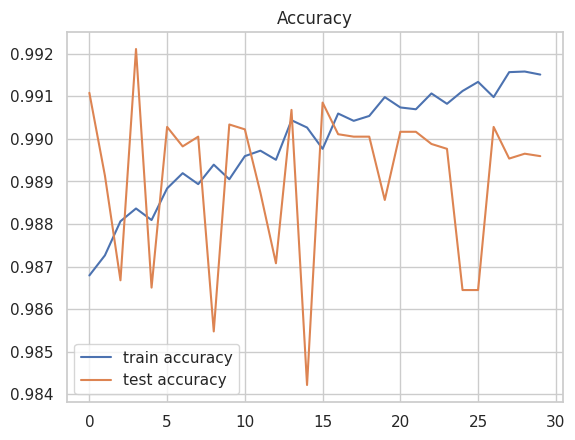

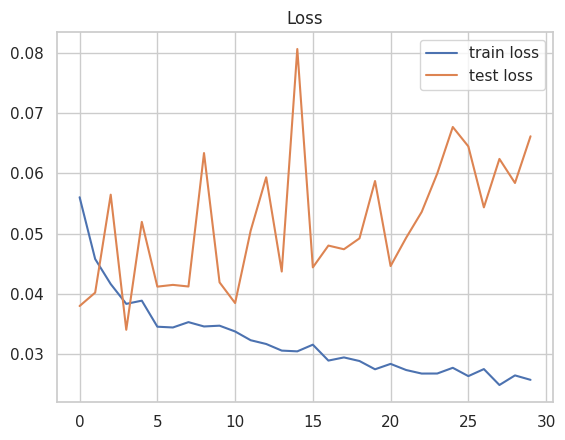

In [329]:
# plot accuracy during training
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy') # label is actually 'validation accuracy'
plt.legend()
plt.show()

# plot loss during training
plt.title('Loss')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss') # label is actually 'validation accuracy'
plt.legend()
plt.show()

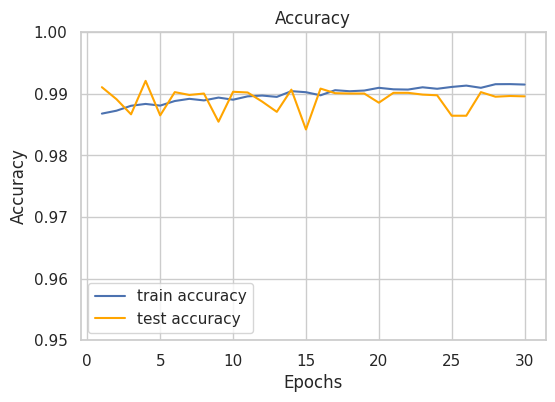

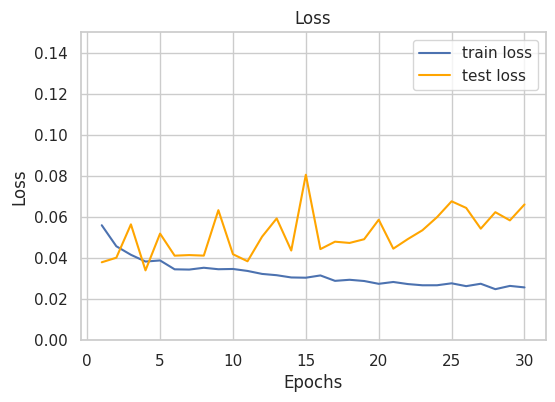

In [338]:
import matplotlib.pyplot as plt

# Assuming you have history from model.fit()
epochs = range(1, len(history.history['accuracy']) + 1)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, history.history['accuracy'], 'b-', label='train accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'orange', label='test accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1)  # y-axis from 0.95 to 1
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(epochs, history.history['loss'], 'b-', label='train loss')
plt.plot(epochs, history.history['val_loss'], 'orange', label='test loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0.00, 0.15)  # Optional: adjust based on your loss values
plt.legend()
plt.grid(True)
plt.show()

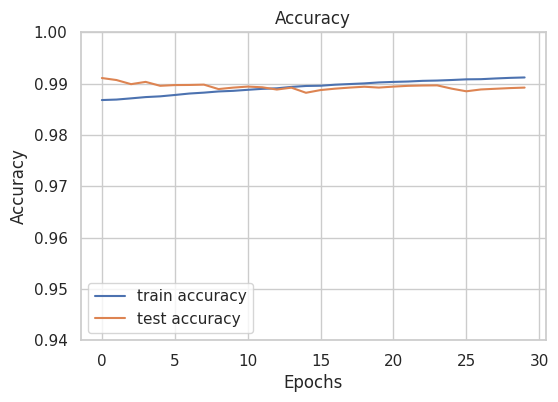

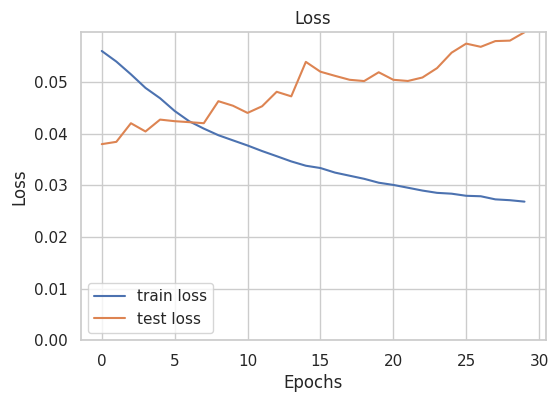

In [340]:
plt.figure(figsize=(6,4))
plt.plot(train_acc, label='train accuracy')
plt.plot(val_acc, label='test accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.94, 1.0)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='test loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, max(max(train_loss), max(val_loss)))  # Adjust based on your data
plt.legend()
plt.grid(True)
plt.show()

# **Part F: Results**


## **F1: Classification Accuracy and Confusion Matrix**
The overall classification accuracy and confusion matrix generated by the follwoing code.

**Model Testing**
* a. Using **recently trained** and Saved Model after 30 Epochs.
* b. Using the **best model** saved by *'model checkpoint'* callback.

**a. Using Recently Trained Model**

In [331]:
# Evaluate the model
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print('Training Accuracy: %.2f, Test Accuracy: %.2f' % (train_acc*100, test_acc*100))
print('Training Loss: %.2f, Test Loss: %.2f' % (train_loss*100, test_loss*100))

Training Accuracy: 99.51, Test Accuracy: 99.11
Training Loss: 2.18, Test Loss: 4.95


**b. Using the Best Model**
We saved many checkpoints of the model. Among these checkpoints we will consider the checkpoint which has the largest validation accuracy. Then copy its path and update the model weights.

**Confusion Matrix**

In [332]:
# confusion matrix
def plotHeatMap(Y_test, Y_pred):
    con_mat = confusion_matrix(Y_test, Y_pred)
    # Normalized
    # con_mat_norm = con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis]
    # con_mat_norm = np.around(con_mat_norm, decimals=2)

    # Plotting
    plt.figure(figsize=(8, 8))
    seaborn.heatmap(con_mat, annot=True, square=True, fmt='.20g', cmap='Greens')
    plt.ylim(0, 5)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

684/684 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


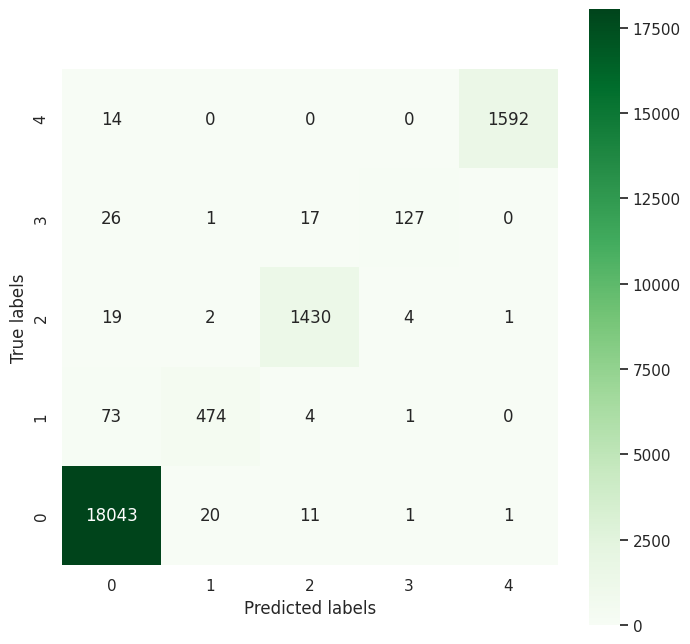

In [333]:
# predict
Y_pred = np.argmax(model.predict(x_test), axis=-1)
# Y_pred = model.predict_classes(X_test)
# plot confusion matrix
plotHeatMap(y_test, Y_pred)

## **F2: Per Class Performance**
Calculating per class Sensitivity, Specificity, Accuracy and F1 score.

In [334]:
# Per class accuracy printing function
def _report(TN, FP, FN, TP):
    TPR = TP/(TP+FN) if (TP+FN)!=0 else 0
    TNR = TN/(TN+FP) if (TN+FP)!=0 else 0
    PPV = TP/(TP+FP) if (TP+FP)!=0 else 0
    '''
    report = {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
              'TPR': TPR, 'Recall': TPR, 'Sensitivity': TPR,
              'TNR' : TNR, 'Specificity': TNR,
              'FPR': FP/(FP+TN) if (FP+TN)!=0 else 0,
              'FNR': FN/(FN+TP) if (FN+TP)!=0 else 0,
              'PPV': PPV, 'Precision': PPV,
              'F1 Score': 2*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy': (TP+TN)/(TP+FP+FN+TN)
             }'''

    report = {'Sensitivity (%)': TPR*100,
              'Specificity (%)': TNR*100,
              'F1 Score (%)': 2*100*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy (%)': (TP+TN)*100/(TP+FP+FN+TN)
             }
    return report

def multi_classification_report(y_test, y_pred, labels=None, encoded_labels=True, as_frame=False):
    """
    Args:
        y_test (ndarray)
        y_pred (ndarray)
        labels (list)
        encoded_labels (bool): Need to be False if labels are not one hot encoded
        as_fram (bool): If True, return type will be DataFrame

    Return:
        report (dict)
    """

    import numpy as np
    import pandas as pd
    from sklearn.metrics import multilabel_confusion_matrix

    conf_labels = None if encoded_labels else labels

    conf_mat = multilabel_confusion_matrix(y_test, y_pred, labels=conf_labels)
    report = dict()
    if labels == None:
        counter = np.arange(len(conf_mat))
    else:
        counter = labels

    for i, name in enumerate(counter):
        TN, FP, FN, TP = conf_mat[i].ravel()
        report[name] = _report(TN, FP, FN, TP)

    if as_frame:
        return pd.DataFrame(report)
    return report

**a. Recently Trained Model**

In [335]:
# Per class performance
labels = ['N', 'S', 'V', 'F', 'Q']
Y_pred = np.argmax(model.predict(x_test), axis=-1)
multi_classification_report(y_test, Y_pred, labels=labels, encoded_labels=True, as_frame=True)

684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


,N,S,V,F,Q
Sensitivity (%),99.817437,85.869565,98.214286,74.269006,99.128269
Specificity (%),96.512550,99.892064,99.843176,99.972337,99.990126
F1 Score (%),99.544840,90.371783,98.012337,83.552632,99.500000
Per Class Accuracy (%),99.245231,99.537990,99.734687,99.771282,99.926810
